# Cross-layer probe transfer: complete research workflow, version 3
**Revised 27 September 2026 · AISTATS-oriented experiments and figure exports**

This notebook replaces the preceding pilot workflow. It tests whether failures of unaligned probe reuse
survive mean, scale, normalization, clipping, rank, regularization, and alignment controls. It compares
geometry with direct loss computation and reports when those quantities are algebraically identical.
Established inference methods are baselines, not claimed new theorems. A successful run does not by itself
establish publication novelty or strong acceptance.

**Run all cells in Colab/Kaggle/Jupyter.** The default is the **paper** profile. The delivered local
validation uses an environment override `AISTATS_RUN_MODE=smoke`; its synthetic outputs are not real-model
results. The current profile and actual completion status appear in the first and last cells.
The ordinary paper run requires NumPy, SciPy, pandas, scikit-learn, matplotlib, threadpoolctl, PyTorch,
Transformers, datasets, and huggingface-hub. Install missing packages in your environment, for example
`pip install torch transformers datasets huggingface-hub scipy pandas scikit-learn matplotlib threadpoolctl`.
No automatic package installation or remote Python code is executed by this notebook.

For staged GPU sessions set `JOB_FILTER={"gpt2_sst2"}` or another listed job. Deterministic feature caches
and per-experiment checkpoints let the workflow resume. Use a persistent `OUTPUT_ROOT` and copy the entire
directory between sessions. Enable Internet for model/data acquisition, or supply native-feature `.npz`
bundles with the documented metadata. The full grid is substantial; no single-session runtime is promised.

**What changed:** raw features are the primary input (no default norm clipping); consistent block outputs
are extracted before a model's final normalization; layer centering/RMS/unit normalization and clipping
are explicit interventions; GCV selects ridge strength using training data only; oracle inference and
bounded fitted-reference inference are separated; simultaneous betting and empirical Bernstein intervals
are compared; all pair-level summary tables are embedded in a recoverable compressed output; figures are
exported as vector PDF/SVG and 600-dpi PNG with readable two-column-paper typography.

The visible real-result tables from the reuploaded notebook are preserved as an explicitly labeled
**v2 pilot appendix**. They never fill a missing v3 experiment.


In [1]:
from pathlib import Path
from dataclasses import dataclass,asdict
import os,sys,json,time,hashlib,platform,importlib.util,importlib.metadata,itertools,zlib,base64,io,zipfile
from datetime import datetime,timezone
import numpy as np
import pandas as pd
from scipy import linalg,stats
from scipy.optimize import brentq
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MaxNLocator,LogLocator
from threadpoolctl import threadpool_limits

RUN_MODE=os.environ.get("AISTATS_RUN_MODE","paper") # "smoke", "pilot", "paper"
RUN_REAL=os.environ.get("AISTATS_RUN_REAL","auto") # "auto", "yes", "no"
JOB_FILTER=None                                    # e.g. {"gpt2_sst2"}; includes domains by their own names
FEATURE_BUNDLES={}                                  # e.g. {"gpt2_sst2":"/path/features.npz"}
OUTPUT_ROOT=Path("aistats2027_v3_outputs")
ENABLE_EXTENSIONS=True
SAVE_PER_EXAMPLE=True
MASTER_SEED=20260927
ALPHA=.05
assert RUN_MODE in {"smoke","pilot","paper"}
assert RUN_REAL in {"auto","yes","no"}

@dataclass(frozen=True)
class Settings:
    repeats:int=3 if RUN_MODE=="paper" else 1
    pca_k:int=128 if RUN_MODE=="paper" else 32
    metric_rank:int=64 if RUN_MODE=="paper" else 16
    metric_max_examples:int=1024 if RUN_MODE=="paper" else 512
    mc_reps:int=1000 if RUN_MODE=="paper" else (300 if RUN_MODE=="pilot" else 100)
    gaussian_reps:int=3000 if RUN_MODE=="paper" else 300
    bootstrap_reps:int=1000 if RUN_MODE=="paper" else 100
    ridge_scale:float=1e-3
    ridge_grid:tuple=(1e-4,1e-3,1e-2,.1,1.)
    label_cap:float=.5
    nll_cap:float=10.
    max_length:int=64
    batch_size:int=16
    extraction_kind:str="block_output" # pre-final-normalization block hooks; v2 used API hidden_states
    decision_threshold:float=.02
CFG=Settings()
RUN_ID=datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
RUN_DIR=OUTPUT_ROOT/(RUN_MODE+"_"+RUN_ID)
CACHE_DIR=OUTPUT_ROOT/"native_feature_cache_v3"
CHECKPOINT_DIR=OUTPUT_ROOT/"experiment_checkpoints_v3"
for path in [RUN_DIR,CACHE_DIR,CHECKPOINT_DIR]: path.mkdir(parents=True,exist_ok=True)
_threads=threadpool_limits(limits=min(4,os.cpu_count() or 1))
STATUS=[]; TABLES={}; FIGURE_LOG=[]; CHECKS=[]; USED_CHECKPOINTS=set()
CODE_VERSION="v3-20260927-betting-blockoutputs-controls-1"

def rng_for(*keys):
    raw=json.dumps([MASTER_SEED,*keys],sort_keys=True,default=str).encode()
    return np.random.default_rng(int.from_bytes(hashlib.sha256(raw).digest()[:8],"little"))
def jsonable(o):
    if isinstance(o,np.ndarray):return o.tolist()
    if isinstance(o,np.generic):return o.item()
    if isinstance(o,Path):return str(o)
    raise TypeError(type(o).__name__)
def write_json(path,obj):Path(path).write_text(json.dumps(obj,indent=2,default=jsonable))
def status(task,state,detail):
    STATUS.append(dict(task=task,state=state,detail=str(detail)))
    print(f"[{state}] {task}: {detail}")
def checked(name,condition):
    if not bool(condition):raise AssertionError(name)
    CHECKS.append(dict(check=name,passed=True))
def emit(data):
    if "_emit_notebook_output" in globals():
        _emit_notebook_output(dict(output_type="display_data",metadata={},data=data))
    else:
        from IPython.display import display
        display(data,raw=True)
def show_table(name,frame,display_all=True):
    frame=pd.DataFrame(frame);TABLES[name]=frame
    frame.to_csv(RUN_DIR/(name+".csv"),index=False)
    # Complete HTML is saved. Large tables are collapsible, not silently truncated to head(24).
    table=frame.to_html(index=False,float_format=lambda v:f"{v:.6g}")
    if len(frame)>30:table=f'<details><summary>{name}: all {len(frame)} rows</summary>'+table+'</details>'
    if display_all:emit({"text/html":table,"text/plain":f"{name}: {len(frame)} complete rows; see HTML/CSV and embedded result bundle."})
    return frame
versions={}
for p in ["numpy","scipy","pandas","scikit-learn","matplotlib","torch","transformers","datasets","huggingface-hub"]:
    try:versions[p]=importlib.metadata.version(p)
    except importlib.metadata.PackageNotFoundError:versions[p]=None
MANIFEST={"run_id":RUN_ID,"code_version":CODE_VERSION,"run_mode":RUN_MODE,"config":asdict(CFG),
          "python":sys.version,"versions":versions,"seed":MASTER_SEED,"resolved_revisions":{},
          "hardware":platform.platform(),"new_results_use_playback":False}
print(json.dumps({"mode":RUN_MODE,"config":asdict(CFG),"versions":versions,"run_directory":str(RUN_DIR)},indent=2))


{
  "mode": "paper",
  "config": {
    "repeats": 3,
    "pca_k": 128,
    "metric_rank": 64,
    "metric_max_examples": 1024,
    "mc_reps": 1000,
    "gaussian_reps": 3000,
    "bootstrap_reps": 1000,
    "ridge_scale": 0.001,
    "ridge_grid": [
      0.0001,
      0.001,
      0.01,
      0.1,
      1.0
    ],
    "label_cap": 0.5,
    "nll_cap": 10.0,
    "max_length": 64,
    "batch_size": 16,
    "extraction_kind": "block_output",
    "decision_threshold": 0.02
  },
  "versions": {
    "numpy": "2.0.2",
    "scipy": "1.16.3",
    "pandas": "2.3.3",
    "scikit-learn": "1.6.1",
    "matplotlib": "3.10.0",
    "torch": "2.10.0+cu128",
    "transformers": "5.0.0",
    "datasets": "5.0.0",
    "huggingface-hub": "1.11.0"
  },
  "run_directory": "aistats2027_v3_outputs/paper_20260927T094309405733Z"
}


## 1. Figure system and output conventions
Figures use 3.25-inch single-column or 6.75-inch double-column canvases, 8–9 pt labels, colorblind-friendly
colors, panel labels, restrained grids, and vector fonts. These dimensions are configurable: verify final
placement against the official AISTATS 2027 template. Simulation error bars are Monte Carlo intervals;
repeat ranges on real benchmarks are descriptive. They are never mislabeled as population confidence intervals.
Every figure has a matching data table and a caption file specifying estimand, sample unit, and limitations.


In [2]:
COLORS={"geometry":"#0072B2","direct_train":"#009E73","direct_cal":"#D55E00",
        "cka":"#CC79A7","betting":"#0072B2","bernstein":"#E69F00","aligned":"#009E73","other":"#777777"}
mpl.rcParams.update({"font.family":"DejaVu Sans","font.size":8,"axes.labelsize":8,"axes.titlesize":9,
    "xtick.labelsize":7,"ytick.labelsize":7,"legend.fontsize":7,"axes.linewidth":.65,
    "lines.linewidth":1.25,"lines.markersize":3.5,"axes.spines.top":False,"axes.spines.right":False,
    "pdf.fonttype":42,"ps.fonttype":42,"svg.fonttype":"none","figure.dpi":140,"savefig.dpi":600,
    "axes.grid":False,"legend.frameon":False,"mathtext.fontset":"dejavusans"})
def paper_figure(nrows=1,ncols=1,height=2.35,double=False):
    fig,axs=plt.subplots(nrows,ncols,figsize=(6.75 if double else 3.25,height),squeeze=False,layout="constrained")
    for ax in axs.flat:
        ax.tick_params(direction="out",width=.6,length=3)
        ax.yaxis.set_major_locator(MaxNLocator(5))
    return fig,axs
def panel(ax,label,title):
    ax.set_title(f"({label}) {title}",loc="left",pad=6)
def export_figure(fig,name,caption,data=None):
    folder=RUN_DIR/"figures";folder.mkdir(exist_ok=True)
    # Save a fixed physical canvas. Constrained layout resolves decorations before export.
    fig.canvas.draw()
    for ext in ["pdf","svg","png"]:fig.savefig(folder/(name+"."+ext),dpi=600,facecolor="white")
    (folder/(name+"_caption.txt")).write_text(caption)
    if data is not None:pd.DataFrame(data).to_csv(folder/(name+"_data.csv"),index=False)
    FIGURE_LOG.append(dict(figure=name,width_inches=fig.get_figwidth(),height_inches=fig.get_figheight(),caption=caption))
    plt.show();plt.close(fig)


## 2. Estimands and claims that the experiment is allowed to make
For fitted affine predictors $a,b$, write $D=p_a(X)-p_b(X)$ and $r_b=Y-p_b(X)$.
$$L(a)-L(b)=E[D^2]-2E[Dr_b],\qquad E[D^2]=\operatorname{Var}(D)+(E D)^2.$$
All three terms are measured. The residual-corrected geometric estimate is **exactly the direct empirical
loss difference**; it is not a competing improved estimator. With a fitted ridge reference, omitting the
residual term generally changes the answer. Transporting affine coefficients retains source intercepts
unless the protocol explicitly performs target centering or alignment.

The primary finite-sample estimand is the **clipped fitted-reference loss difference**. Labels and
predictions are clipped to $[-M,M]$, giving $g\in[-4M^2,4M^2]$. Raw linear loss is reported separately.
Neither a bounded clipped interval nor a fitted-reference comparison is called a population-oracle certificate.
The v2 componentwise covariance oracle bound is retired from real-data inference because its constants
make it structurally vacuous here. A Gaussian design-metric oracle interval appears only in its own
correctly specified simulation; it is not applied to binary benchmark labels.

The population quadratic identity and invariance counterexamples remain background mathematics. CKA
preserves positive isotropic scaling, so a full CKA-preserving orbit need not have bounded unaligned risk.
Ideal full-rank CCA differs from numerically truncated CCA. Learned alignment changes the transfer action.


In [3]:
def sym(A): return (A + A.T) / 2

def clip_rows(X, radius):
    X = np.asarray(X, dtype=np.float64)
    return X * np.minimum(1.0, radius / np.maximum(np.linalg.norm(X, axis=1), 1e-15))[:,None]

def augment(X): return np.column_stack([X, np.ones(len(X))])

@dataclass
class Probe:
    w: np.ndarray
    b: float
    lam: float
    def predict(self, X): return X @ self.w + self.b
    def augmented(self): return np.r_[self.w, self.b]

def fit_probe(X, y, ridge_scale=CFG.ridge_scale):
    X, y = np.asarray(X,dtype=float), np.asarray(y,dtype=float)
    mx, my = X.mean(0), float(y.mean())
    Z, v = X-mx, y-my
    S = Z.T @ Z / len(X)
    c = Z.T @ v / len(X)
    lam = float(ridge_scale * np.trace(S) / max(1,len(c)))
    if ridge_scale == 0:
        w = np.linalg.lstsq(Z,v,rcond=None)[0]
    else:
        lam=max(lam,1e-14)
        w = linalg.solve(sym(S)+lam*np.eye(len(c)), c, assume_a="pos")
    return Probe(w, my-float(mx@w), lam)

@dataclass
class AffineMap:
    mean: np.ndarray
    basis: np.ndarray                    # raw-width x output-width
    def transform(self, X): return (X-self.mean) @ self.basis
    def lift(self, probe):
        w = self.basis @ probe.w
        return Probe(w, probe.b-float(self.mean@w), probe.lam)

def fit_maps(X, mode, k, seed):
    # X has shape (examples, layers, native width); fit exclusively on training examples.
    n,L,d = X.shape
    if mode == "native":
        return [AffineMap(np.zeros(d),np.eye(d)) for _ in range(L)]
    k = min(k,d,n-1)
    if mode == "shared_pca":
        # A single common affine map preserves coordinate comparability across layers.
        p = PCA(k,svd_solver="full").fit(X.reshape(n*L,d))
        m = AffineMap(p.mean_,p.components_.T)
        return [m for _ in range(L)]
    if mode in {"separate_pca_naive","separate_pca_lift"}:
        maps=[]
        for j in range(L):
            p=PCA(k,svd_solver="full").fit(X[:,j,:])
            maps.append(AffineMap(p.mean_,p.components_.T))
        return maps
    raise ValueError(mode)

def prepare_fit(X, y, mode="shared_pca", k=32, ridge_scale=CFG.ridge_scale, seed=0):
    maps=fit_maps(X,mode,k,seed)
    F=[m.transform(X[:,j,:]) for j,m in enumerate(maps)]
    probes=[fit_probe(f,y,ridge_scale) for f in F]
    return {"maps":maps,"probes":probes,"mode":mode,"layers":X.shape[1]}

def predict_pairs(fit, X, y, label_cap):
    L=fit["layers"]; pairs=[(s,t) for s in range(L) for t in range(L) if s!=t or fit.get("include_diagonal",False)]
    maps,probes=fit["maps"],fit["probes"]
    F=[maps[j].transform(X[:,j,:]) for j in range(L)]
    refs=fit.get("reference_probes",probes)
    reference=[refs[j].predict(F[j]) for j in range(L)]
    pa,pb=[],[]
    for s,t in pairs:
        if fit["mode"] == "separate_pca_lift":
            # Exact source lift to native coordinates. Does not project into the target PCA span.
            a=maps[s].lift(probes[s]).predict(X[:,t,:])
        else:
            a=probes[s].predict(F[t])
        pa.append(a); pb.append(reference[t])
    pa,pb=np.column_stack(pa),np.column_stack(pb)
    y=np.asarray(y)[:,None]
    q=(pa-pb)**2
    cross=-2*(pa-pb)*(y-pb)
    raw=(y-pa)**2-(y-pb)**2
    ac,bc=np.clip(pa,-label_cap,label_cap),np.clip(pb,-label_cap,label_cap)
    yc=np.clip(y,-label_cap,label_cap)
    clipped=(yc-ac)**2-(yc-bc)**2
    assert np.allclose(raw,q+cross,rtol=1e-9,atol=1e-9)
    return {"pairs":pairs,"a":pa,"b":pb,"raw":raw,"q":q,"cross":cross,"clipped":clipped}

def linear_cka(X,Y):
    X,Y=X-X.mean(0),Y-Y.mean(0)
    den=np.linalg.norm(X.T@X,"fro")*np.linalg.norm(Y.T@Y,"fro")
    return float(np.linalg.norm(X.T@Y,"fro")**2/den) if den>0 else np.nan

def cca_singular_values(X,Y, rtol=1e-10):
    # No ridge whitening. Report numerical ranks; exact GL claim requires retained full rank.
    X,Y=X-X.mean(0),Y-Y.mean(0)
    U,s,_=linalg.svd(X,full_matrices=False)
    V,t,_=linalg.svd(Y,full_matrices=False)
    rx=int(np.sum(s>rtol*s[0])) if len(s) and s[0]>0 else 0
    ry=int(np.sum(t>rtol*t[0])) if len(t) and t[0]>0 else 0
    if min(rx,ry)==0: return np.array([]),rx,ry
    cc=linalg.svdvals(U[:,:rx].T@V[:,:ry])
    return np.clip(cc,0,1),rx,ry


In [4]:
@dataclass
class Policy:
    name:str
    mean:np.ndarray
    scale:float
    cap:object=None
    def transform(self,X):
        X=np.asarray(X,float)
        if self.cap is not None:X=clip_rows(X,float(self.cap))
        if self.name=="unit":X=X/np.maximum(np.linalg.norm(X,axis=1,keepdims=True),1e-12)*np.sqrt(X.shape[1])
        return (X-self.mean)/self.scale

def fit_policies(X,normalization="raw",cap=None):
    policies=[];diagnostics=[]
    for j in range(X.shape[1]):
        A=np.asarray(X[:,j,:],float);norm=np.linalg.norm(A,axis=1)
        C=clip_rows(A,cap) if cap is not None else A
        mean=C.mean(0) if normalization in {"center","rms"} else np.zeros(A.shape[1])
        scale=float(np.sqrt(np.mean((C-mean)**2))) if normalization=="rms" else 1.
        scale=max(scale,1e-12)
        policies.append(Policy(normalization,mean,scale,cap))
        diagnostics.append(dict(layer=j,mean_norm=float(np.linalg.norm(A.mean(0))),rms_norm=float(np.sqrt(np.mean(norm**2))),
            clip_fraction=float(np.mean(norm>cap)) if cap is not None else 0.,training_scale=scale))
    return policies,pd.DataFrame(diagnostics)
def transform_policy(policies,X):return np.stack([p.transform(X[:,j,:]) for j,p in enumerate(policies)],axis=1)

def fit_probe_gcv(X,y,grid=CFG.ridge_grid):
    X=np.asarray(X,float);y=np.asarray(y,float);mu=X.mean(0);my=y.mean();Z=X-mu;v=y-my;n,d=Z.shape
    S=sym(Z.T@Z/n);ev,V=np.linalg.eigh(S);ev=np.maximum(ev,0);c=V.T@(Z.T@v/n)
    scale=max(float(ev.mean()),1e-14);choices=[]
    for alpha in grid:
        lam=max(alpha*scale,1e-14);w=V@(c/(ev+lam));res=v-Z@w
        df=1+np.sum(ev/(ev+lam));gcv=float(np.mean(res**2)/max(1-df/n,1e-8)**2)
        choices.append((gcv,alpha,lam,w,df))
    best=min(choices,key=lambda z:z[0]);_,alpha,lam,w,df=best
    p=Probe(w,float(my-mu@w),lam);p.selected_scale=float(alpha);p.effective_df=float(df)
    return p

def pooled_map(features,k):
    d=features[0].shape[1];total=sum(len(x) for x in features)
    mean=sum(x.sum(0) for x in features)/total
    S=sum(x.T@x for x in features)/total-np.outer(mean,mean)
    ev,V=np.linalg.eigh(sym(S));k=min(k,d,total-1)
    return AffineMap(mean,V[:,np.argsort(ev)[-k:][::-1]])

def fit_maps(X,mode,k,seed):
    n,L,d=X.shape;k=min(k,d,n-1)
    if mode=="native":return [AffineMap(np.zeros(d),np.eye(d)) for _ in range(L)]
    if mode=="shared_pca":
        m=pooled_map([X[:,j,:] for j in range(L)],k);return [m for _ in range(L)]
    if mode in {"separate_pca_naive","separate_pca_lift"}:
        return [pooled_map([X[:,j,:]],k) for j in range(L)]
    raise ValueError(mode)

def fit_pipeline(X,y,spec,seed):
    policies,diagnostics=fit_policies(X,spec.get("normalization","raw"),spec.get("cap"))
    P=transform_policy(policies,X)
    maps=fit_maps(P,spec.get("mode","shared_pca"),spec.get("k",CFG.pca_k),seed)
    F=[m.transform(P[:,j,:]) for j,m in enumerate(maps)]
    probes=[fit_probe_gcv(f,y) if spec.get("ridge","gcv")=="gcv" else fit_probe(f,y,float(spec["ridge"])) for f in F]
    return {"maps":maps,"probes":probes,"mode":spec.get("mode","shared_pca"),"layers":X.shape[1],
            "policies":policies,"policy_diagnostics":diagnostics,"spec":spec}
def pipeline_pairs(fit,X,y,M):return predict_pairs(fit,transform_policy(fit["policies"],X),y,M)
def pipeline_features(fit,X):
    P=transform_policy(fit["policies"],X)
    return [m.transform(P[:,j,:]) for j,m in enumerate(fit["maps"])]

def representation_metrics(fit,X):
    X=X[:CFG.metric_max_examples] # predetermined training-prefix sample; no label-dependent subsampling
    F=pipeline_features(fit,X);n=len(X);L=len(F);d=F[0].shape[1]
    # A shared low-dimensional metric projection avoids inevitable sample-rank CCA saturation.
    k=min(CFG.metric_rank,d,max(2,(n-1)//4))
    p=pooled_map(F,k)
    G=[p.transform(f) for f in F];rows=[];cache={};Qs=[];ranks=[]
    centered=[f-f.mean(0) for f in F]
    grams=[f@f.T for f in centered]
    gram_norms=[np.linalg.norm(g,"fro") for g in grams]
    if min(gram_norms)<=1e-14:raise ValueError("Degenerate features: CKA is undefined")
    for g in G:
        U,s,_=linalg.svd(g-g.mean(0),full_matrices=False);rank=int(np.sum(s>1e-10*s[0]))
        if rank==0:raise ValueError("Zero-rank features: CCA is undefined")
        Qs.append(U[:,:rank]);ranks.append(rank)
    for s in range(L):
        for t in range(L):
            if s==t and not fit.get("include_diagonal",False):continue
            key=tuple(sorted((s,t)))
            if key not in cache:
                rs,rt=ranks[key[0]],ranks[key[1]]
                cc=np.clip(linalg.svdvals(Qs[key[0]].T@Qs[key[1]]),0,1)
                ka,kb=key;cka=float(np.sum(grams[ka]*grams[kb])/(gram_norms[ka]*gram_norms[kb]))
                cache[key]=(cka,float(np.mean(cc**2)),float(np.mean(cc)),rs,rt)
            cka,cca,proc,rs,rt=cache[key]
            ws=fit["probes"][s].w;wt=fit.get("reference_probes",fit["probes"])[t].w
            rows.append(dict(source=s,target=t,cka=cka,cca_shared=cca,procrustes_shared=proc,
                probe_cosine=float(ws@wt/max(np.linalg.norm(ws)*np.linalg.norm(wt),1e-15)),metric_rank=k,metric_examples=n,
                full_dim_cca_saturation_possible=(2*min(d,n-1)>n-1)))
    return pd.DataFrame(rows)


## 3. Simultaneous bounded-risk inference: empirical Bernstein and predictable betting
For $P$ prespecified candidates, empirical Bernstein uses the known range $R=8M^2$ and
$\log(4P/\alpha)$. For betting, rescale each paired loss to $X_i=(g_i+4M^2)/(8M^2)\in[0,1]$.
For any candidate mean $u$, define
$$K_n^+(u)=\prod_i[1+\lambda_i^+(u)(X_i-u)],\quad
K_n^-(u)=\prod_i[1-\lambda_i^-(u)(X_i-u)].$$
The nonnegative bets depend only on previous observations and satisfy
$\lambda_i^+(u)\le0.9/u$, $\lambda_i^-(u)\le0.9/(1-u)$.
At the true mean each factor has conditional expectation one. Markov's inequality and a union bound
over the two tails and $P$ candidates give simultaneous fixed-time coverage when rejecting at wealth
$2P/\alpha$. Each factor is monotone in $u$ for our capped predictable bets, so bisection gives interval endpoints.

The notebook uses a variance-adaptive predictable stake, with fixed sample horizon, and attributes the
betting framework to Waudby-Smith & Ramdas. It is not an assertion that this implementation exactly matches
every tuning choice in their paper. Intervals are reported separately. Both receive $\alpha/2$ when they
are used together, so choosing between these two methods does not escape the error allocation.
The primary family covers all protocols and both unaligned/aligned actions for one job/repeat at a fixed
calibration budget. Across budget curves an additional allocation covers all displayed budgets.
Real-data repeats are descriptive; no sign-flip tests over layer pairs are used.


In [5]:
def eb_bounds(G,M,alpha=ALPHA,family_size=None):
    G=np.asarray(G,float);G=G[:,None] if G.ndim==1 else G
    n,p=G.shape;P=p if family_size is None else int(family_size);C=4*M*M;R=2*C
    if n<2 or P<p or np.max(abs(G))>C+1e-8:raise ValueError("Invalid bounded-loss family")
    log=np.log(4*P/alpha)
    radius=np.sqrt(2*G.var(0,ddof=1)*log/n)+7*R*log/(3*(n-1))
    return np.maximum(-C,G.mean(0)-radius),np.minimum(C,G.mean(0)+radius)

def predictable_stakes(X,alpha,P):
    n,p=X.shape
    count=np.arange(n)[:,None]
    prior_sum=np.vstack([np.zeros((1,p)),np.cumsum(X,axis=0)[:-1]])
    prior_squares=np.vstack([np.zeros((1,p)),np.cumsum(X*X,axis=0)[:-1]])
    mean=(.5+prior_sum)/(count+1)
    var=np.maximum((.5+prior_squares)/(count+1)-mean**2,1e-4)
    return np.sqrt(2*np.log(2*P/alpha)/(n*var))

def betting_bounds(G,M,alpha=ALPHA,family_size=None,iterations=38):
    G=np.asarray(G,float);G=G[:,None] if G.ndim==1 else G
    n,p=G.shape;P=p if family_size is None else int(family_size);C=4*M*M
    if n<2 or P<p or np.max(abs(G))>C+1e-8:raise ValueError("Invalid bounded-loss family")
    X=np.clip((G+C)/(2*C),0,1);base=predictable_stakes(X,alpha,P);threshold=np.log(2*P/alpha)
    def wealth(mu,positive):
        denom=mu if positive else 1-mu
        cap=np.divide(.9,denom,out=np.full_like(denom,np.inf),where=denom>0)
        lam=np.minimum(base,cap[None,:])
        return np.log1p((1 if positive else -1)*lam*(X-mu[None,:])).sum(0)
    left=np.zeros(p);right=np.ones(p)
    reject0=wealth(left,True)>=threshold
    for _ in range(iterations):
        mid=(left+right)/2;reject=wealth(mid,True)>=threshold
        left=np.where(reject,mid,left);right=np.where(reject,right,mid)
    lower=np.where(reject0,left,0.)  # outward rounding preserves coverage at numerical tolerance
    left=np.zeros(p);right=np.ones(p);reject1=wealth(right,False)>=threshold
    for _ in range(iterations):
        mid=(left+right)/2;reject=wealth(mid,False)>=threshold
        left=np.where(reject,left,mid);right=np.where(reject,mid,right)
    upper=np.where(reject1,right,1.)
    return 2*C*lower-C,2*C*upper-C

def confidence_methods(G,M,alpha=ALPHA,family_size=None):
    return {"bernstein":eb_bounds(G,M,alpha/2,family_size),
            "betting":betting_bounds(G,M,alpha/2,family_size)}
def binomial_ci(k,n,alpha=.05):
    return (0. if k==0 else float(stats.beta.ppf(alpha/2,k,n-k+1)),
            1. if k==n else float(stats.beta.ppf(1-alpha/2,k+1,n-k)))


## 4. Algebra, transport, and inference checks
Assertions test exact identities and data-handling invariants, not statistical success on one seed.
Monte Carlo coverage is evaluated separately and reported even when a nominal method misses its target.


In [6]:
rng=rng_for("checks");X=rng.normal(size=(500,6));y=X@rng.normal(size=6)+rng.normal(size=500)*.1
b=fit_probe(X,y,.1);a=rng.normal(size=6);pa=X@a+.2;pb=b.predict(X)
q=np.mean((pa-pb)**2);cross=-2*np.mean((pa-pb)*(y-pb));direct=np.mean((y-pa)**2-(y-pb)**2)
checked("ridge-corrected identity",np.allclose(q+cross,direct))
checked("mean plus covariance disagreement decomposition",np.allclose(q,np.var(pa-pb)+np.mean(pa-pb)**2))
o=fit_probe(X,y,0);checked("OLS empirical identity",np.allclose(np.mean((pa-o.predict(X))**2),np.mean((y-pa)**2-(y-o.predict(X))**2)))
p=PCA(6).fit(X);U=p.components_.T;A=AffineMap(p.mean_,U);B=AffineMap(p.mean_,U@np.diag([-1,1,1,1,1,1]))
target=A.transform(X)[:,0];pr=fit_probe(A.transform(X),target,0)
naive=pr.predict(B.transform(X));lift=A.lift(pr).predict(X)
checked("PCA sign flip preserves CKA",np.allclose(linear_cka(A.transform(X),B.transform(X)),1))
checked("native lift removes sign artifact",np.mean((naive-target)**2)>1 and np.mean((lift-target)**2)<1e-20)
checked("CKA scale invariance",np.allclose(linear_cka(X,y[:,None]),linear_cka(.01*X,y[:,None])))
for endpoint in [-1.,1.]:
    G=np.full((80,3),endpoint)
    for name,(lo,hi) in confidence_methods(G,.5).items():
        checked(f"{name} contains deterministic endpoint {endpoint}",np.all(lo<=endpoint+1e-12)&np.all(hi>=endpoint-1e-12))
Xb=rng.uniform(size=(50,2));s1=predictable_stakes(Xb,.05,2);Xb[30:]=1-Xb[30:]
checked("betting stake uses past only",np.array_equal(s1[:31],predictable_stakes(Xb,.05,2)[:31]))
lo,hi=betting_bounds(np.zeros((100,2)),.5)
checked("zero observed range does not imply zero uncertainty",np.all(hi-lo>0))
checked("zero failures have nonzero binomial uncertainty",binomial_ci(0,100)[1]>0)
show_table("algebra_and_inference_checks",CHECKS)
status("core_checks","COMPLETED",f"{len(CHECKS)} assertions")


check,passed
ridge-corrected identity,True
mean plus covariance disagreement decomposition,True
OLS empirical identity,True
PCA sign flip preserves CKA,True
native lift removes sign artifact,True
CKA scale invariance,True
bernstein contains deterministic endpoint -1.0,True
betting contains deterministic endpoint -1.0,True
bernstein contains deterministic endpoint 1.0,True
betting contains deterministic endpoint 1.0,True


[COMPLETED] core_checks: 13 assertions


## 5. Exact bounded-distribution coverage and decision utility
The eight-point distribution uses independent signs $u,v,e$, features $(u,v)$ and $(u,uv)$, and
$Y=0.4u+0.1v+0.05e$. Every population loss is an exact support average. Training and calibration are
redrawn independently for every repetition. Coverage is simultaneous over both directions and both
reported interval methods. False certification means accepting any pair whose true difference exceeds
the fixed tolerance. It is not estimated by testing whether a noisy held-out mean crosses a bound.


n_cal,method,coverage,coverage_lo,coverage_hi,mean_width,acceptance,false_certification,false_cert_lo,false_cert_hi,repetitions
128,bernstein,1,0.996318,1,0.52283,0,0,0,0.00368208,1000
128,betting,1,0.996318,1,0.106946,0,0,0,0.00368208,1000
512,bernstein,1,0.996318,1,0.132412,0,0,0,0.00368208,1000
512,betting,1,0.996318,1,0.0274303,0.013,0,0,0.00368208,1000
2048,bernstein,1,0.996318,1,0.0342968,0,0,0,0.00368208,1000
2048,betting,1,0.996318,1,0.00706646,0.997,0,0,0.00368208,1000


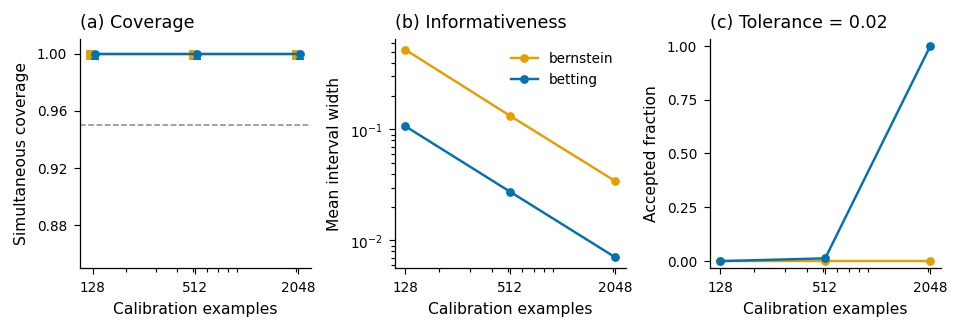

[COMPLETED] bounded_inference_simulation: 1000 independent repetitions at each of three sample sizes


In [7]:
bits=np.array(list(itertools.product([-1.,1.],repeat=3)));u,v,e=bits.T
FINITE_X=np.stack([np.column_stack([u,v]),np.column_stack([u,u*v])],axis=1)
FINITE_Y=.4*u+.1*v+.05*e
coverage_rows=[]
for ncal in [128,512,2048]:
    for rep in range(CFG.mc_reps):
        rng=rng_for("coverage",ncal,rep);tr=rng.integers(0,8,128);ca=rng.integers(0,8,ncal)
        fit=prepare_fit(FINITE_X[tr],FINITE_Y[tr],"native",2)
        cal=predict_pairs(fit,FINITE_X[ca],FINITE_Y[ca],.55)
        truth=predict_pairs(fit,FINITE_X,FINITE_Y,.55)["clipped"].mean(0)
        intervals=confidence_methods(cal["clipped"],.55)
        jointly_covered=all(np.all((lo<=truth+1e-12)&(truth<=hi+1e-12)) for lo,hi in intervals.values())
        for method,(lo,hi) in intervals.items():
            accepted=hi<=.02
            coverage_rows.append(dict(n_cal=ncal,rep=rep,method=method,coverage=bool(np.all((lo<=truth)&(truth<=hi))),
                both_methods_coverage=jointly_covered,mean_width=float(np.mean(hi-lo)),
                accepted_fraction=float(accepted.mean()),false_certification=bool(np.any(accepted&(truth>.02))),
                exact_mean_difference=float(truth.mean())))
coverage_raw=pd.DataFrame(coverage_rows);TABLES["coverage_repetitions"]=coverage_raw
summary=[]
for (n,method),g in coverage_raw.groupby(["n_cal","method"]):
    count=int(g.coverage.sum());lo,hi=binomial_ci(count,len(g));f=int(g.false_certification.sum());flo,fhi=binomial_ci(f,len(g))
    summary.append(dict(n_cal=n,method=method,coverage=count/len(g),coverage_lo=lo,coverage_hi=hi,
        mean_width=g.mean_width.mean(),acceptance=g.accepted_fraction.mean(),false_certification=f/len(g),
        false_cert_lo=flo,false_cert_hi=fhi,repetitions=len(g)))
coverage_summary=show_table("bounded_coverage_summary",summary)
fig,axs=paper_figure(ncols=3,height=2.25,double=True)
for j,(method,g) in enumerate(coverage_summary.groupby("method")):
    c=COLORS[method]
    axs[0,0].errorbar(g.n_cal*(.97 if j==0 else 1.03),g.coverage,yerr=[g.coverage-g.coverage_lo,g.coverage_hi-g.coverage],color=c,marker=["s","o"][j],capsize=2,label=method)
    axs[0,1].loglog(g.n_cal,g.mean_width,"o-",color=c,label=method)
    axs[0,2].semilogx(g.n_cal,g.acceptance,"o-",color=c,label=method)
for ax in axs.flat:ax.set_xlabel("Calibration examples")
axs[0,0].set_xscale("log");axs[0,0].set_ylim(.85,1.01);axs[0,0].axhline(.95,ls="--",color=".55",lw=.8)
axs[0,0].set_ylabel("Simultaneous coverage");axs[0,1].set_ylabel("Mean interval width");axs[0,2].set_ylabel("Accepted fraction");axs[0,2].set_ylim(-.03,1.03)
for ax in axs.flat:ax.set_xticks([128,512,2048],labels=["128","512","2048"]);ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
panel(axs[0,0],"a","Coverage");panel(axs[0,1],"b","Informativeness");panel(axs[0,2],"c","Tolerance = 0.02")
axs[0,1].legend()
export_figure(fig,"fig01_bounded_inference","Exactly enumerable bounded DGP. Both methods receive half of the 5% family budget; intervals cover two directions. Error bars are exact binomial Monte Carlo intervals, with slight horizontal offsets for visibility. Acceptance is based only on calibration data.",coverage_summary)
status("bounded_inference_simulation","COMPLETED",f"{CFG.mc_reps} independent repetitions at each of three sample sizes")


## 6. Oracle inference under an explicit Gaussian linear model
For independent calibration data satisfying $y=Z\beta+\epsilon$, with Gaussian homoscedastic errors,
$p<n$, and full-column-rank $Z$, the usual exact regression ellipsoid gives
$$\|\hat\beta-\beta\|_{Z^\top Z/n}^2\le
\frac{p\hat\sigma^2}{n}F_{p,n-p}(1-\alpha).$$
The triangle inequality yields an interval for
$\|a-\beta\|_{Z^\top Z/n}^2$ for a source predictor $a$ fixed before calibration. This is a
**design-metric** oracle regret, not regret under an unknown population covariance. The same event covers
any fixed candidate source vector. The construction is classical, useful under its assumptions, and not
used as a certified method on classification benchmarks. Misspecified/non-Gaussian variants remain diagnostics.


In [8]:
def latent_parameters(d,condition,rotation=0.4):
    rng=rng_for("latent_parameters",d,condition,rotation)
    Q,_=np.linalg.qr(rng.normal(size=(d,d)))
    scales=np.geomspace(1,1/np.sqrt(condition),d)
    Bs=np.diag(scales)
    angle=rotation
    O=np.eye(d); O[:2,:2]=[[np.cos(angle),-np.sin(angle)],[np.sin(angle),np.cos(angle)]]
    Bt=O@Bs
    noise=.01/condition
    theta=Q[:,0]
    S=Bs@Bs.T+noise*np.eye(d); T=Bt@Bt.T+noise*np.eye(d)
    ws=linalg.solve(S,Bs@theta,assume_a="pos"); wt=linalg.solve(T,Bt@theta,assume_a="pos")
    return dict(d=d,Bs=Bs,Bt=Bt,theta=theta,noise=noise,S=S,T=T,ws=ws,wt=wt)

def latent_sample(par,n,rng):
    z=rng.normal(size=(n,par["d"]))
    xs=z@par["Bs"].T+np.sqrt(par["noise"])*rng.normal(size=z.shape)
    xt=z@par["Bt"].T+np.sqrt(par["noise"])*rng.normal(size=z.shape)
    y=z@par["theta"]+.2*rng.normal(size=n)
    return xs,xt,y


d,n,coverage,lo,hi,mean_width,mean_truth,reps
4,64,0.999,0.99708,0.999794,0.109332,0.0880775,3000
4,256,0.999667,0.998144,0.999992,0.0530167,0.0880107,3000
4,1024,0.999,0.99708,0.999794,0.0262936,0.0880131,3000
12,64,1,0.998771,1,0.107497,0.0346009,3000
12,256,1,0.998771,1,0.0478445,0.0345095,3000
12,1024,1,0.998771,1,0.0232151,0.0345824,3000


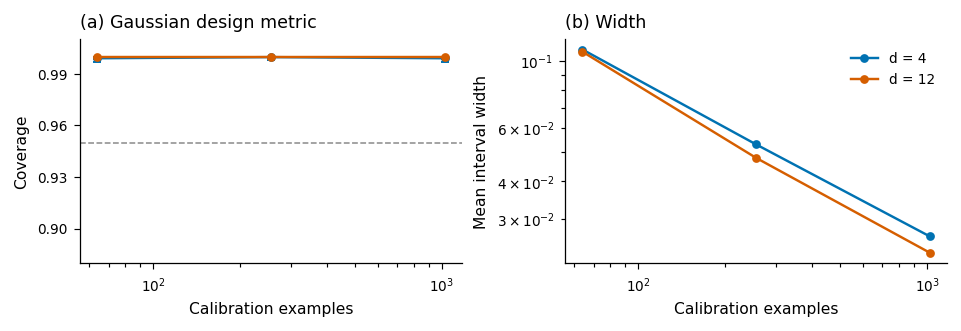

[COMPLETED] gaussian_oracle_simulation: Correctly specified model only; separate estimand


In [9]:
def gaussian_design_interval(Z,y,a,alpha=ALPHA):
    n,p=Z.shape
    if n<=p or np.linalg.matrix_rank(Z)<p:return 0.,np.inf
    bh=linalg.lstsq(Z,y)[0];res=y-Z@bh;s2=float(res@res/(n-p))
    H=Z.T@Z/n;q=float((a-bh)@H@(a-bh))
    radius=np.sqrt(p*s2*stats.f.ppf(1-alpha,p,n-p)/n)
    return max(np.sqrt(max(q,0))-radius,0)**2,(np.sqrt(max(q,0))+radius)**2

oracle_rows=[]
for d,n in itertools.product([4,12],[64,256,1024]):
    par=latent_parameters(d,20.)
    for rep in range(CFG.gaussian_reps):
        rng=rng_for("oracle_gaussian",d,n,rep)
        xs,xt,y=latent_sample(par,256,rng);source_probe=fit_probe(xs,y)
        _,xc,yc=latent_sample(par,n,rng);Z=augment(xc);a=source_probe.augmented();beta=np.r_[par["wt"],0.]
        lo,hi=gaussian_design_interval(Z,yc,a);truth=float(np.mean((Z@(a-beta))**2))
        oracle_rows.append(dict(d=d,n=n,rep=rep,covered=lo<=truth<=hi,width=hi-lo,truth=truth))
oracle_raw=pd.DataFrame(oracle_rows);TABLES["gaussian_oracle_repetitions"]=oracle_raw
oracle_summary=[]
for (d,n),g in oracle_raw.groupby(["d","n"]):
    lo,hi=binomial_ci(int(g.covered.sum()),len(g))
    oracle_summary.append(dict(d=d,n=n,coverage=g.covered.mean(),lo=lo,hi=hi,mean_width=g.width.mean(),mean_truth=g.truth.mean(),reps=len(g)))
oracle_summary=show_table("gaussian_design_oracle_summary",oracle_summary)
fig,axs=paper_figure(ncols=2,height=2.25,double=True)
for j,(d,g) in enumerate(oracle_summary.groupby("d")):
    c=[COLORS["geometry"],COLORS["direct_cal"]][j]
    axs[0,0].errorbar(g.n,g.coverage,yerr=[g.coverage-g.lo,g.hi-g.coverage],color=c,marker="o",capsize=2,label=f"d = {d}")
    axs[0,1].loglog(g.n,g.mean_width,"o-",color=c,label=f"d = {d}")
axs[0,0].set(xscale="log",ylim=(.88,1.01),xlabel="Calibration examples",ylabel="Coverage")
axs[0,1].set(xlabel="Calibration examples",ylabel="Mean interval width")
axs[0,0].axhline(.95,color=".55",ls="--",lw=.8);axs[0,1].legend()
panel(axs[0,0],"a","Gaussian design metric");panel(axs[0,1],"b","Width")
export_figure(fig,"fig02_gaussian_oracle","Paired latent Gaussian DGP with source fitting independent of calibration. The F ellipsoid covers a conditional design-metric regret under correctly specified Gaussian linear regression; no population-covariance guarantee is claimed.",oracle_summary)
status("gaussian_oracle_simulation","COMPLETED","Correctly specified model only; separate estimand")


## 7. Near-zero rates and invariance scope
The standard quadratic-noise calculation predicts $n^{-1}$ standard deviation at zero signal and
$n^{-1/2}$ away from zero. These experiments validate the implementation and delimit what is already
known. The scaling counterexample uses two independent Gaussian representations with a common label,
so both population regression coefficients are jointly attainable.


signal,n,empirical_sd,theoretical_sd,empirical_bias,theoretical_bias
0,128,0.0316071,0.03125,0.0633926,0.0625
0,512,0.00789408,0.0078125,0.0157119,0.015625
0,2048,0.00199788,0.00195312,0.00395301,0.00390625
0,8192,0.000483763,0.000488281,0.000981578,0.000976562
0.05,128,0.0322466,0.032476,0.0623175,0.0625
0.05,512,0.00923114,0.00897588,0.0157957,0.015625
0.05,2048,0.00297629,0.00294915,0.00390022,0.00390625
0.05,8192,0.00121271,0.00120794,0.00100947,0.000976562
0.5,128,0.0937454,0.09375,0.0614076,0.0625
0.5,512,0.0452664,0.0448794,0.0149217,0.015625


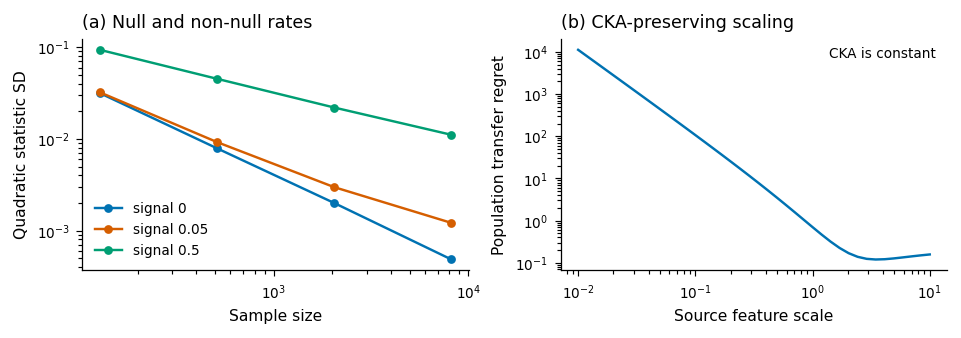

[COMPLETED] rates_and_invariance: Fresh simulations; no rate-anomaly claim


In [10]:
rate_rows=[]
for signal,n in itertools.product([0.,.05,.5],[128,512,2048,8192]):
    d=8;rng=rng_for("rates",signal,n);mu=np.r_[signal,np.zeros(d-1)]
    D=mu+rng.normal(size=(4000,d))/np.sqrt(n);q=np.sum(D*D,1)
    rate_rows.append(dict(signal=signal,n=n,empirical_sd=q.std(ddof=1),theoretical_sd=np.sqrt(4*signal**2/n+2*d/n**2),
        empirical_bias=q.mean()-signal**2,theoretical_bias=d/n))
rates=show_table("near_zero_rates",rate_rows)
rng=rng_for("invariance");Xs=rng.normal(size=(1500,3));Xt=rng.normal(size=(1500,3));a=np.array([1.,.3,-.2]);b=np.array([.4,-.2,.1])
y=Xs@a+Xt@b+.1*rng.normal(size=1500)
scales=np.logspace(-2,1,40)
orbit=pd.DataFrame([dict(scale=c,cka=linear_cka(c*Xs,Xt),risk=np.sum((a/c-b)**2)) for c in scales])
TABLES["scaling_orbit"]=orbit
fig,axs=paper_figure(ncols=2,height=2.3,double=True)
for j,(sig,g) in enumerate(rates.groupby("signal")):
    c=[COLORS["geometry"],COLORS["direct_cal"],COLORS["direct_train"]][j]
    axs[0,0].loglog(g.n,g.empirical_sd,"o-",color=c,label=f"signal {sig:g}")
axs[0,0].set(xlabel="Sample size",ylabel="Quadratic statistic SD");axs[0,0].legend()
axs[0,1].loglog(orbit.scale,orbit.risk,color=COLORS["geometry"])
axs[0,1].set(xlabel="Source feature scale",ylabel="Population transfer regret")
axs[0,1].text(.97,.97,"CKA is constant",ha="right",va="top",transform=axs[0,1].transAxes,fontsize=7)
panel(axs[0,0],"a","Null and non-null rates");panel(axs[0,1],"b","CKA-preserving scaling")
export_figure(fig,"fig03_rates_and_scope","Known quadratic-Gaussian rates and a positive-scaling orbit. These are background checks, not new theorems. The right panel evaluates the population target metric with identity covariance.",pd.concat([rates.assign(study="rates"),orbit.assign(study="orbit")],ignore_index=True))
status("rates_and_invariance","COMPLETED","Fresh simulations; no rate-anomaly claim")


## 8. Shared-split evaluation and fair baselines
Training, calibration, and final-test IDs are disjoint. All preprocessing, ridge selection, and stitching
are fitted before calibration. Geometry and direct training risk share the same labels. Direct calibration
risk uses a stated additional target-label budget. Similarity predictors are calibrated leaving each target
layer out; a single common score mapping and the directional held-target mapping are reported separately.
The symmetric-score MAE lower bound applies only to one common symmetric prediction rule, not to separately
fitted target-specific calibrators. Raw correlations use raw scores, not their calibrated predictions.


In [11]:
def split_indices(ids,n_train,n_cal,n_test,seed):
    ids=np.asarray(ids).astype(str)
    if len(np.unique(ids))!=len(ids): raise ValueError("Duplicate IDs: deduplicate before splitting")
    if min(n_train,n_cal,n_test)<2 or n_train+n_cal+n_test>len(ids): raise ValueError("Invalid split sizes")
    order=rng_for("split",seed).permutation(len(ids))[:n_train+n_cal+n_test]
    parts=np.split(order,[n_train,n_train+n_cal])
    for a,b in itertools.combinations(parts,2): assert len(np.intersect1d(ids[a],ids[b]))==0
    return {"train":parts[0],"cal":parts[1],"test":parts[2]}


In [12]:
def fit_stitches(fit,Xtrain):
    F=pipeline_features(fit,Xtrain);P=np.column_stack([p.predict(f) for p,f in zip(fit["probes"],F)])
    mean=P.mean(0);targets=P-mean;out={}
    for t,Ft in enumerate(F):
        mx=Ft.mean(0);Z=Ft-mx;S=sym(Z.T@Z/len(Z));lam=max(CFG.ridge_scale*np.trace(S)/len(S),1e-14)
        W=linalg.solve(S+lam*np.eye(len(S)),Z.T@targets/len(Z),assume_a="pos")
        biases=mean-mx@W
        for s in range(len(F)):out[(s,t)]=Probe(W[:,s],float(biases[s]),lam)
    return out
def aligned_predictions(fit,stitches,X,pairs):
    F=pipeline_features(fit,X)
    return np.column_stack([stitches[(s,t)].predict(F[t]) for s,t in pairs])
def paired_losses(pa,pb,y,M):
    y=np.asarray(y)[:,None];raw=(y-pa)**2-(y-pb)**2
    yc=np.clip(y,-M,M);ac=np.clip(pa,-M,M);bc=np.clip(pb,-M,M)
    return raw,(yc-ac)**2-(yc-bc)**2

def calibrate_scores(frame):
    predictions={}
    for metric in ["cka","cca_shared","procrustes_shared","probe_cosine"]:
        x=1-frame[metric].to_numpy();y=frame.cal_raw.to_numpy()
        common=IsotonicRegression(out_of_bounds="clip").fit(x,y)
        predictions[metric+"_common"]=common.predict(x)
        held=np.full(len(x),np.nan)
        for t in sorted(frame.target.unique()):
            tr=frame.target.to_numpy()!=t;te=~tr
            if tr.sum()<2:continue
            held[te]=IsotonicRegression(out_of_bounds="clip").fit(x[tr],y[tr]).predict(x[te])
        predictions[metric+"_held_target"]=held
    return predictions

def analyze_fixed_fit(fit,Xtr,ytr,Xca,yca,Xte,yte,M,family_multiplier=1,compute_metrics=True):
    tr=pipeline_pairs(fit,Xtr,ytr,M);ca=pipeline_pairs(fit,Xca,yca,M);te=pipeline_pairs(fit,Xte,yte,M)
    pairs=tr["pairs"];K=len(pairs)
    frame=representation_metrics(fit,Xtr) if compute_metrics else pd.DataFrame(pairs,columns=["source","target"])
    for name,G in [("train_raw",tr["raw"]),("train_geometry",tr["q"]),("residual_correction",tr["cross"]),
                   ("cal_raw",ca["raw"]),("test_raw",te["raw"]),("cal_clipped",ca["clipped"]),("test_clipped",te["clipped"])]:frame[name]=G.mean(0)
    dtr=tr["a"]-tr["b"];dte=te["a"]-te["b"]
    frame["train_mean_term"]=dtr.mean(0)**2;frame["train_variance_term"]=dtr.var(0)
    frame["test_mean_term"]=dte.mean(0)**2;frame["test_variance_term"]=dte.var(0)
    frame["test_geometry"]=np.mean(dte*dte,0)
    frame["mean_fraction"]=np.divide(frame.test_mean_term,frame.test_geometry,out=np.zeros(K),where=frame.test_geometry.to_numpy()>1e-14)
    # New intervention: alignment is evaluated as another action, not as an estimator of unaligned risk.
    stitches=fit_stitches(fit,Xtr)
    ac=aligned_predictions(fit,stitches,Xca,pairs);at=aligned_predictions(fit,stitches,Xte,pairs)
    acr,acc=paired_losses(ac,ca["b"],yca,M);atr,atc=paired_losses(at,te["b"],yte,M)
    frame["aligned_cal_raw"]=acr.mean(0);frame["aligned_test_raw"]=atr.mean(0)
    frame["aligned_test_clipped"]=atc.mean(0);frame["alignment_raw_reduction"]=frame.test_raw-frame.aligned_test_raw
    diagnostic=fit["policy_diagnostics"].copy();Ftr=pipeline_features(fit,Xtr);Fte=pipeline_features(fit,Xte)
    for j in range(fit["layers"]):
        p=fit.get("reference_probes",fit["probes"])[j];train_pred=p.predict(Ftr[j]);test_pred=p.predict(Fte[j])
        diagnostic.loc[j,"reference_probe_norm"]=np.linalg.norm(p.w)
        diagnostic.loc[j,"source_probe_norm"]=np.linalg.norm(fit["probes"][j].w)
        diagnostic.loc[j,"reference_intercept"]=p.b;diagnostic.loc[j,"ridge_lambda"]=p.lam
        diagnostic.loc[j,"ridge_selected_scale"]=getattr(p,"selected_scale",fit["spec"].get("ridge",np.nan)) if fit["spec"].get("ridge")!="gcv" else getattr(p,"selected_scale",np.nan)
        diagnostic.loc[j,"effective_df"]=getattr(p,"effective_df",np.nan)
        diagnostic.loc[j,"reference_train_mse"]=np.mean((train_pred-ytr)**2)
        diagnostic.loc[j,"reference_test_mse"]=np.mean((test_pred-yte)**2)
        diagnostic.loc[j,"reference_test_accuracy"]=np.mean((test_pred>=0)==(yte>=0)) if np.all(np.isin(yte,[-.5,.5])) else np.nan
    allG=np.column_stack([ca["clipped"],acc])
    bounds=confidence_methods(allG,M,family_size=2*K*family_multiplier)
    for method,(lo,hi) in bounds.items():
        frame[method+"_lo"]=lo[:K];frame[method+"_hi"]=hi[:K]
        frame[method+"_aligned_lo"]=lo[K:];frame[method+"_aligned_hi"]=hi[K:]
    predictions={"training_geometry":frame.train_geometry.to_numpy(),"direct_training":frame.train_raw.to_numpy(),
        "mean_only":frame.train_mean_term.to_numpy(),"variance_only":frame.train_variance_term.to_numpy(),
        "direct_calibration":frame.cal_raw.to_numpy()}
    if compute_metrics:predictions.update(calibrate_scores(frame))
    perf=[]
    for method,pred in predictions.items():
        frame["prediction__"+method]=pred;err=abs(pred-frame.test_raw.to_numpy());valid=np.isfinite(err)
        perf.append(dict(method=method,mae=err[valid].mean(),median_absolute_error=np.median(err[valid]),
            p90_absolute_error=np.quantile(err[valid],.9),spearman=stats.spearmanr(pred[valid],frame.test_raw[valid]).statistic if np.std(pred[valid])>1e-15 else np.nan,
            assessment_labels=0 if method in {"training_geometry","direct_training","mean_only","variance_only"} else len(yca),
            probe_training_labels=len(ytr),n_pairs=int(valid.sum())))
    decisions=[]
    for method in bounds:
        for action,col in [("unaligned","test_clipped"),("aligned","aligned_test_clipped")]:
            upper=frame[method+("_hi" if action=="unaligned" else "_aligned_hi")].to_numpy()
            for tau in [0.,.01,.02,.05,.1]:
                accept=upper<=tau
                decisions.append(dict(method=method,action=action,tolerance=tau,n_accepted=int(accept.sum()),accepted_fraction=accept.mean(),
                    accepted_test_mean=frame.loc[accept,col].mean() if accept.any() else np.nan,
                    test_fraction_above_tolerance=np.mean(frame.loc[accept,col]>tau) if accept.any() else np.nan,
                    interpretation="Noisy final-test audit, not population false-certification rate"))
    return dict(frame=frame,performance=pd.DataFrame(perf),decisions=pd.DataFrame(decisions),diagnostics=diagnostic,fit=fit,stitches=stitches,
        arrays={"cal_raw":ca["raw"],"cal_clipped":ca["clipped"],"test_raw":te["raw"],"test_clipped":te["clipped"],
                "cal_aligned_clipped":acc,"test_aligned_clipped":atc},bounds=bounds)

def run_experiment(X,y,ids,sizes,seed,spec,M,family_multiplier=1,compute_metrics=True):
    split=split_indices(ids,*sizes,seed);tr,ca,te=[split[k] for k in ["train","cal","test"]]
    fit=fit_pipeline(X[tr],y[tr],spec,seed)
    result=analyze_fixed_fit(fit,X[tr],y[tr],X[ca],y[ca],X[te],y[te],M,family_multiplier,compute_metrics)
    result["split"]=split;return result


## 9. Protocol registry, diagnosis plots, and label-budget curves
Raw native coordinates and shared PCA are primary reference settings. Centering and scaling are explicitly
different transfer protocols. Separate-PCA coefficient reuse is a negative control; lifting returns the
source head to the common preprocessed coordinate system. Clipping caps are never estimated from the test set.
The centered prediction disagreement is distinguished from its mean component, avoiding a geometric
interpretation of what may principally be a transferred-intercept error.


In [13]:
def protocol_registry(k):
    return [dict(name="native_raw",mode="native",normalization="raw",cap=None,k=k,ridge="gcv"),
        dict(name="shared_raw",mode="shared_pca",normalization="raw",cap=None,k=k,ridge="gcv"),
        dict(name="shared_center",mode="shared_pca",normalization="center",cap=None,k=k,ridge="gcv"),
        dict(name="shared_rms",mode="shared_pca",normalization="rms",cap=None,k=k,ridge="gcv"),
        dict(name="shared_unit",mode="shared_pca",normalization="unit",cap=None,k=k,ridge="gcv"),
        dict(name="shared_clip100",mode="shared_pca",normalization="raw",cap=100.,k=k,ridge="gcv"),
        dict(name="shared_clip300",mode="shared_pca",normalization="raw",cap=300.,k=k,ridge="gcv"),
        dict(name="separate_naive",mode="separate_pca_naive",normalization="raw",cap=None,k=k,ridge="gcv"),
        dict(name="separate_lift",mode="separate_pca_lift",normalization="raw",cap=None,k=k,ridge="gcv")]

def summarize_result(result,job,protocol,repeat):
    f=result["frame"];p=result["performance"].set_index("method")
    return dict(job=job,protocol=protocol,repeat=repeat,n_pairs=len(f),mean_raw_difference=f.test_raw.mean(),
        median_raw_difference=f.test_raw.median(),p90_raw_difference=f.test_raw.quantile(.9),
        mean_clipped_difference=f.test_clipped.mean(),mean_component_fraction=f.mean_fraction.median(),
        aligned_raw_mean=f.aligned_test_raw.mean(),geometry_mae=p.loc["training_geometry","mae"],
        training_direct_mae=p.loc["direct_training","mae"],calibration_direct_mae=p.loc["direct_calibration","mae"],
        bernstein_width=(f.bernstein_hi-f.bernstein_lo).mean(),betting_width=(f.betting_hi-f.betting_lo).mean(),
        betting_acceptance=float(np.mean(f.betting_hi<=CFG.decision_threshold)),
        mean_training_clip_fraction=float(result["diagnostics"].clip_fraction.mean()),
        mean_reference_test_mse=float(result["diagnostics"].reference_test_mse.mean()))

def plot_pair_diagnostics(result,name,label):
    f=result["frame"];L=int(max(f.source.max(),f.target.max()))+1
    fig,axs=paper_figure(nrows=2,ncols=2,height=4.7,double=True)
    A=np.full((L,L),np.nan);B=np.full((L,L),np.nan)
    for r in f.itertuples():A[int(r.source),int(r.target)]=r.test_raw;B[int(r.source),int(r.target)]=r.mean_fraction
    lim=max(float(np.nanmax(abs(A))),1e-8);threshold=max(lim*.001,1e-5)
    norm=mpl.colors.SymLogNorm(threshold,vmin=-lim,vmax=lim,base=10)
    im=axs[0,0].imshow(A,cmap="RdBu_r",norm=norm,aspect="equal")
    top=10.**np.floor(np.log10(lim));ticks=[-top,-top/10,0,top/10,top]
    fig.colorbar(im,ax=axs[0,0],fraction=.05,pad=.03,ticks=ticks).set_label("Loss difference (symlog)",fontsize=7)
    im=axs[0,1].imshow(B,cmap="cividis",vmin=0,vmax=1,aspect="equal")
    fig.colorbar(im,ax=axs[0,1],fraction=.05,pad=.03).set_label("Mean-term fraction",fontsize=7)
    ticks=np.unique(np.linspace(0,L-1,min(L,6)).astype(int))
    for ax in axs[0]:ax.set(xticks=ticks,yticks=ticks,xlabel="Target layer index",ylabel="Source layer index")
    for method,col,color in [("Geometry","train_geometry",COLORS["geometry"]),("Direct train","train_raw",COLORS["direct_train"])]:
        axs[1,0].scatter(f.test_raw,f[col],s=9,alpha=.6,c=color,label=method,rasterized=True)
    values=np.r_[f.test_raw,f.train_geometry,f.train_raw];lo,hi=float(values.min()),float(values.max())
    axs[1,0].plot([lo,hi],[lo,hi],color=".45",ls="--",lw=.8)
    axs[1,0].set(xscale="symlog",yscale="symlog",xlabel="Final-test raw difference",ylabel="Training estimate")
    axs[1,0].legend(loc="best")
    chosen=["training_geometry","direct_training","direct_calibration","mean_only","cka_held_target"]
    p=result["performance"].set_index("method");chosen=[c for c in chosen if c in p.index]
    labels={"training_geometry":"Geometry","direct_training":"Direct train","direct_calibration":"Direct calibration","mean_only":"Mean term","cka_held_target":"CKA, held target"}
    vals=np.array([p.loc[c,"mae"] for c in chosen]);axs[1,1].barh(np.arange(len(vals)),np.maximum(vals,1e-12),color=[COLORS["geometry"],COLORS["direct_train"],COLORS["direct_cal"],COLORS["other"],COLORS["cka"]][:len(vals)],height=.6)
    axs[1,1].set(yticks=np.arange(len(vals)),yticklabels=[labels[c] for c in chosen],xscale="log",xlabel="MAE to final-test mean")
    axs[1,1].invert_yaxis()
    for ax,l,t in zip(axs.flat,"abcd",["Transfer loss","Mean contribution","Prediction agreement","Direct-risk baselines"]):panel(ax,l,t)
    export_figure(fig,name,f"{label}. Ordered layer pairs share examples and are not independent replicates. Raw loss heatmap uses a symmetric-log color scale. MAE targets noisy final-test mean loss differences. Geometry and direct training use identical label budgets.",f)

def plot_control_summary(summary,name,label):
    g=pd.DataFrame(summary);order=list(dict.fromkeys(g.protocol))
    labels={"native_raw":"Native","shared_raw":"Shared PCA","shared_center":"Centered","shared_rms":"Centered + RMS", "shared_unit":"Unit norm","shared_clip100":"Clip 100","shared_clip300":"Clip 300","separate_naive":"Separate: naive","separate_lift":"Separate: lifted"}
    fig,axs=paper_figure(ncols=2,height=max(2.5,.24*len(order)+.6),double=True)
    for ax,col in zip(axs.flat,["mean_raw_difference","mean_component_fraction"]):
        for i,p in enumerate(order):
            v=g.loc[g.protocol==p,col].dropna().to_numpy()
            ax.errorbar(np.median(v),i,xerr=[[np.median(v)-v.min()],[v.max()-np.median(v)]],fmt="o",color=COLORS["geometry"],capsize=2)
        ax.set(yticks=np.arange(len(order)),yticklabels=[labels.get(p,p) for p in order]);ax.invert_yaxis();ax.grid(axis="x",color=".9",lw=.5)
    axs[0,0].set_xscale("symlog",linthresh=.01);axs[0,0].set_xlabel("Mean raw loss difference (symlog)")
    values=g.mean_raw_difference.to_numpy();T=axs[0,0].xaxis.get_transform()
    ends=T.transform(np.array([min(0.,values.min()),max(0.,values.max())]));span=max(float(np.ptp(ends)),1e-8)
    axs[0,0].set_xlim(T.inverted().transform(ends+np.array([-.06,.09])*span))
    axs[0,1].set_xlim(-.02,1.02);axs[0,1].set_xlabel("Median fraction from mean term")
    panel(axs[0,0],"a","Protocol sensitivity");panel(axs[0,1],"b","Mean versus covariance")
    export_figure(fig,name,f"{label}. Points are medians over available repeats; whiskers are minimum-to-maximum ranges, not confidence intervals. The mean fraction is computed from prediction disagreement, not from possibly negative excess loss.",g)

def label_budget_study(result,M,family_multiplier=1):
    G=result["arrays"]["cal_clipped"];Ga=result["arrays"]["cal_aligned_clipped"];Gr=result["arrays"]["cal_raw"]
    f=result["frame"];K=len(f);budgets=sorted(set([v for v in [32,64,128,256,512,1024,2048,len(G)] if v<=len(G)]))
    rows=[]
    for m in budgets:
        intervals=confidence_methods(np.column_stack([G[:m],Ga[:m]]),M,family_size=2*K*family_multiplier*len(budgets))
        for method,(lo,hi) in intervals.items():
            for action,sl,col in [("unaligned",slice(0,K),"test_clipped"),("aligned",slice(K,2*K),"aligned_test_clipped")]:
                accept=hi[sl]<=CFG.decision_threshold
                rows.append(dict(n_cal=m,method=method,action=action,mean_width=float(np.mean(hi[sl]-lo[sl])),
                    accepted_fraction=float(accept.mean()),accepted_test_mean=float(f.loc[accept,col].mean()) if accept.any() else np.nan,
                    geometry_raw_mae=float(np.mean(abs(f.train_geometry-f.test_raw))),
                    direct_train_raw_mae=float(np.mean(abs(f.train_raw-f.test_raw))),
                    direct_cal_raw_mae=float(np.mean(abs(Gr[:m].mean(0)-f.test_raw.to_numpy())))))
    return pd.DataFrame(rows)

def plot_budgets(table,name,label):
    fig,axs=paper_figure(ncols=3,height=2.25,double=True)
    for method,g in table[table.action=="unaligned"].groupby("method"):
        axs[0,0].loglog(g.n_cal,g.mean_width,"o-",color=COLORS[method],label=method)
        axs[0,1].semilogx(g.n_cal,g.accepted_fraction,"o-",color=COLORS[method],label=method)
    g=table[(table.action=="unaligned")&(table.method=="betting")]
    for col,label2,c in [("geometry_raw_mae","Geometry",COLORS["geometry"]),("direct_train_raw_mae","Direct train",COLORS["direct_train"]),("direct_cal_raw_mae","Direct calibration",COLORS["direct_cal"])]:
        axs[0,2].loglog(g.n_cal,np.maximum(g[col],1e-12),"o-",color=c,label=label2)
    for ax in axs.flat:ax.set_xlabel("Additional calibration labels")
    axs[0,0].set_ylabel("Clipped interval width");axs[0,1].set_ylabel("Accepted fraction");axs[0,1].set_ylim(-.03,1.03)
    axs[0,2].set_ylabel("Raw-risk MAE");axs[0,0].legend();axs[0,2].legend(fontsize=6)
    for ax,l,t in zip(axs.flat,"abc",["Interval width","Tolerance = 0.02","Assessment label budget"]):panel(ax,l,t)
    export_figure(fig,name,f"{label}. Probe fitting labels and final test set are fixed. Horizontal curves require no additional assessment labels; direct calibration uses the stated budget. Interval multiplicity includes both methods, all budgets, actions, and planned protocols. Raw and clipped estimands appear in separately labeled panels.",table)

def plot_alignment(result,name,label):
    f=result["frame"];d=result["decisions"]
    fig,axs=paper_figure(ncols=2,height=3.0,double=True)
    axs[0,0].scatter(f.test_raw,f.aligned_test_raw,s=12,alpha=.7,color=COLORS["aligned"])
    lo=min(f.test_raw.min(),f.aligned_test_raw.min());hi=max(f.test_raw.max(),f.aligned_test_raw.max())
    axs[0,0].plot([lo,hi],[lo,hi],ls="--",color=".55",lw=.8)
    axs[0,0].set(xscale="symlog",yscale="symlog",xlabel="Unaligned raw loss difference",ylabel="Aligned raw loss difference")
    for (method,action),g in d.groupby(["method","action"]):
        axs[0,1].plot(g.tolerance,g.accepted_fraction,marker="o" if action=="aligned" else "s",
            ls="-" if action=="aligned" else "--",color=COLORS[method],label=method+", "+action)
    axs[0,1].set(xlabel="Clipped-loss tolerance",ylabel="Certified fraction",ylim=(-.03,1.03))
    axs[0,1].legend(fontsize=6,loc="upper center",bbox_to_anchor=(.5,-.24),ncol=2)
    panel(axs[0,0],"a","Effect of trained alignment");panel(axs[0,1],"b","Bounded decision utility")
    data=pd.concat([f.assign(table="pairs"),d.assign(table="decisions")],ignore_index=True)
    export_figure(fig,name,f"{label}. Alignment is ridge distillation of source predictions using paired training features; calibration and final-test labels are not used to fit it. The raw scatter and clipped decision curves concern separate estimands. Intervals cover both actions and methods; threshold curves reuse those same intervals.",data)


## 10. End-to-end simulation with explicit mean and scale shifts
This simulation injects layer-dependent offsets and scales into paired latent features. It exercises the
entire protocol registry, baselines, alignment, budget analysis, and final figure code. It is a controlled
mechanism demonstration, not a substitute for pretrained-model evidence.


job,protocol,repeat,n_pairs,mean_raw_difference,median_raw_difference,p90_raw_difference,mean_clipped_difference,mean_component_fraction,aligned_raw_mean,geometry_mae,training_direct_mae,calibration_direct_mae,bernstein_width,betting_width,betting_acceptance,mean_training_clip_fraction,mean_reference_test_mse
synthetic_mean_scale,native_raw,0,20,0.471811,0.205211,0.997132,0.150613,0.894829,8.03802e-05,0.00636364,0.00632155,0.0119069,0.174974,0.0520129,0,0,0.00931696
synthetic_mean_scale,shared_raw,0,20,0.471649,0.204712,0.998504,0.150327,0.895274,0.000103084,0.00611063,0.00607492,0.0113301,0.175084,0.0520434,0,0,0.00969854
synthetic_mean_scale,shared_center,0,20,0.0184656,0.00952532,0.0362883,0.0121919,0.00752025,0.000695909,0.00671734,0.00631702,0.00603946,0.143852,0.0315744,0.35,0,0.0566947
synthetic_mean_scale,shared_rms,0,20,0.00572221,0.00369321,0.012434,0.00566941,2.93248e-05,0.000626801,0.0012102,0.00123986,0.000872083,0.138089,0.0297,0.7,0,0.0565071
synthetic_mean_scale,shared_unit,0,20,0.113281,0.0679128,0.298093,0.0793743,0.917642,0.000923939,0.00244366,0.00243023,0.00408771,0.157915,0.0399045,0.15,0,0.0208928
synthetic_mean_scale,shared_clip100,0,20,0.471649,0.204712,0.998504,0.150327,0.895274,0.000103084,0.00611063,0.00607492,0.0113301,0.175084,0.0520434,0,0,0.00969854
synthetic_mean_scale,shared_clip300,0,20,0.471649,0.204712,0.998504,0.150327,0.895274,0.000103084,0.00611063,0.00607492,0.0113301,0.175084,0.0520434,0,0,0.00969854
synthetic_mean_scale,separate_naive,0,20,0.050367,0.0346834,0.0872599,0.0380472,0.00366402,0.00196021,0.00369139,0.00336382,0.00285323,0.159941,0.0397375,0,0,0.0588782
synthetic_mean_scale,separate_lift,0,20,0.10186,0.0330471,0.207494,0.0493442,0.702223,0.00196021,0.0168921,0.0111797,0.0115631,0.163162,0.0418216,0.05,0,0.0588782


method,mae,median_absolute_error,p90_absolute_error,spearman,assessment_labels,probe_training_labels,n_pairs,protocol
training_geometry,0.00636364,0.00234145,0.0152122,0.996992,0,1000,20,native_raw
direct_training,0.00632155,0.00229985,0.015019,0.996992,0,1000,20,native_raw
mean_only,0.0390094,0.016615,0.0818372,0.995489,0,1000,20,native_raw
variance_only,0.426672,0.184217,0.897577,0.98797,0,1000,20,native_raw
direct_calibration,0.0119069,0.00463655,0.0264694,0.996992,800,1000,20,native_raw
cka_common,0.460605,0.328508,0.732473,0.499392,800,1000,20,native_raw
cka_held_target,0.591798,0.531626,1.02666,0.267126,800,1000,20,native_raw
cca_shared_common,0.460605,0.310304,0.732473,0.447226,800,1000,20,native_raw
cca_shared_held_target,0.592941,0.488597,1.0303,0.230046,800,1000,20,native_raw
procrustes_shared_common,0.460605,0.310304,0.732473,0.447226,800,1000,20,native_raw


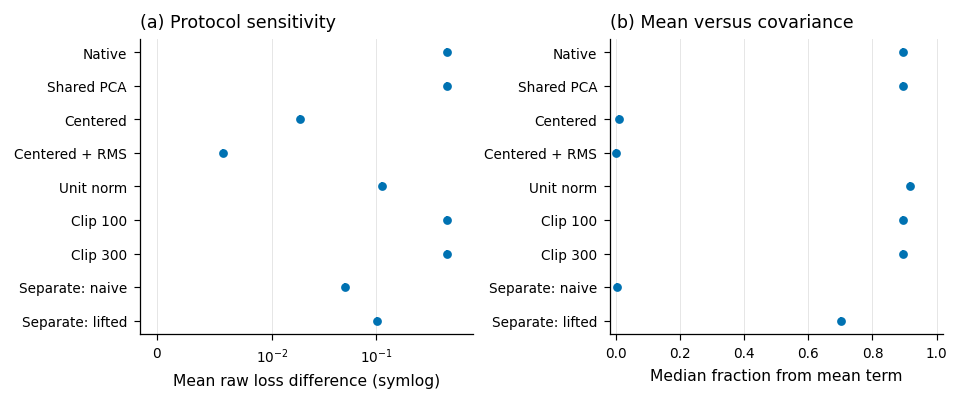

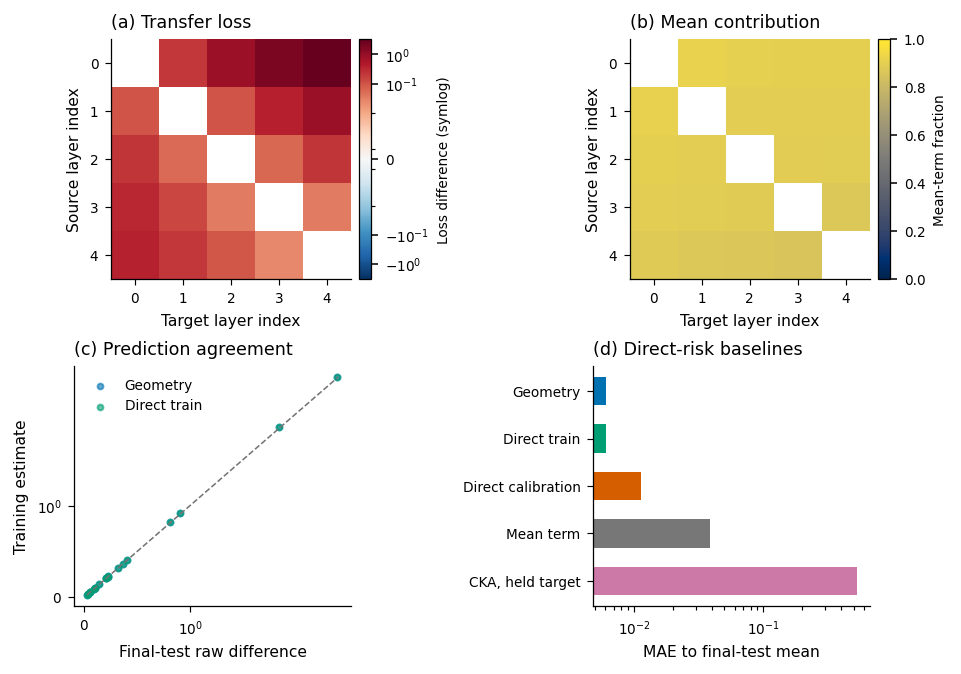

n_cal,method,action,mean_width,accepted_fraction,accepted_test_mean,geometry_raw_mae,direct_train_raw_mae,direct_cal_raw_mae
32,bernstein,unaligned,2,0,NaN,0.0012102,0.00123986,0.0139194
32,bernstein,aligned,2,0,NaN,0.0012102,0.00123986,0.0139194
32,betting,unaligned,0.682019,0,NaN,0.0012102,0.00123986,0.0139194
32,betting,aligned,0.681174,0,NaN,0.0012102,0.00123986,0.0139194
64,bernstein,unaligned,1.92774,0,NaN,0.0012102,0.00123986,0.0133121
64,bernstein,aligned,1.89906,0,NaN,0.0012102,0.00123986,0.0133121
64,betting,unaligned,0.378964,0,NaN,0.0012102,0.00123986,0.0133121
64,betting,aligned,0.378062,0,NaN,0.0012102,0.00123986,0.0133121
128,bernstein,unaligned,0.966495,0,NaN,0.0012102,0.00123986,0.00539173
128,bernstein,aligned,0.945018,0,NaN,0.0012102,0.00123986,0.00539173


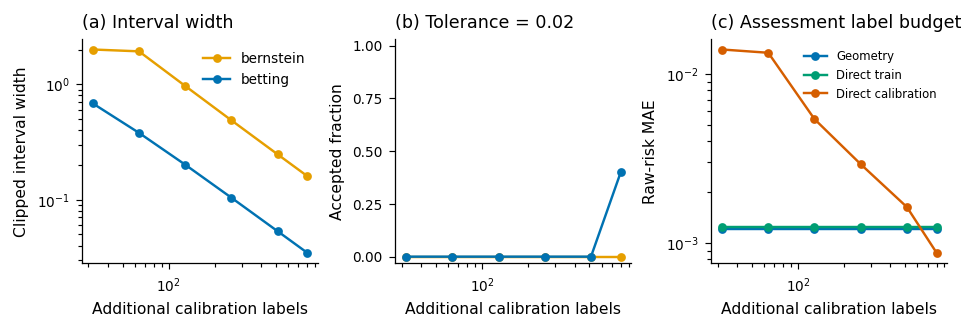

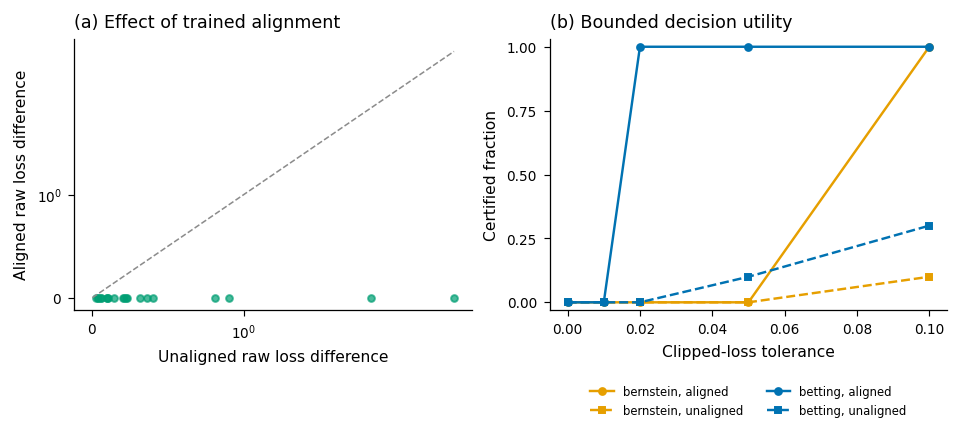

[COMPLETED] full_synthetic_protocols: 9 protocols with paired IDs and fixed calibration/test


In [14]:
def shifted_multilayer(n=2400,d=10,L=5,seed=0):
    rng=rng_for("shifted_multilayer",seed,n,d,L);z=rng.normal(size=(n,d));theta=np.linspace(1,.1,d);theta/=np.linalg.norm(theta)
    X=[]
    for j in range(L):
        Q=np.eye(d);angle=.18*j;Q[:2,:2]=[[np.cos(angle),-np.sin(angle)],[np.sin(angle),np.cos(angle)]]
        X.append((.7+.3*j)*(z@Q.T+.12*rng.normal(size=z.shape))+j*.5*np.linspace(1,.2,d))
    return np.stack(X,1),.5*np.tanh(z@theta+.15*rng.normal(size=n)),np.array([f"simulation-{seed}-{i}" for i in range(n)])
DEMO_X,DEMO_Y,DEMO_IDS=shifted_multilayer()
DEMO_RESULTS={};demo_summary=[];demo_specs=protocol_registry(6)
for spec in demo_specs:
    result=run_experiment(DEMO_X,DEMO_Y,DEMO_IDS,(1000,800,600),31,spec,.5,len(demo_specs))
    DEMO_RESULTS[spec["name"]]=result
    demo_summary.append(summarize_result(result,"synthetic_mean_scale",spec["name"],0))
show_table("synthetic_protocol_summary",demo_summary)
show_table("synthetic_all_baselines",pd.concat([r["performance"].assign(protocol=k) for k,r in DEMO_RESULTS.items()],ignore_index=True))
for name,r in DEMO_RESULTS.items():TABLES["synthetic_pairs__"+name]=r["frame"]
plot_control_summary(demo_summary,"fig04_synthetic_controls","Controlled paired simulation with mean/scale shifts")
plot_pair_diagnostics(DEMO_RESULTS["shared_raw"],"fig05_synthetic_pair_diagnostics","Synthetic raw shared-PCA protocol")
budgets=label_budget_study(DEMO_RESULTS["shared_rms"],.5,len(demo_specs))
show_table("synthetic_label_budget",budgets);plot_budgets(budgets,"fig06_synthetic_label_budget","Synthetic centered/RMS protocol")
plot_alignment(DEMO_RESULTS["shared_raw"],"fig08_synthetic_alignment","Synthetic raw shared-PCA protocol")
checked("corrected geometry equals direct train across all protocols",all(np.allclose(r["frame"].train_geometry+r["frame"].residual_correction,r["frame"].train_raw) for r in DEMO_RESULTS.values()))
checked("prediction mean/covariance decomposition across all protocols",all(np.allclose(r["frame"].train_mean_term+r["frame"].train_variance_term,r["frame"].train_geometry) for r in DEMO_RESULTS.values()))
status("full_synthetic_protocols","COMPLETED",f"{len(demo_specs)} protocols with paired IDs and fixed calibration/test")


## 11. Real data, consistent block features, and reusable caches
Models: GPT-2, Pythia-160m, BERT-base, GPT-2-medium. Tasks: SST-2, AG News Sports-v-rest, CoLA,
Allociné French sentiment, and next-token surprise. Allociné-trained probes are a language-robustness
experiment, not cross-lingual head transfer. The separate SST-2→Allociné domain experiment does transfer
English-trained heads, while still using French labels for target references and assessment.

Primary features are **block outputs captured with forward hooks**, before the model's terminal layer
normalization. GPT-2 uses right padding and the last real token; BERT uses CLS. NLL features use the
preceding context position. NLL labels are clipped to 10 nats and transformed as `NLL/10 - 0.5`;
raw loss in that task is therefore in normalized units (multiply by 100 to obtain squared-nat units).
Feature norm clipping is absent from primary acquisition and appears only as a named analysis intervention.

Bundles contain native `X[n,L,d]`, `y[n]`, unique normalized-text-hash `ids[n]`, and JSON `meta` with
`native_features`, `model_id`, `model_revision`, `dataset`, `dataset_revision`, `layer_ids`, and
`hidden_state_convention`. External v2 API-state bundles are accepted only when explicitly allowed below;
they are labeled legacy, never mistaken for consistent v3 block outputs. Model/dataset commits are locked.


In [15]:
DATASETS = {
    "sst2":("nyu-mll/glue","sst2","sentence"),
    "cola":("nyu-mll/glue","cola","sentence"),
    "agnews":("fancyzhx/ag_news",None,"text"),
    "imdb":("stanfordnlp/imdb",None,"text"),
    "allocine":("tblard/allocine",None,"review"),
}
MODELS = {"gpt2":"openai-community/gpt2", "pythia":"EleutherAI/pythia-160m",
          "bert":"google-bert/bert-base-uncased", "gpt2_medium":"openai-community/gpt2-medium"}
REAL_JOBS = [
    ("gpt2_sst2","gpt2","sst2",False), ("gpt2_agnews","gpt2","agnews",False),
    ("gpt2_cola","gpt2","cola",False), ("pythia_sst2","pythia","sst2",False),
    ("bert_sst2","bert","sst2",False), ("gpt2_medium_sst2","gpt2_medium","sst2",False),
    ("gpt2_allocine","gpt2","allocine",False), ("gpt2_nll","gpt2","sst2",True),
]
EXTRACTION_CODE_VERSION="native-v3-consistent-block-hooks-20260927"
REVISION_LOCK_FILE=OUTPUT_ROOT/"revision_lock_v3.json"
REVISION_LOCK=json.loads(REVISION_LOCK_FILE.read_text()) if REVISION_LOCK_FILE.exists() else {}


In [16]:
def normalized_text(text): return " ".join(str(text).lower().split())

def text_id(text): return hashlib.sha256(normalized_text(text).encode()).hexdigest()

def resolve_revision(repo_id,repo_type):
    from huggingface_hub import HfApi
    key=repo_type+":"+repo_id
    if key not in REVISION_LOCK:
        api=HfApi()
        info=api.model_info(repo_id) if repo_type=="model" else api.dataset_info(repo_id)
        if not info.sha: raise ValueError("Repository did not resolve to a commit")
        REVISION_LOCK[key]=info.sha
        write_json(REVISION_LOCK_FILE,REVISION_LOCK)
    MANIFEST["resolved_revisions"][key]=REVISION_LOCK[key]
    return REVISION_LOCK[key]

def real_sizes(dataset):
    if RUN_MODE in {"smoke","pilot"}: return (1024,512,512)
    return (5000,1500,1500) if dataset=="cola" else (12000,3000,3000)

def load_text_pool(dataset,n,exclude_ids=()):
    from datasets import load_dataset
    repo,subset,textcol=DATASETS[dataset]
    revision=resolve_revision(repo,"dataset")
    kwargs={"split":"train","revision":revision}
    data=load_dataset(repo,subset,**kwargs) if subset else load_dataset(repo,**kwargs)
    excluded=set(exclude_ids); seen=set(); conflicts=set(); records=[]; first_labels={}
    for row in data:
        txt=str(row[textcol]); key=text_id(txt)
        if not normalized_text(txt) or key in excluded: continue
        label=float(int(row["label"])==1)-.5 if dataset=="agnews" else float(row["label"])-.5
        if key in first_labels and first_labels[key]!=label: conflicts.add(key)
        first_labels.setdefault(key,label)
        if key not in seen:
            seen.add(key); records.append((key,txt,label))
    records=[r for r in records if r[0] not in conflicts]
    if len(records)<n: raise ValueError(f"{dataset}: only {len(records)} unique eligible examples for {n} requested")
    order=rng_for("text_pool",dataset).permutation(len(records))[:n]
    selected=[records[i] for i in order]
    ids=np.array([r[0] for r in selected]); texts=[r[1] for r in selected]; y=np.array([r[2] for r in selected])
    meta={"dataset":dataset,"dataset_repo":repo,"dataset_revision":revision,"source_split":"train",
          "pool_sampling_seed":MASTER_SEED,"dedup":"lowercase whitespace-normalized exact text",
          "conflicting_duplicate_ids_removed":len(conflicts),"label_task":"Sports-v-rest" if dataset=="agnews" else "binary"}
    return texts,y,ids,meta

def validate_bundle(bundle):
    X,y,ids,meta=bundle["X"],bundle["y"],bundle["ids"],bundle["meta"]
    if X.ndim!=3 or len(y)!=len(X) or len(ids)!=len(X) or y.ndim!=1:
        raise ValueError("Expected X: examples x layers x width, y: examples, ids: examples")
    if X.shape[1]<3 or X.shape[2]<2: raise ValueError("At least three layers and two native dimensions required")
    if len(np.unique(ids.astype(str)))!=len(ids): raise ValueError("Feature bundle has duplicate IDs")
    if not np.isfinite(X).all() or not np.isfinite(y).all(): raise ValueError("Non-finite feature or label values")
    required=["native_features","model_id","model_revision","dataset_revision","layer_ids"]
    if any(k not in meta for k in required) or meta["native_features"] is not True:
        raise ValueError("Native-coordinate provenance metadata is required")
    if len(meta["layer_ids"])!=X.shape[1] or len(set(meta["layer_ids"]))!=X.shape[1]:
        raise ValueError("Layer IDs do not match feature tensor")
    return bundle

def save_bundle(path,bundle):
    validate_bundle(bundle)
    np.savez_compressed(path,X=np.asarray(bundle["X"],np.float32),y=np.asarray(bundle["y"],float),
                        ids=np.asarray(bundle["ids"]).astype(str),meta=np.array(json.dumps(bundle["meta"],default=jsonable)))

def load_bundle(path):
    with np.load(path,allow_pickle=False) as z:
        bundle={"X":z["X"],"y":z["y"],"ids":z["ids"].astype(str),"meta":json.loads(str(z["meta"].item()))}
    return validate_bundle(bundle)

def extract_bundle(model_key,dataset,n,nll=False,exclude_ids=()):
    import torch
    from transformers import AutoModel,AutoModelForCausalLM,AutoTokenizer,AutoConfig
    texts,y,ids,meta=load_text_pool(dataset,n+(128 if nll else 0),exclude_ids)
    model_id=MODELS[model_key]; revision=resolve_revision(model_id,"model")
    conf=AutoConfig.from_pretrained(model_id,revision=revision,trust_remote_code=False)
    depth=int(getattr(conf,"num_hidden_layers",getattr(conf,"n_layer",0)))
    if depth<3: raise ValueError("Could not determine model depth")
    layer_ids=np.unique(np.rint(np.linspace(1,depth,min(12,depth))).astype(int)).tolist()
    extraction={"code_version":EXTRACTION_CODE_VERSION,"model_id":model_id,"model_revision":revision,
        "dataset_revision":meta["dataset_revision"],"ordered_ids_hash":hashlib.sha256("".join(ids).encode()).hexdigest(),
        "ordered_text_bytes_hash":hashlib.sha256(json.dumps(texts,ensure_ascii=False).encode()).hexdigest(),
        "labels_hash":hashlib.sha256(y.tobytes()).hexdigest(),"layer_ids":layer_ids,
        "max_length":CFG.max_length,"batch_size":CFG.batch_size,"padding_side":"right","nll":nll,"nll_cap":CFG.nll_cap,
        "pooling":"previous context token" if nll else ("CLS" if model_key=="bert" else "last real token"),
        "capture_kind":CFG.extraction_kind,"dtype":"float32","transformers_version":versions.get("transformers"),"torch_version":versions.get("torch")}
    digest=hashlib.sha256(json.dumps(extraction,sort_keys=True).encode()).hexdigest()
    path=CACHE_DIR/(digest+".npz")
    if path.exists():
        bundle=load_bundle(path)
        if bundle["meta"].get("extraction")!=extraction: raise ValueError("Cache metadata mismatch")
        return bundle
    torch.manual_seed(MASTER_SEED)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(MASTER_SEED)
    torch.use_deterministic_algorithms(True,warn_only=True)
    if hasattr(torch.backends,"cudnn"):
        torch.backends.cudnn.benchmark=False
    device="cuda" if torch.cuda.is_available() else "cpu"
    tok=AutoTokenizer.from_pretrained(model_id,revision=revision,trust_remote_code=False)
    tok.padding_side="right"
    if tok.pad_token_id is None:
        if tok.eos_token_id is None: raise ValueError("Tokenizer lacks both pad and EOS tokens")
        tok.pad_token=tok.eos_token
    cls=AutoModelForCausalLM if nll else AutoModel
    model=cls.from_pretrained(model_id,revision=revision,trust_remote_code=False).to(device).eval()
    collected=[]; nll_values=[]
    captured={}; handles=[]
    if CFG.extraction_kind=="block_output":
        if model_key in {"gpt2","gpt2_medium"}: blocks=(model.transformer if hasattr(model,"transformer") else model).h
        elif model_key=="pythia": blocks=(model.gpt_neox if hasattr(model,"gpt_neox") else model).layers
        elif model_key=="bert": blocks=(model.bert if hasattr(model,"bert") else model).encoder.layer
        else: raise ValueError("Unsupported block-hook architecture")
        def make_hook(index):
            def hook(module,args,output): captured[index]=output[0] if isinstance(output,(tuple,list)) else output
            return hook
        for index in layer_ids: handles.append(blocks[index-1].register_forward_hook(make_hook(index)))
    start=time.perf_counter()
    for left in range(0,len(texts),CFG.batch_size):
        encoded=tok(texts[left:left+CFG.batch_size],padding=True,truncation=True,
                    max_length=CFG.max_length,return_tensors="pt").to(device)
        lengths=encoded["attention_mask"].sum(1)
        kwargs=dict(encoded,output_hidden_states=(CFG.extraction_kind!="block_output"),return_dict=True)
        if model_key!="bert": kwargs["use_cache"]=False
        with torch.inference_mode():
            out=model(**kwargs)
        rows=torch.arange(len(lengths),device=device)
        index=torch.clamp(lengths-(2 if nll else 1),min=0)
        if model_key=="bert" and not nll: index=torch.zeros_like(index)
        states=captured if CFG.extraction_kind=="block_output" else {j:out.hidden_states[j] for j in layer_ids}
        hidden=torch.stack([states[j][rows,index,:].float().cpu() for j in layer_ids],dim=1).numpy()
        collected.append(hidden)
        if nll:
            target=encoded["input_ids"][rows,torch.clamp(lengths-1,min=0)]
            loss=torch.nn.functional.cross_entropy(out.logits[rows,index,:].float(),target,reduction="none")
            values=loss.detach().cpu().numpy(); values[lengths.cpu().numpy()<2]=np.nan
            nll_values.append(values)
    for handle in handles: handle.remove()
    X=np.concatenate(collected)
    raw_nll=None
    if nll:
        raw_nll=np.concatenate(nll_values); keep=np.flatnonzero(np.isfinite(raw_nll))[:n]
        if len(keep)<n: raise ValueError("Too few texts with at least two tokens for NLL")
        X,ids=X[keep],ids[keep]; raw_nll=raw_nll[keep]; y=np.clip(raw_nll,0,CFG.nll_cap)
    meta.update({"native_features":True,"model_id":model_id,"model_revision":revision,"tokenizer_revision":revision,
        "layer_ids":layer_ids,"extraction":extraction,"device":device,"extraction_seconds":time.perf_counter()-start,
        "shape":list(X.shape),"hidden_state_convention":CFG.extraction_kind,
        "nll_clipped_fraction":float(np.mean(raw_nll>CFG.nll_cap)) if raw_nll is not None else None})
    bundle={"X":X,"y":y,"ids":ids,"meta":meta}
    save_bundle(path,bundle)
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return bundle


In [17]:
ALLOW_LEGACY_API_FEATURES=False
def acquire_job(name,model,dataset,nll=False,exclude_ids=()):
    if name in FEATURE_BUNDLES:bundle=load_bundle(FEATURE_BUNDLES[name])
    else:bundle=extract_bundle(model,dataset,sum(real_sizes(dataset)),nll,exclude_ids)
    meta=bundle["meta"]
    if meta["model_id"] not in {MODELS[model],MODELS[model].split("/")[-1]}:raise ValueError("Wrong model in feature bundle")
    if meta.get("dataset")!=dataset:raise ValueError("Wrong dataset in feature bundle")
    convention=meta.get("hidden_state_convention","")
    if convention!="block_output" and not ALLOW_LEGACY_API_FEATURES:
        raise ValueError("Legacy/API hidden states: use v3 extraction or explicitly enable legacy analysis")
    if bool(meta.get("extraction",{}).get("nll",False))!=bool(nll):raise ValueError("NLL task metadata mismatch")
    if exclude_ids:
        keep=~np.isin(bundle["ids"],np.asarray(exclude_ids));bundle={**bundle,"X":bundle["X"][keep],"y":bundle["y"][keep],"ids":bundle["ids"][keep]}
    if nll:
        bundle={**bundle,"y":np.clip(bundle["y"],0,CFG.nll_cap)/CFG.nll_cap-.5,
                "meta":{**meta,"analysis_label_transform":"clip(NLL,0,10)/10 - 0.5"}}
    if np.max(abs(bundle["y"]))>.5+1e-8:raise ValueError("Labels must lie in [-0.5,0.5]")
    h=hashlib.sha256()
    for i in range(0,len(bundle["X"]),64):h.update(np.ascontiguousarray(bundle["X"][i:i+64]).tobytes())
    h.update(bundle["y"].tobytes());h.update("".join(bundle["ids"]).encode())
    bundle["content_hash"]=h.hexdigest()
    write_json(RUN_DIR/(name+"_feature_metadata.json"),{**bundle["meta"],"content_hash":bundle["content_hash"]})
    return bundle

def save_experiment(folder,result,ids,config):
    folder.mkdir(parents=True,exist_ok=True)
    for name in ["frame","performance","decisions","diagnostics"]:result[name].to_csv(folder/(name+".csv"),index=False)
    model={};fit=result["fit"]
    for j,(policy,m,p) in enumerate(zip(fit["policies"],fit["maps"],fit["probes"])):
        model[f"policy_mean_{j}"]=policy.mean;model[f"policy_scale_{j}"]=np.array(policy.scale)
        model[f"policy_cap_{j}"]=np.array(np.nan if policy.cap is None else policy.cap)
        model[f"map_mean_{j}"]=m.mean;model[f"map_basis_{j}"]=m.basis;model[f"probe_{j}"]=p.augmented()
        model[f"lambda_{j}"]=np.array(p.lam)
        if "reference_probes" in fit:model[f"target_reference_{j}"]=fit["reference_probes"][j].augmented()
    for s,t in result["stitches"]:model[f"stitch_{s}_{t}"]=result["stitches"][(s,t)].augmented()
    for part,idx in result["split"].items():model[part+"_ids"]=np.asarray(ids)[idx].astype(str)
    np.savez_compressed(folder/"model_and_splits.npz",**model)
    if SAVE_PER_EXAMPLE:np.savez_compressed(folder/"paired_losses.npz",**result["arrays"])
    fit["policy_diagnostics"].to_csv(folder/"feature_diagnostics.csv",index=False)
    write_json(folder/"config.json",config)
    # Atomic completion marker is written last. A partial job is never treated as complete.
    write_json(folder/"COMPLETE.json",{"config_hash":hashlib.sha256(json.dumps(config,sort_keys=True,default=jsonable).encode()).hexdigest()})

def cached_experiment(bundle,sizes,seed,spec,family_multiplier):
    config={"code_version":CODE_VERSION,"feature_hash":bundle["content_hash"],"sizes":list(sizes),"seed":seed,
        "spec":spec,"family_multiplier":family_multiplier,"config":asdict(CFG),"alpha":ALPHA,
        "numpy":versions["numpy"],"scipy":versions["scipy"],"sklearn":versions["scikit-learn"]}
    digest=hashlib.sha256(json.dumps(config,sort_keys=True,default=jsonable).encode()).hexdigest()
    folder=CHECKPOINT_DIR/digest
    USED_CHECKPOINTS.add(folder)
    if (folder/"COMPLETE.json").exists() and (folder/"paired_losses.npz").exists():
        saved=json.loads((folder/"config.json").read_text())
        if saved!=json.loads(json.dumps(config,default=jsonable)):raise ValueError("Checkpoint configuration mismatch")
        out={k:pd.read_csv(folder/(k+".csv")) for k in ["frame","performance","decisions","diagnostics"]}
        with np.load(folder/"paired_losses.npz",allow_pickle=False) as z:out["arrays"]={k:z[k] for k in z.files}
        out["checkpoint"]=str(folder);out["cache_hit"]=True;return out
    result=run_experiment(bundle["X"],bundle["y"],bundle["ids"],sizes,seed,spec,.5,family_multiplier)
    save_experiment(folder,result,bundle["ids"],config)
    result["checkpoint"]=str(folder);result["cache_hit"]=False;return result


## 12. Paper grid and experiments that resume independently
The paper profile uses 12,000 / 3,000 / 3,000 train/calibration/test examples (CoLA: 5,000 / 1,500 / 1,500),
three descriptive split repeats, four primary protocols per repeat, and five additional controls on the
first repeat. Seeds are not independent benchmark datasets. No p-values across layer pairs or overlapping
splits are generated. Similarity metrics use a prespecified training subset capped at 1,024 examples and
a common rank-64 projection for CCA/whitened Procrustes; full-dimensional CKA remains separately defined.

Dimension/ridge and training-size sweeps are exploratory sensitivity studies, with separate conditional
interval families. They must not be pooled into an across-all-tables coverage claim or used to silently
choose the final setting after examining the test set. The model selection rule itself uses training GCV.


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


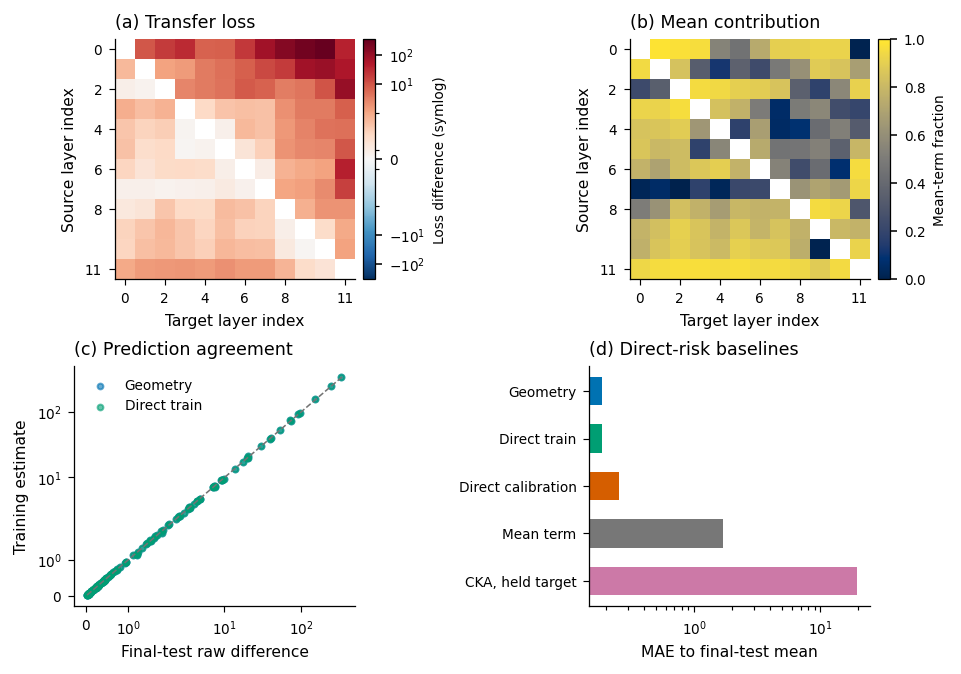

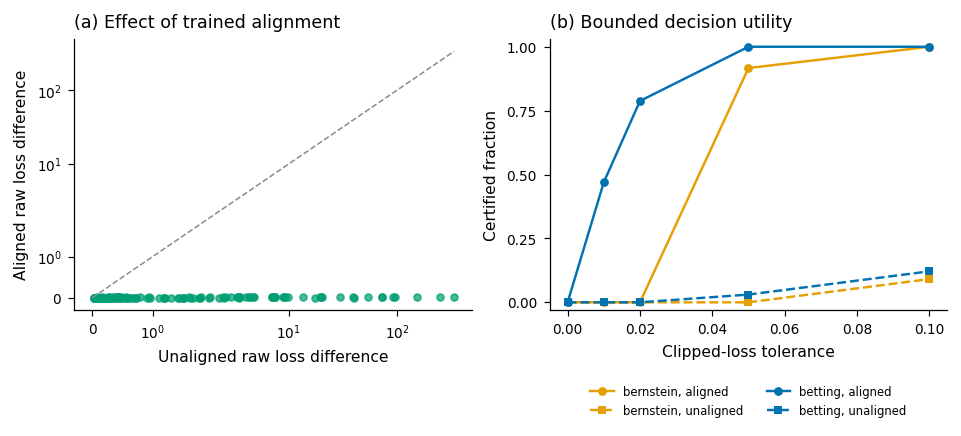

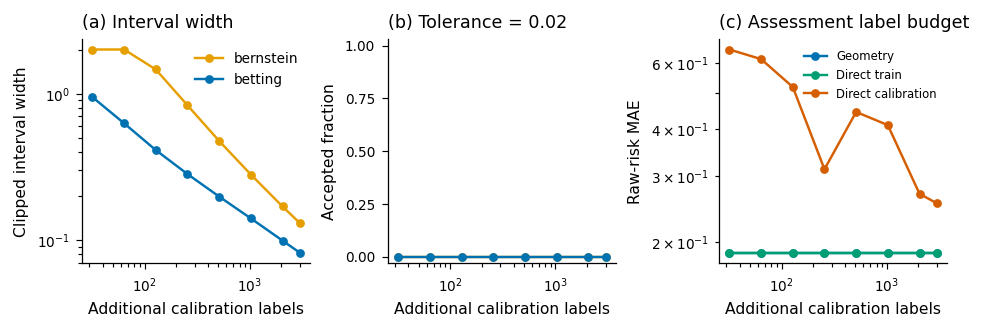

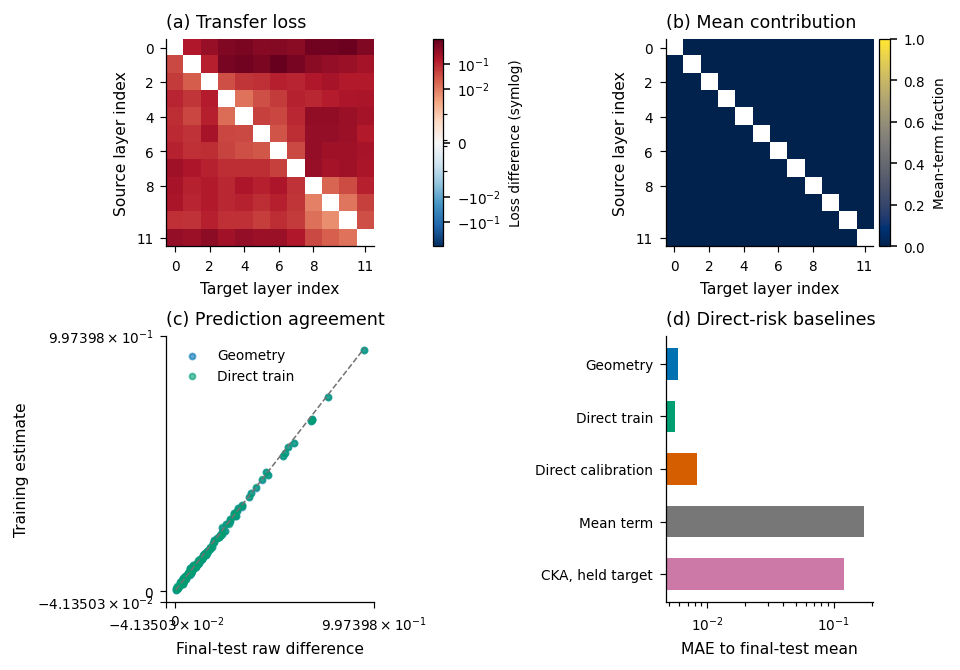

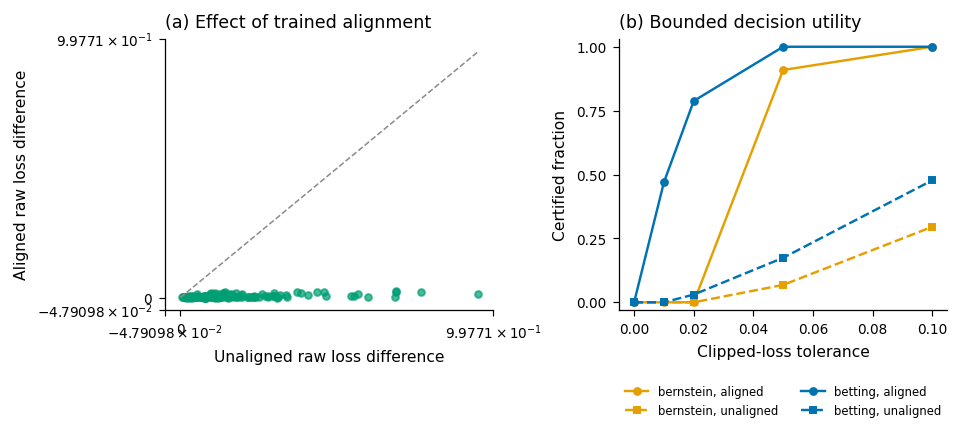

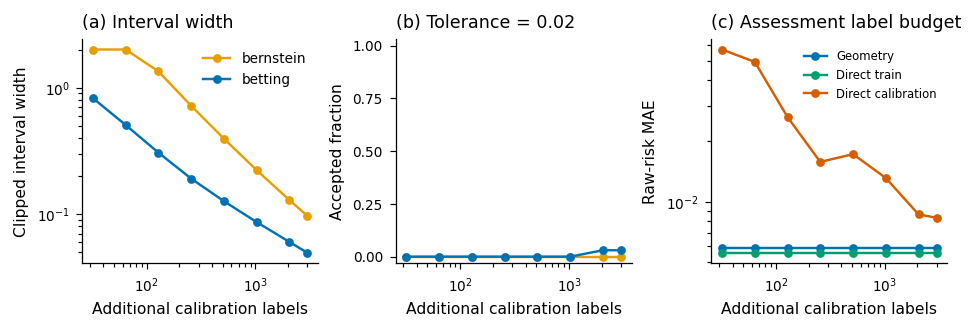

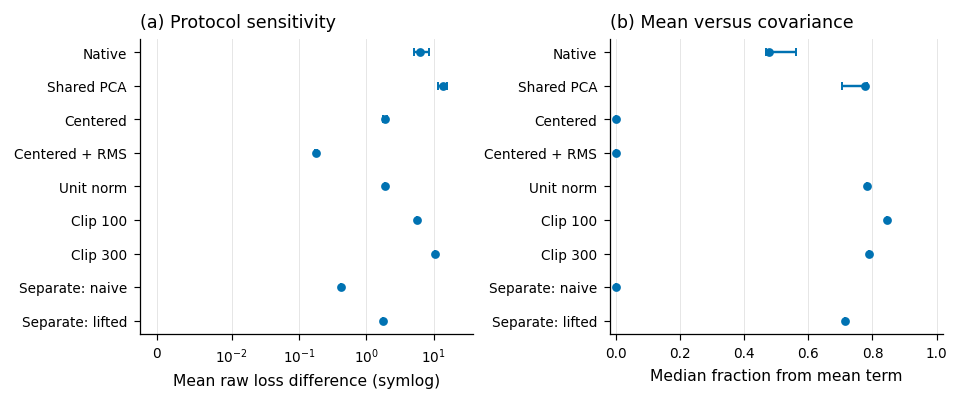

[COMPLETED] gpt2_sst2: 17 protocol/split runs; raw block features; paper profile


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


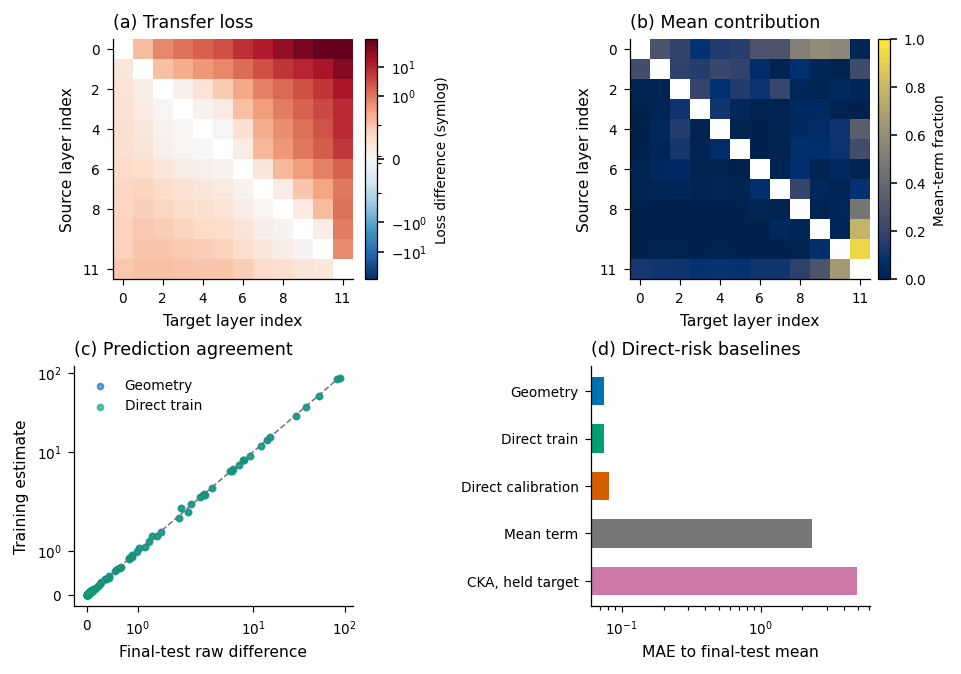

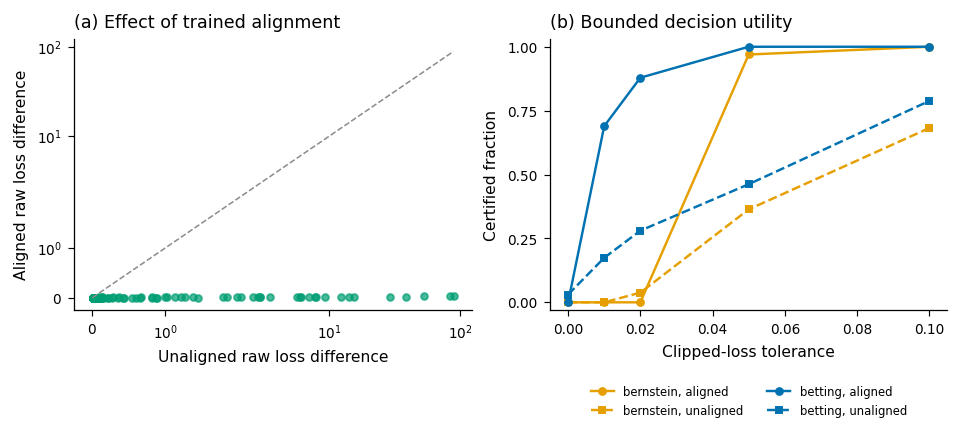

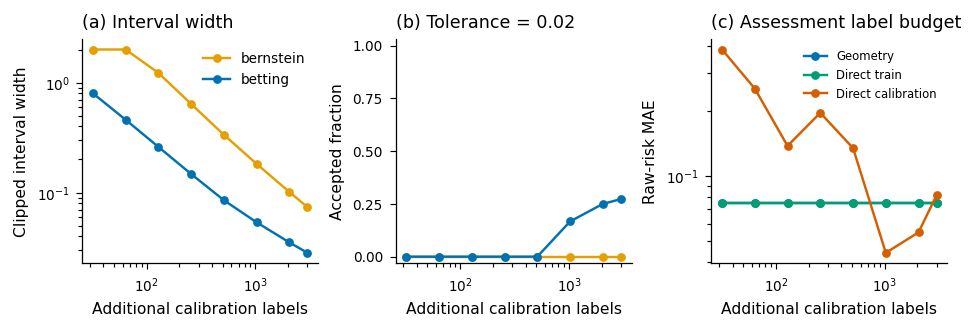

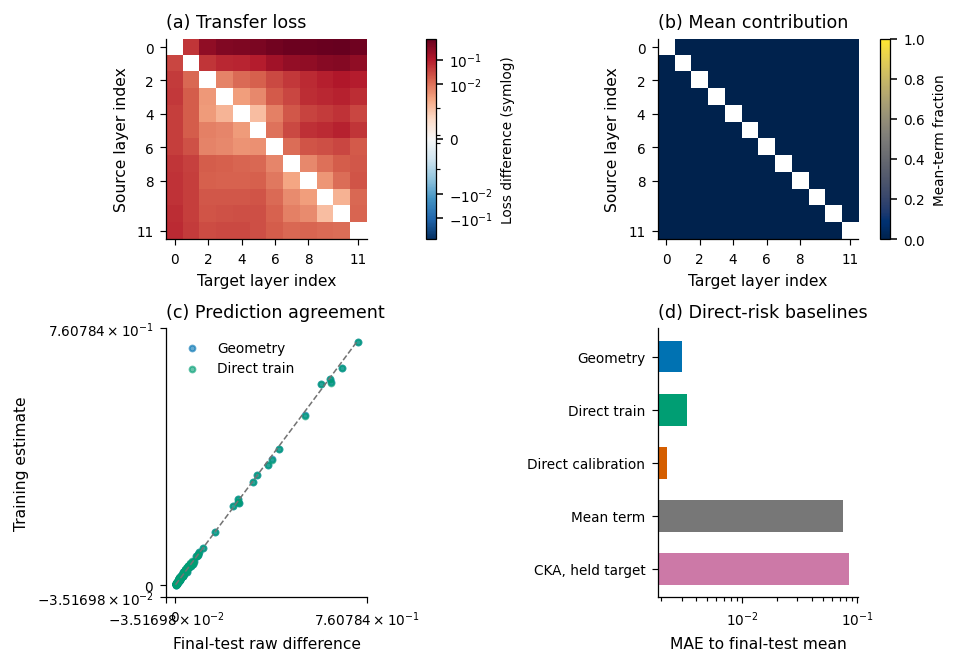

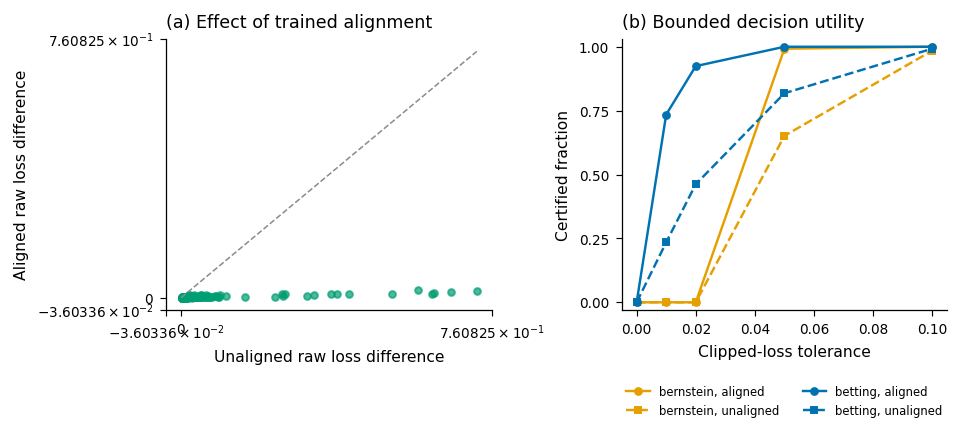

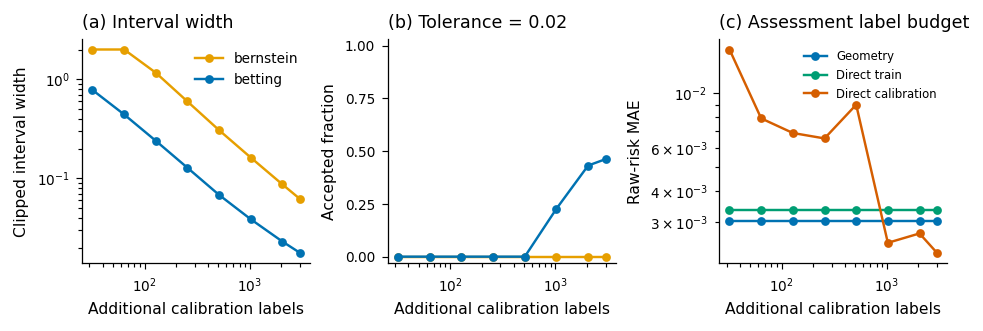

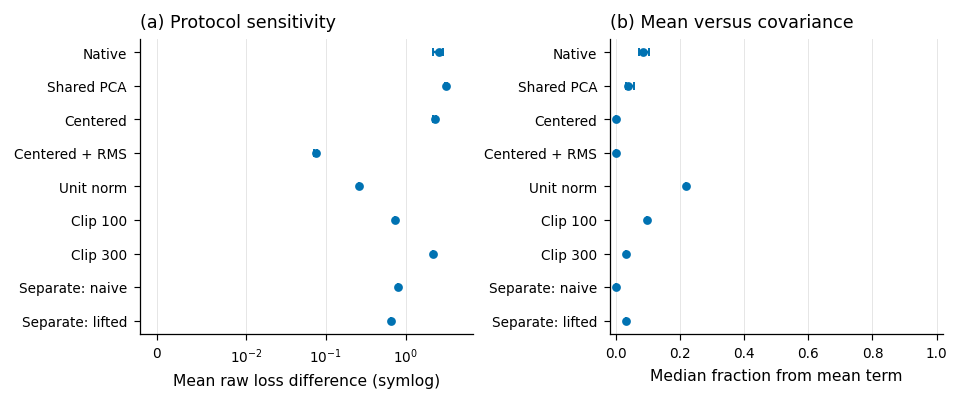

[COMPLETED] gpt2_agnews: 17 protocol/split runs; raw block features; paper profile


cola/train-00000-of-00001.parquet:   0%|          | 0.00/251k [00:00<?, ?B/s]

cola/validation-00000-of-00001.parquet:   0%|          | 0.00/37.6k [00:00<?, ?B/s]

cola/test-00000-of-00001.parquet:   0%|          | 0.00/37.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8551 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1043 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1063 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


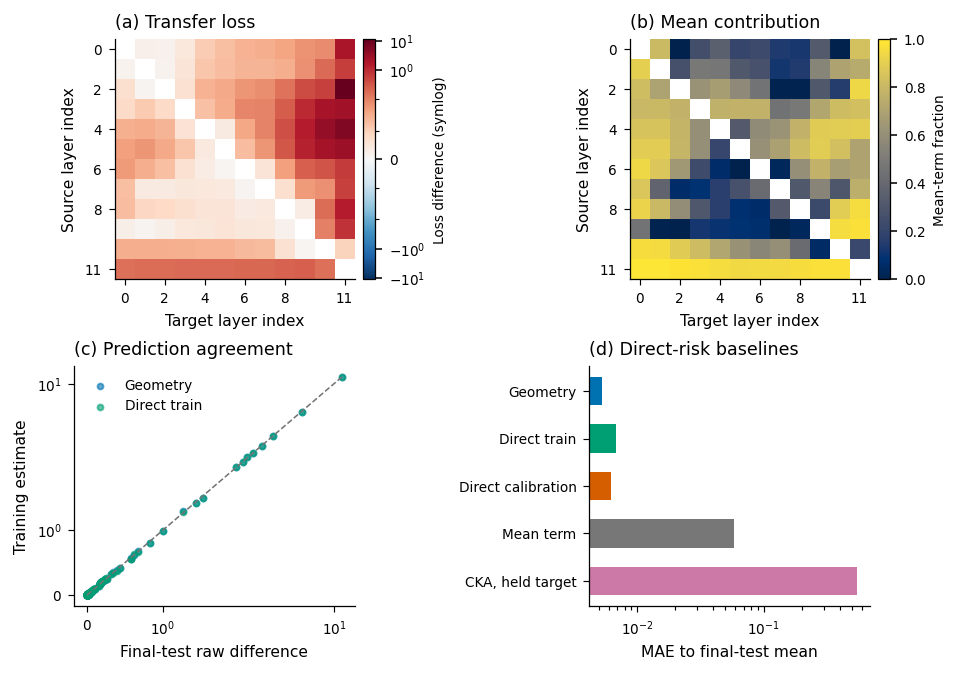

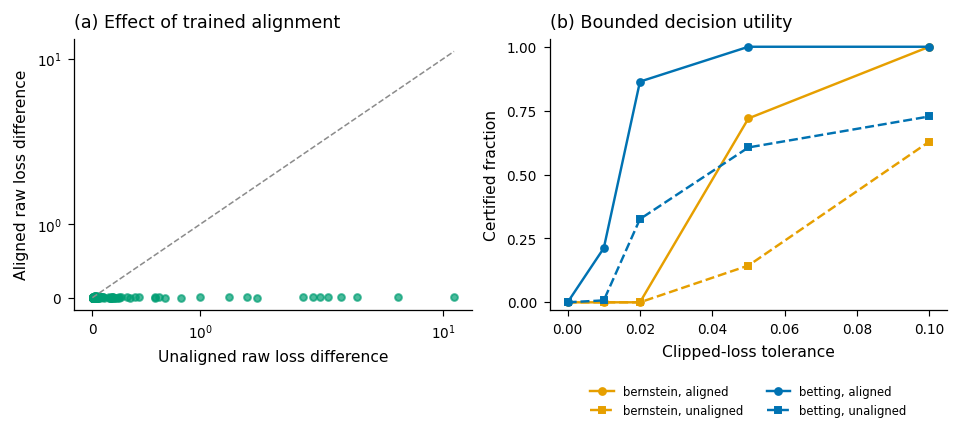

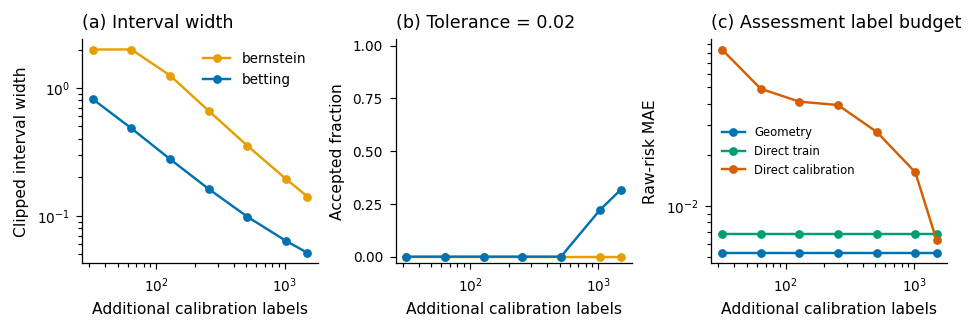

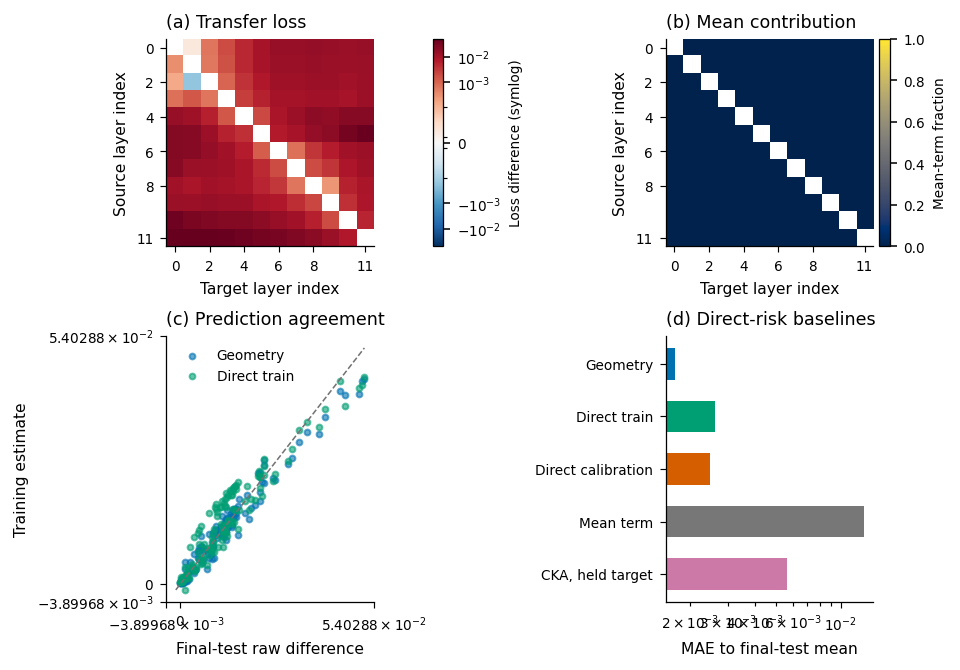

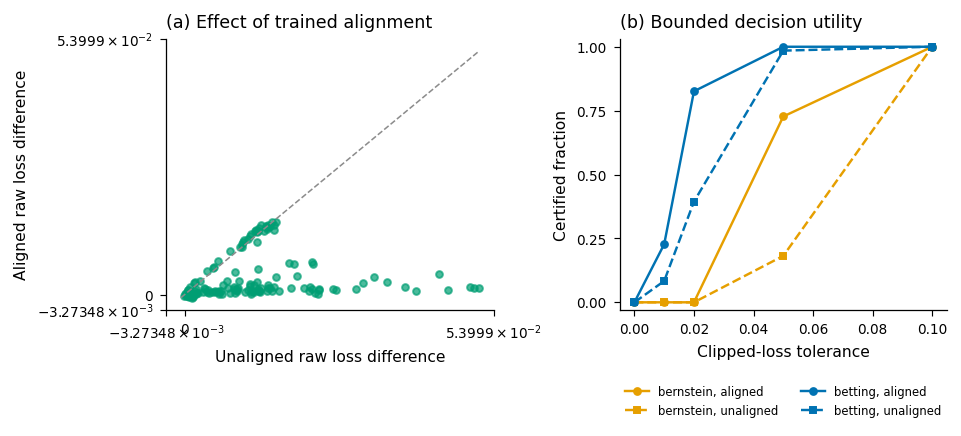

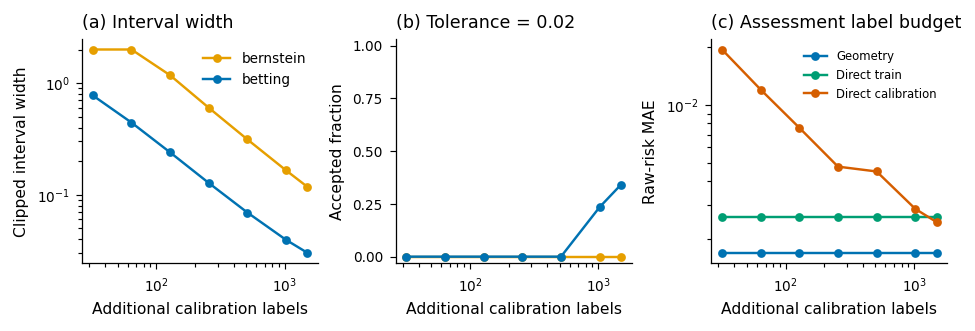

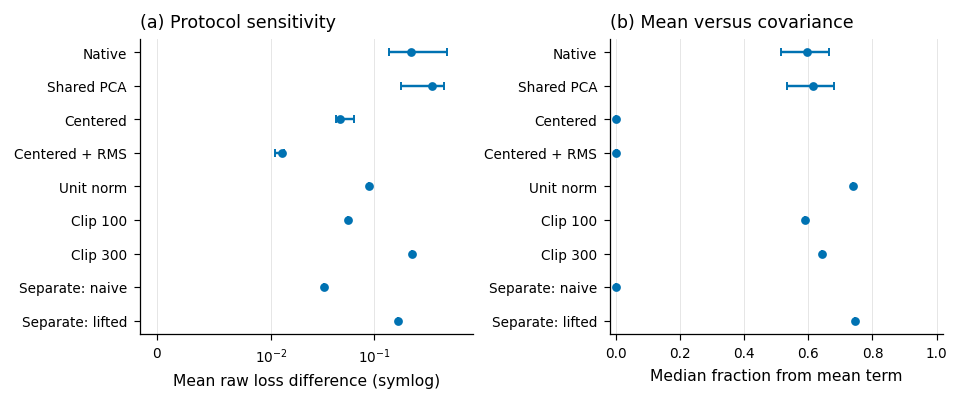

[COMPLETED] gpt2_cola: 17 protocol/split runs; raw block features; paper profile


config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/147 [00:00<?, ?it/s]

GPTNeoXModel LOAD REPORT from: EleutherAI/pythia-160m
Key              | Status     |  | 
-----------------+------------+--+-
embed_out.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


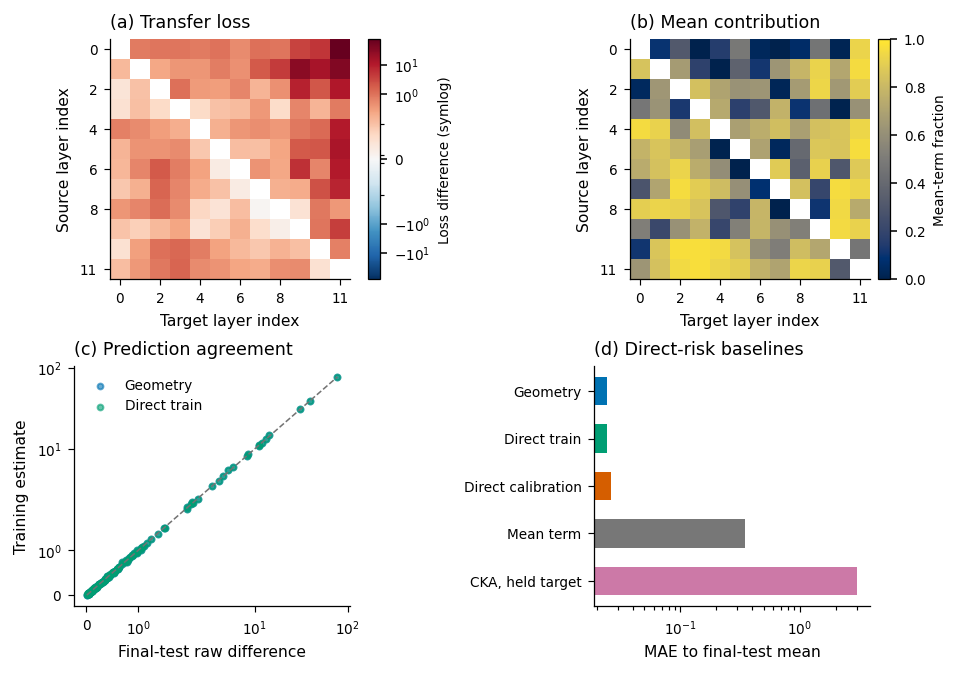

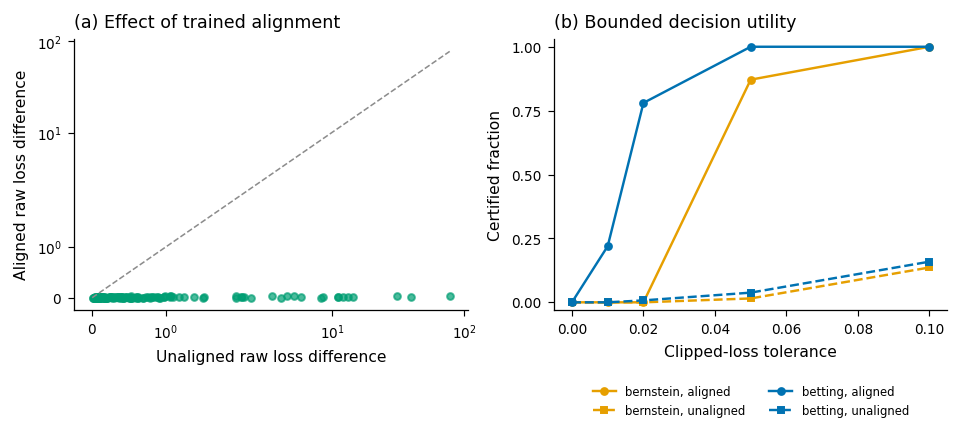

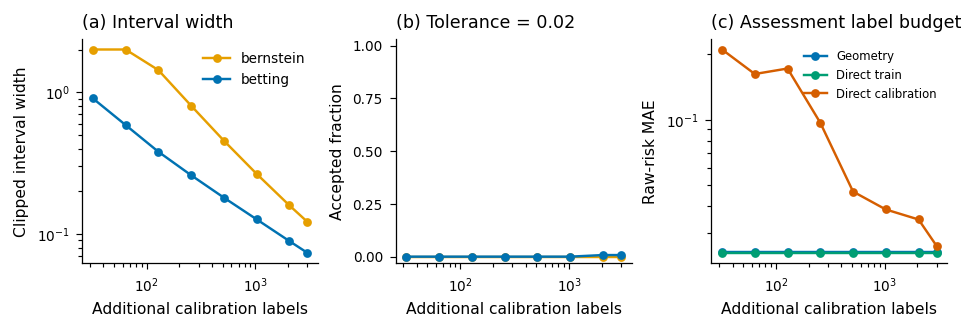

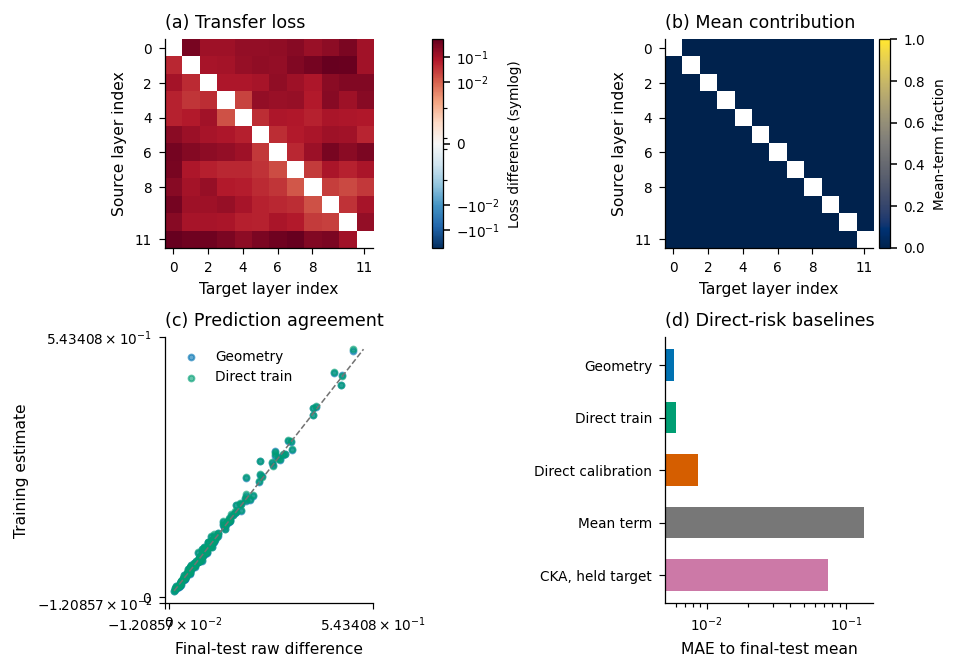

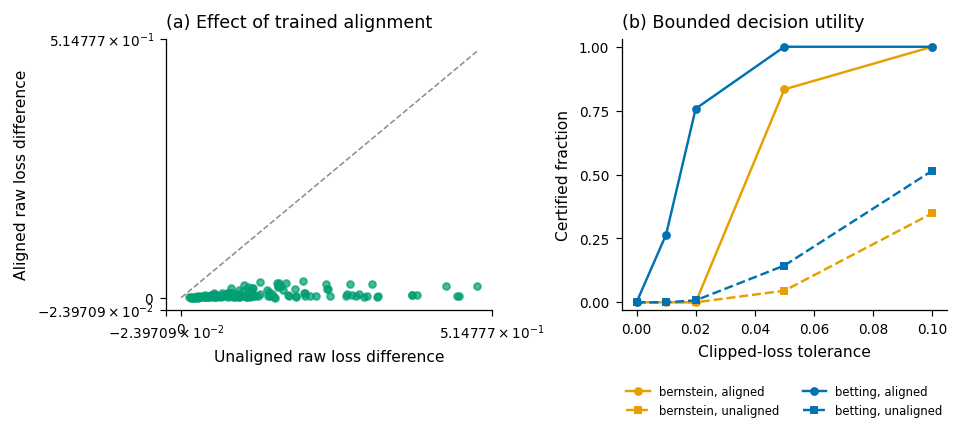

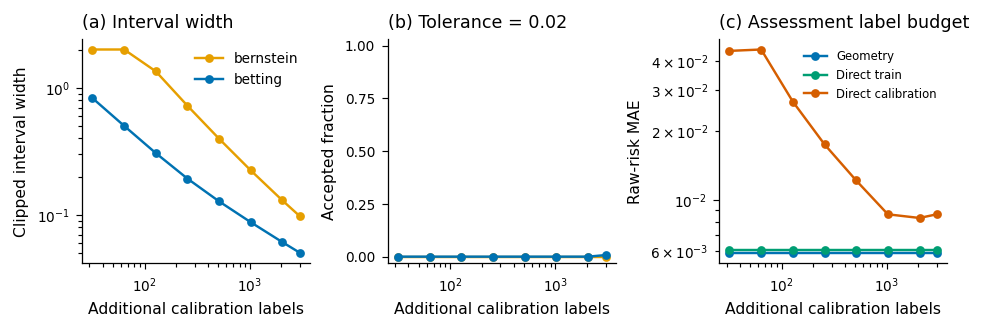

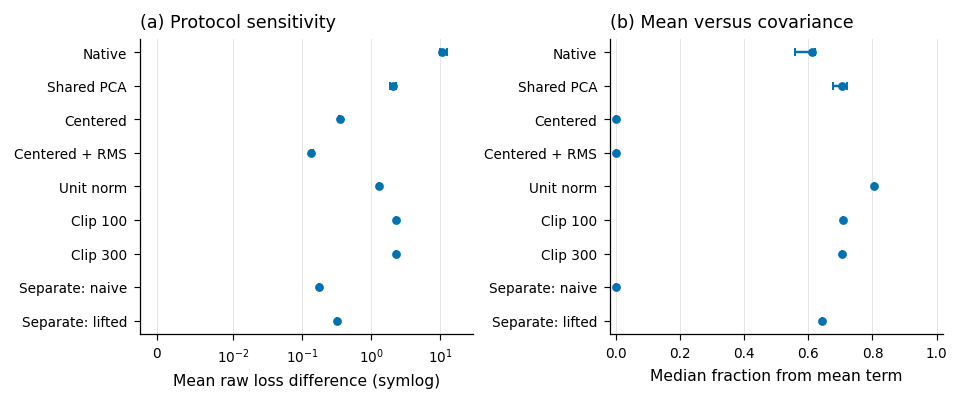

[COMPLETED] pythia_sst2: 17 protocol/split runs; raw block features; paper profile


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


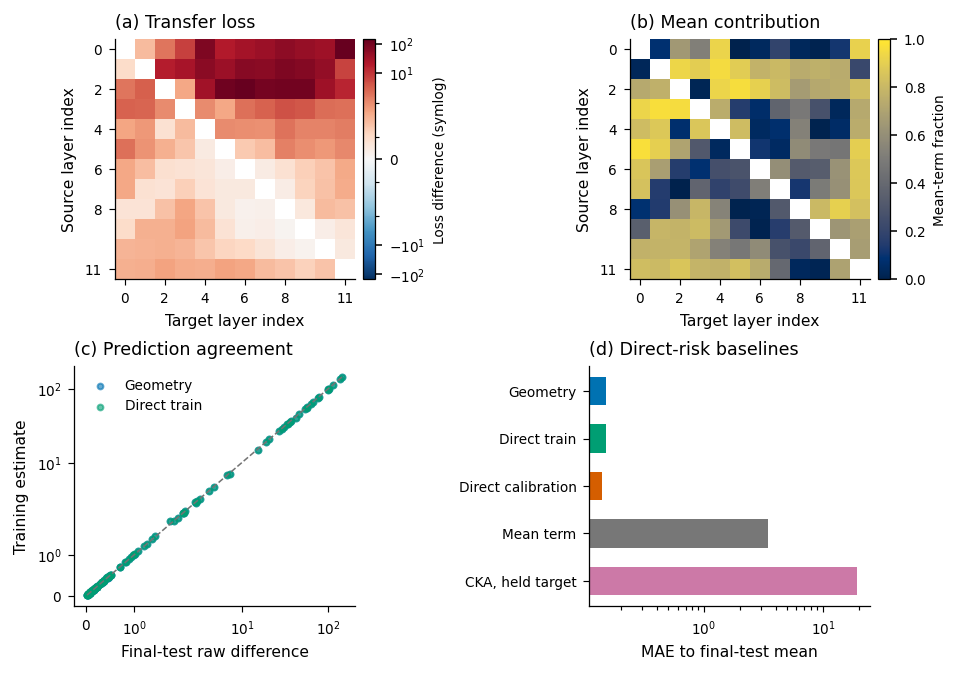

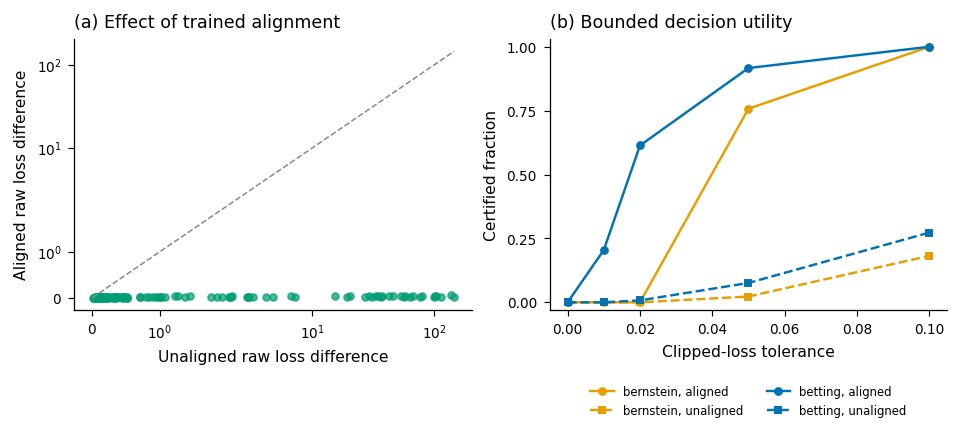

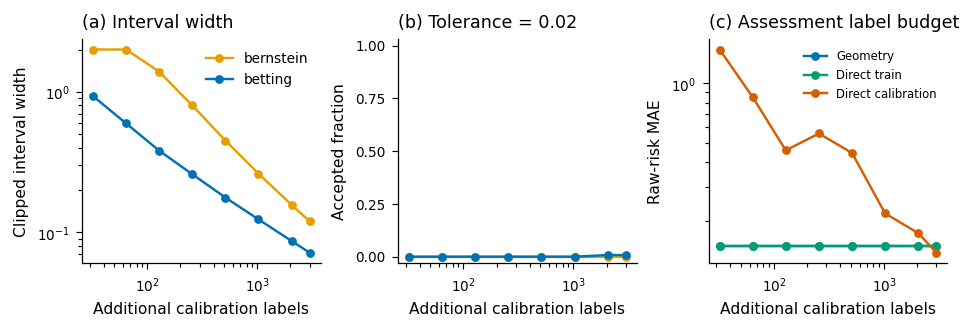

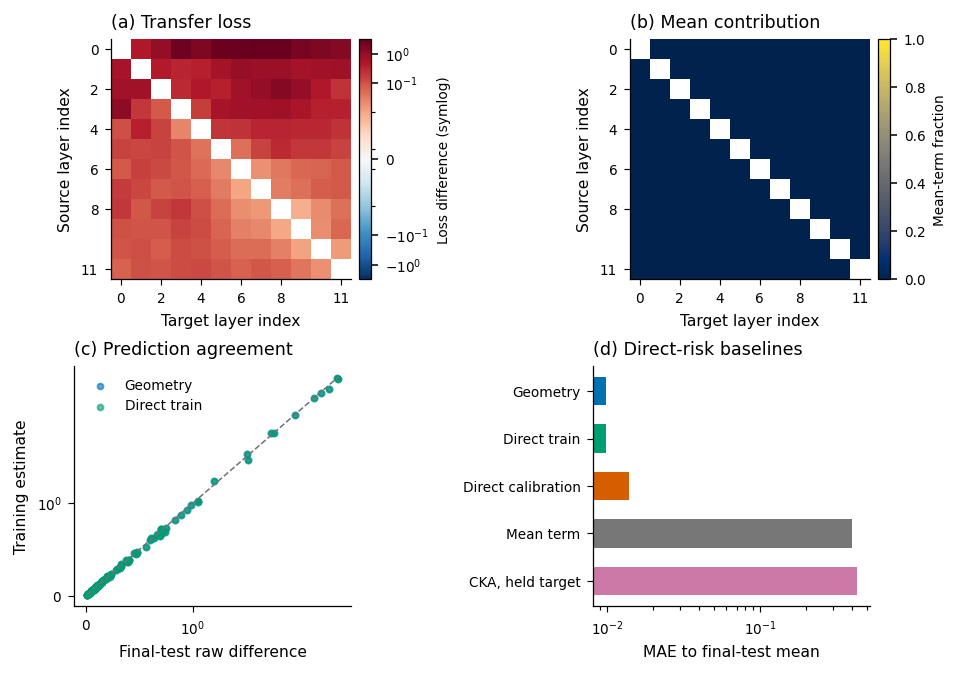

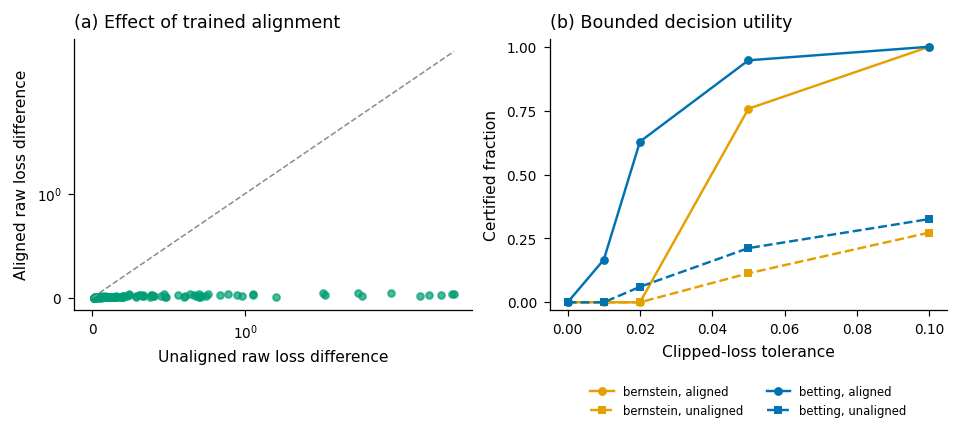

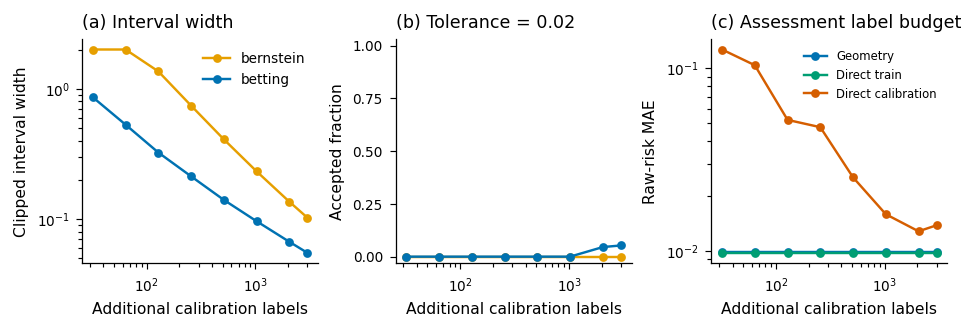

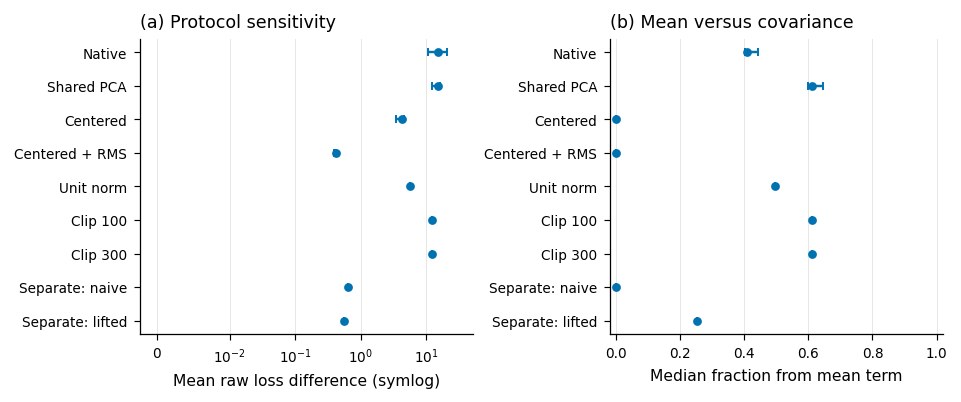

[COMPLETED] bert_sst2: 17 protocol/split runs; raw block features; paper profile


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: openai-community/gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


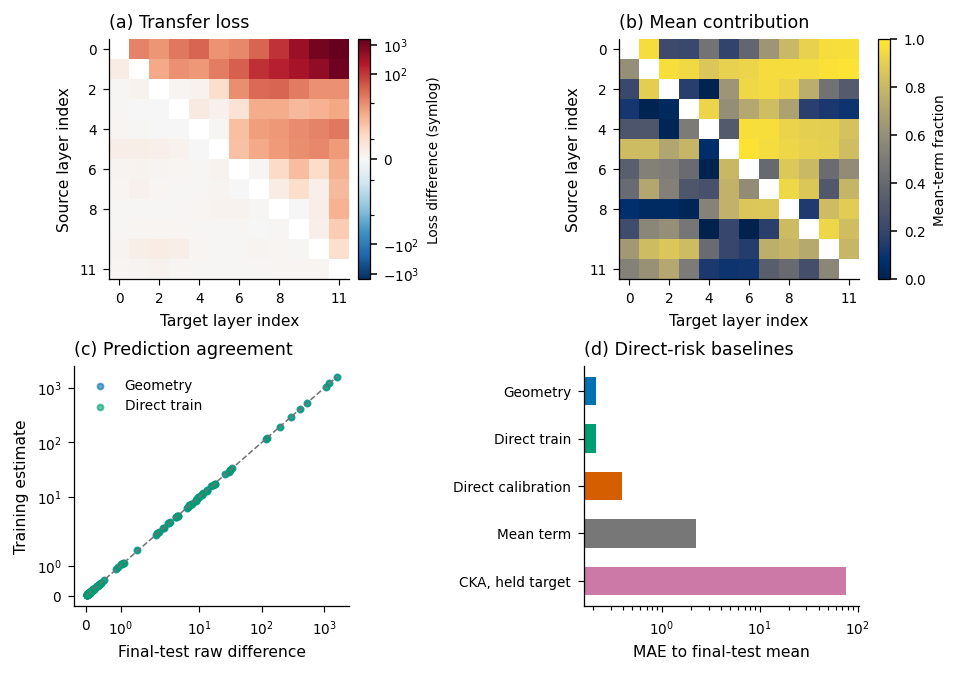

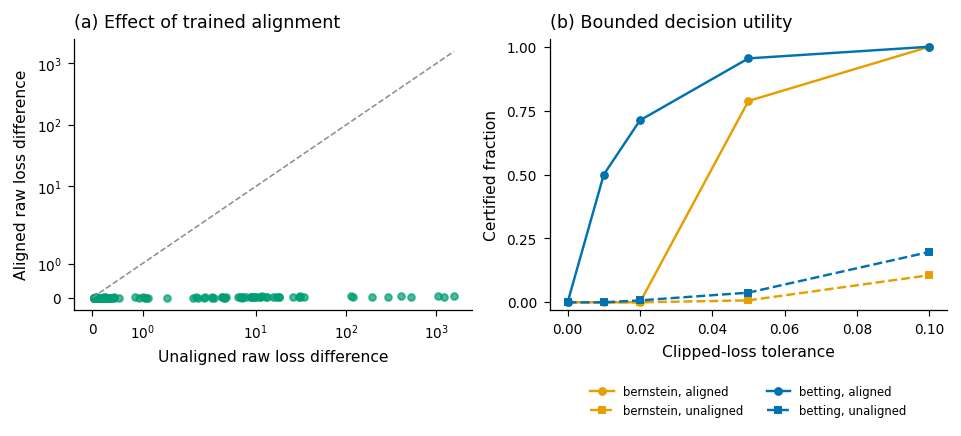

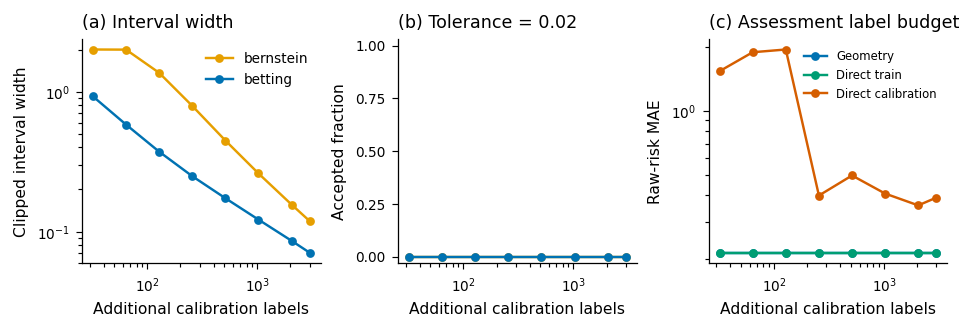

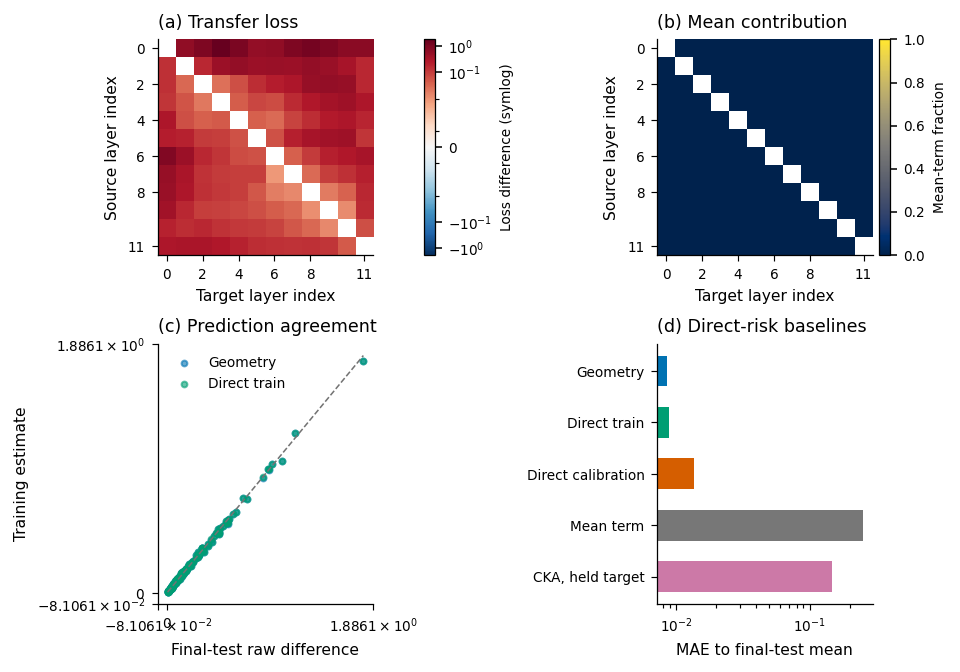

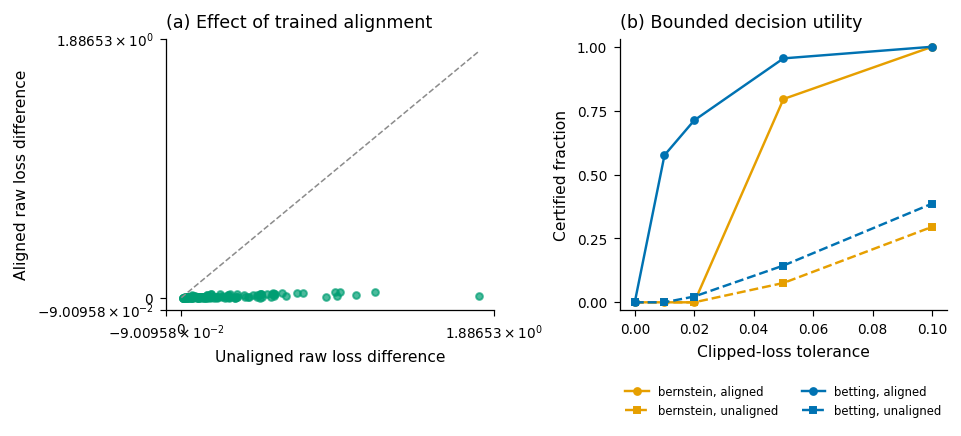

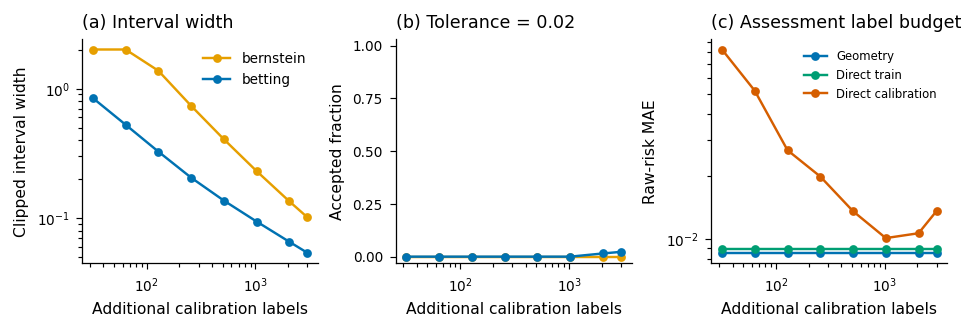

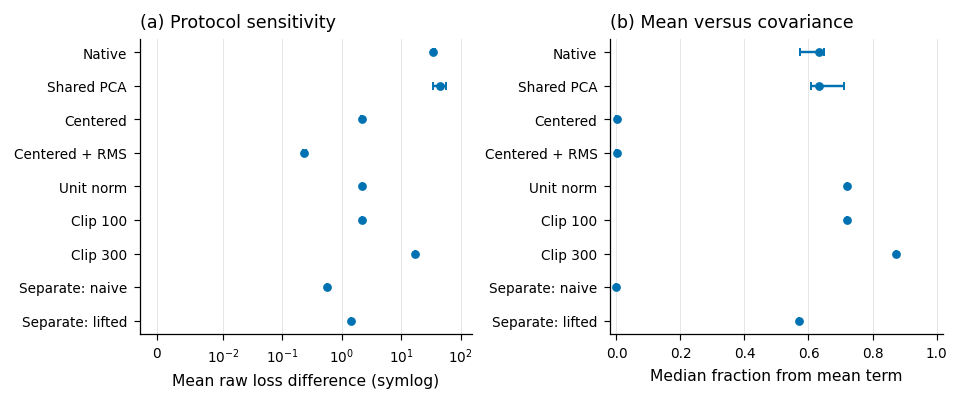

[COMPLETED] gpt2_medium_sst2: 17 protocol/split runs; raw block features; paper profile


README.md: 0.00B [00:00, ?B/s]

allocine/train-00000-of-00001.parquet:   0%|          | 0.00/60.0M [00:00<?, ?B/s]

allocine/validation-00000-of-00001.parqu(…):   0%|          | 0.00/7.58M [00:00<?, ?B/s]

allocine/test-00000-of-00001.parquet:   0%|          | 0.00/7.58M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


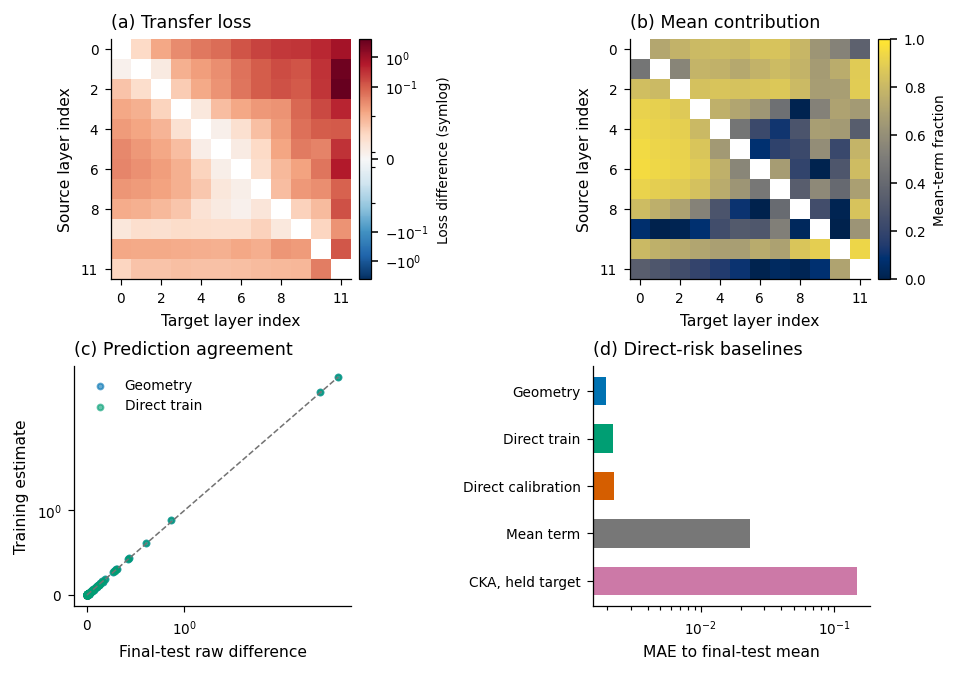

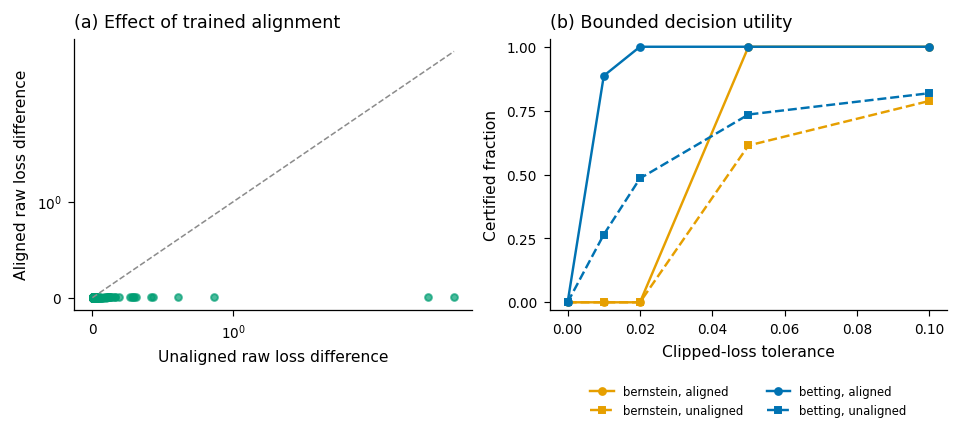

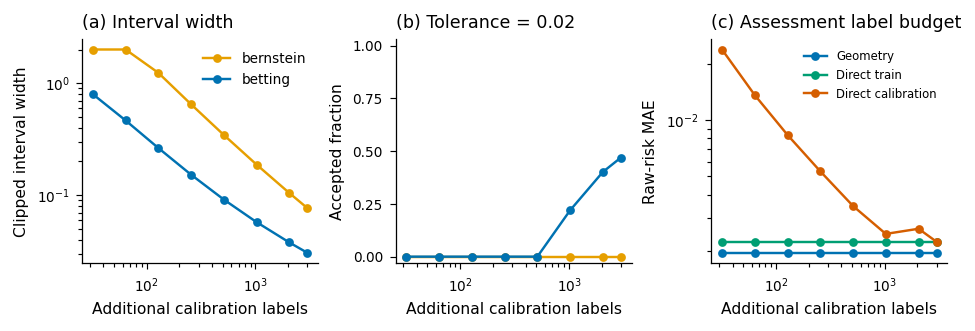

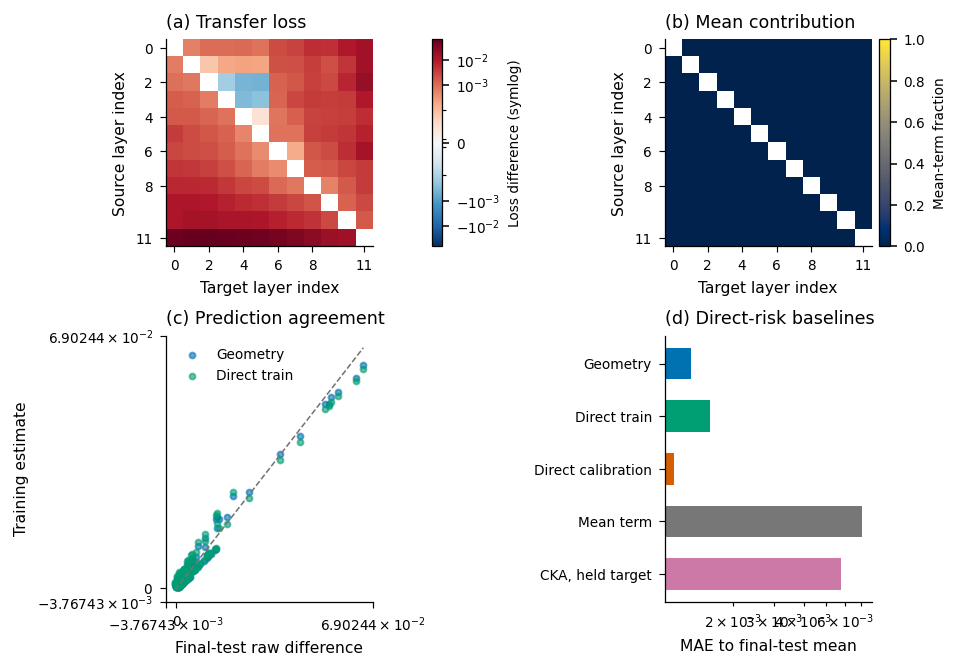

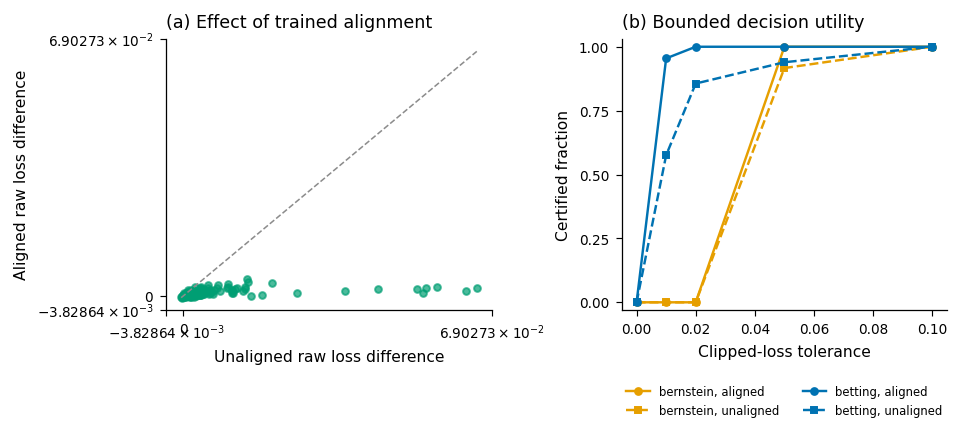

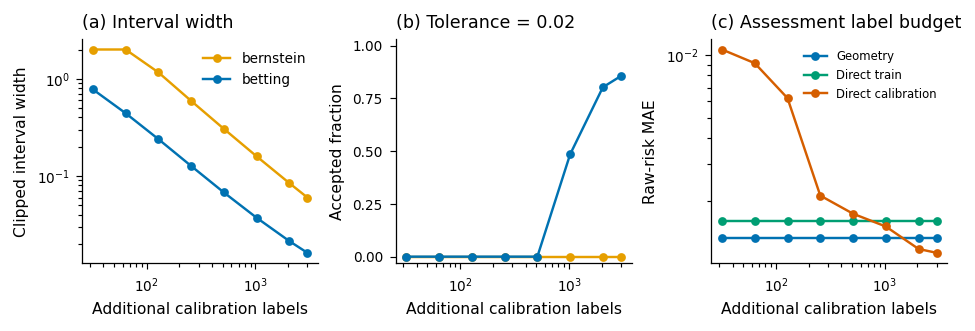

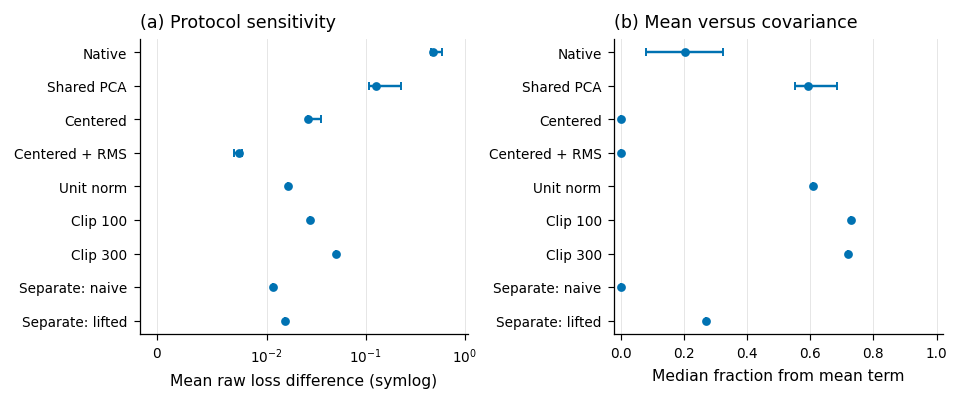

[COMPLETED] gpt2_allocine: 17 protocol/split runs; raw block features; paper profile


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

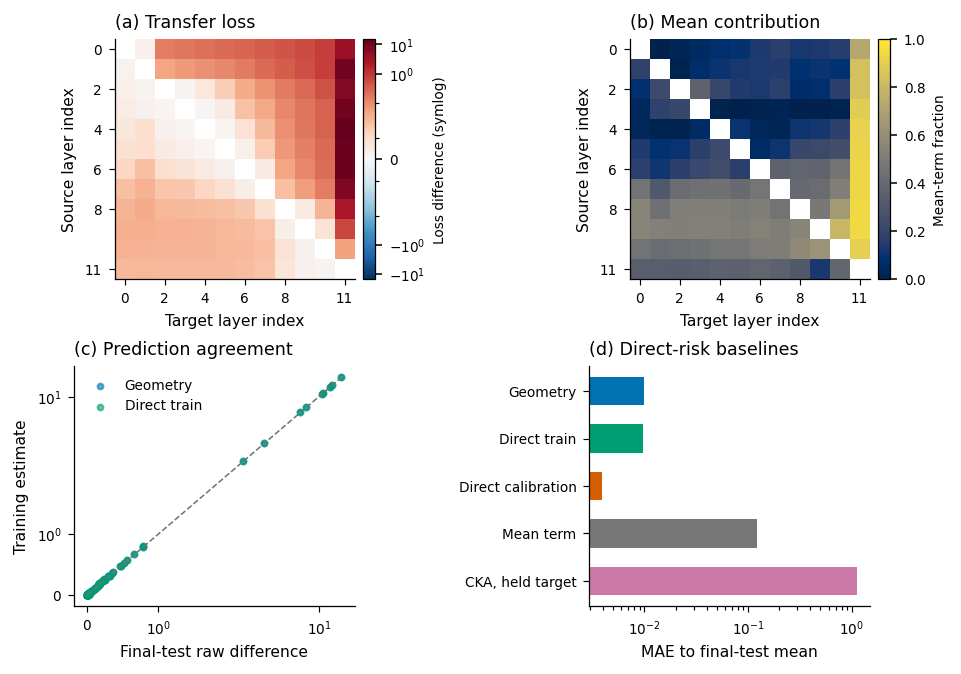

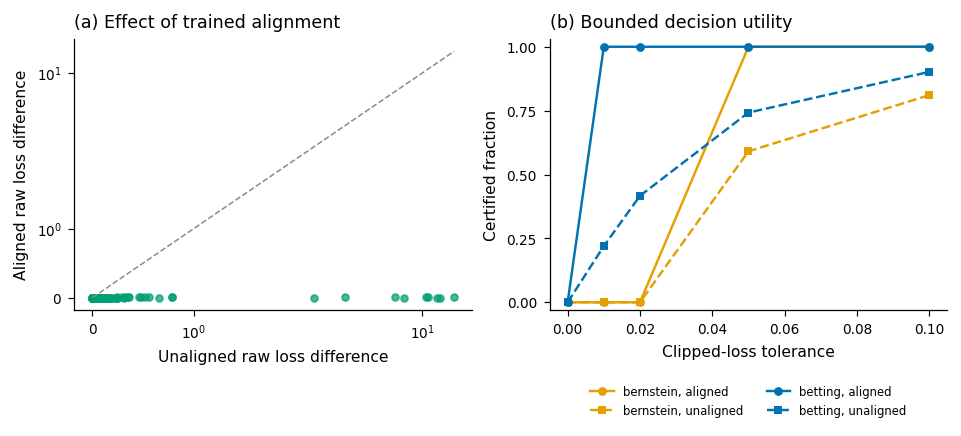

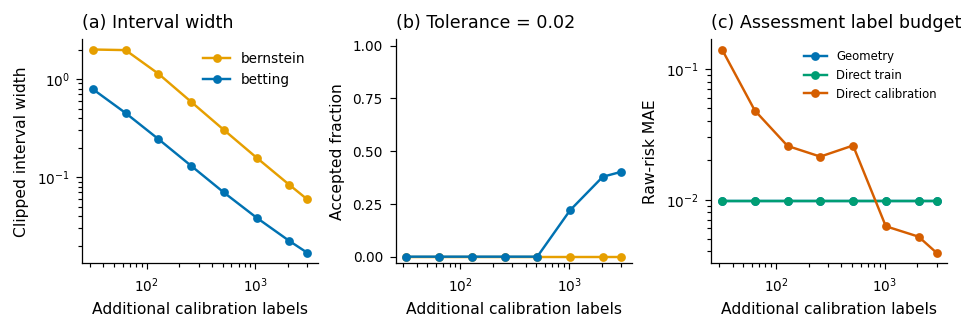

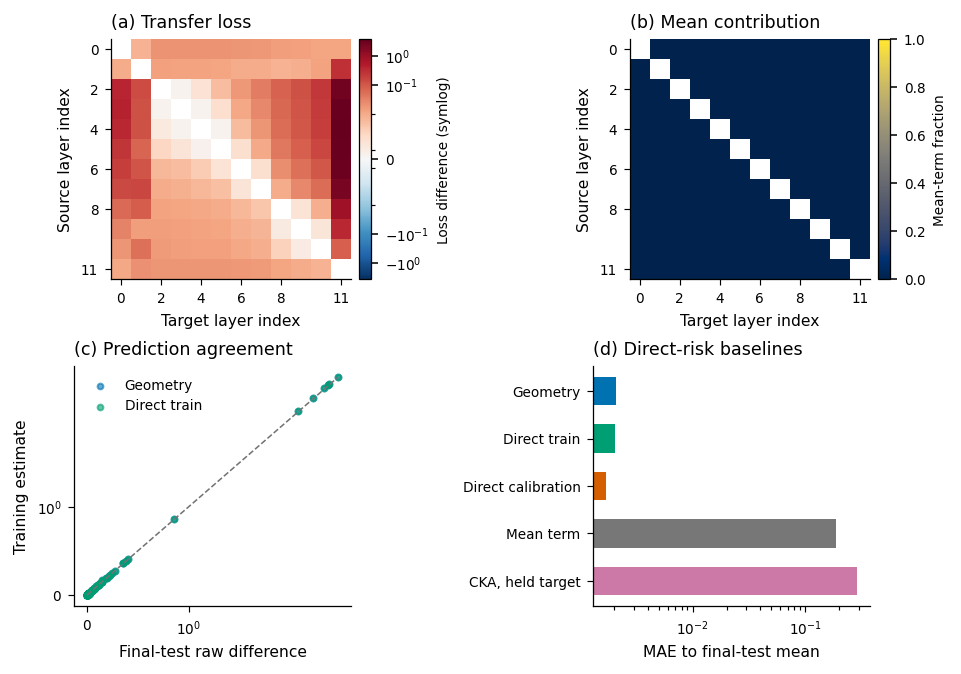

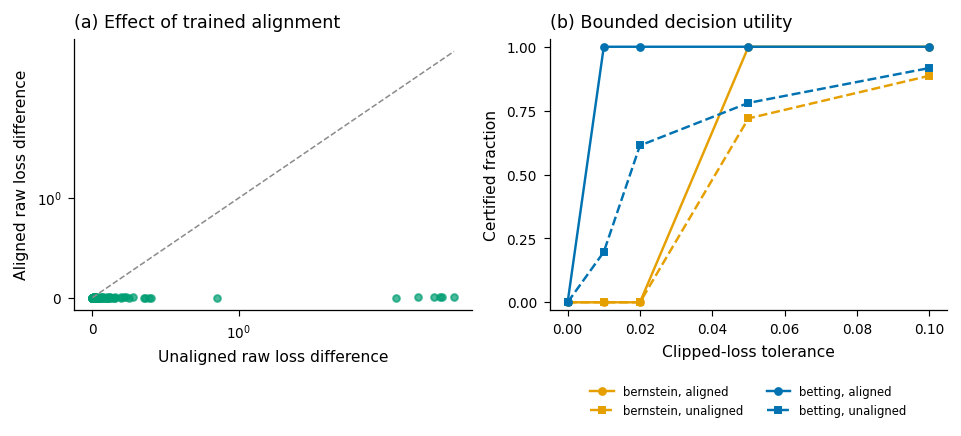

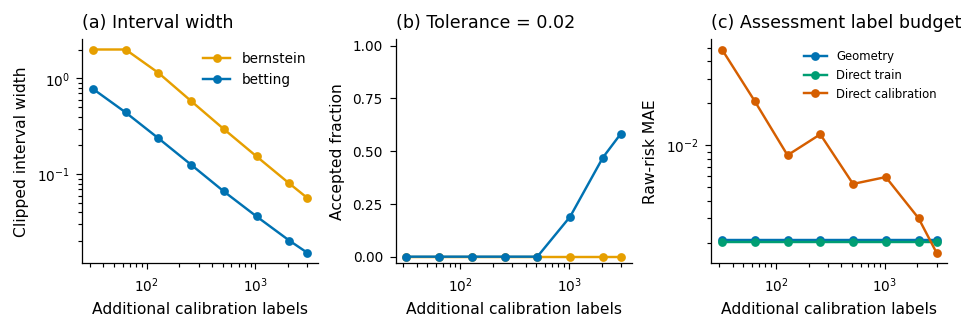

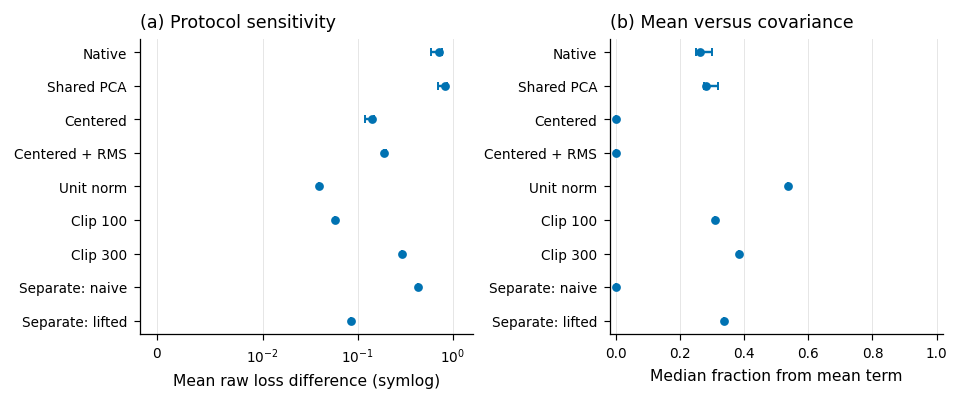

[COMPLETED] gpt2_nll: 17 protocol/split runs; raw block features; paper profile


job,protocol,repeat,n_pairs,mean_raw_difference,median_raw_difference,p90_raw_difference,mean_clipped_difference,mean_component_fraction,aligned_raw_mean,geometry_mae,training_direct_mae,calibration_direct_mae,bernstein_width,betting_width,betting_acceptance,mean_training_clip_fraction,mean_reference_test_mse
gpt2_sst2,native_raw,0,132,5.1322,0.510862,7.19917,0.200043,0.468862,0.00720915,0.102902,0.104535,0.131146,0.110412,0.0686011,0,0,0.137853
gpt2_sst2,shared_raw,0,132,11.3915,0.613549,19.2617,0.218424,0.776888,0.00518273,0.186818,0.187018,0.253106,0.11749,0.0754095,0,0,0.158473
gpt2_sst2,shared_center,0,132,1.99959,0.0674556,5.94294,0.0890688,0.000526055,0.005349,0.0655016,0.0669608,0.0721717,0.0856259,0.0446263,0.0227273,0,0.157556
gpt2_sst2,shared_rms,0,132,0.172954,0.112379,0.382487,0.0870255,0.000410352,0.00542831,0.00587005,0.00558169,0.00833072,0.086613,0.0456023,0.030303,0,0.157907
gpt2_sst2,shared_unit,0,132,1.89659,0.570083,5.667,0.205586,0.781933,0.0053046,0.0239232,0.0240193,0.043353,0.114633,0.0726613,0,0,0.15805
gpt2_sst2,shared_clip100,0,132,5.58543,0.724644,11.6587,0.227832,0.845165,0.00505876,0.0762628,0.0763859,0.137073,0.119396,0.0772667,0,0.442569,0.158023
gpt2_sst2,shared_clip300,0,132,10.3611,0.638581,15.0524,0.21877,0.788366,0.00517295,0.183013,0.18323,0.218747,0.117745,0.0756574,0,0.0812986,0.15852
gpt2_sst2,separate_naive,0,132,0.416394,0.192554,0.974363,0.17722,9.68406e-05,0.00643074,0.0125417,0.0122854,0.0135155,0.0999744,0.0585285,0,0,0.155228
gpt2_sst2,separate_lift,0,132,1.76936,0.180179,1.19691,0.154912,0.71358,0.00643074,0.0140803,0.0137941,0.0225629,0.0992584,0.0577662,0.030303,0,0.155228
gpt2_sst2,native_raw,1,132,6.18994,0.493201,6.92403,0.200025,0.477792,0.00727845,0.0880998,0.0892915,0.0773442,0.109305,0.0675347,0,0,0.138495


method,mae,median_absolute_error,p90_absolute_error,spearman,assessment_labels,probe_training_labels,n_pairs,job,protocol,repeat
training_geometry,0.102902,0.00931237,0.157229,0.999186,0,12000,132,gpt2_sst2,native_raw,0
direct_training,0.104535,0.0125645,0.160034,0.999202,0,12000,132,gpt2_sst2,native_raw,0
mean_only,1.18817,0.100247,3.52411,0.852395,0,12000,132,gpt2_sst2,native_raw,0
variance_only,3.87572,0.234314,4.21025,0.683981,0,12000,132,gpt2_sst2,native_raw,0
direct_calibration,0.131146,0.0137604,0.28589,0.999123,3000,12000,132,gpt2_sst2,native_raw,0
cka_common,6.77597,1.85565,13.199,0.53644,3000,12000,132,gpt2_sst2,native_raw,0
cka_held_target,8.44225,2.0516,16.1365,0.372766,3000,12000,132,gpt2_sst2,native_raw,0
cca_shared_common,6.01776,1.14905,10.0857,0.509789,3000,12000,132,gpt2_sst2,native_raw,0
cca_shared_held_target,7.86375,1.33853,16.3026,0.353231,3000,12000,132,gpt2_sst2,native_raw,0
procrustes_shared_common,6.01963,1.1413,9.93145,0.504202,3000,12000,132,gpt2_sst2,native_raw,0


method,action,tolerance,n_accepted,accepted_fraction,accepted_test_mean,test_fraction_above_tolerance,interpretation,job,protocol,repeat
bernstein,unaligned,0,0,0,NaN,NaN,"Noisy final-test audit, not population false-certification rate",gpt2_sst2,native_raw,0
bernstein,unaligned,0.01,0,0,NaN,NaN,"Noisy final-test audit, not population false-certification rate",gpt2_sst2,native_raw,0
bernstein,unaligned,0.02,0,0,NaN,NaN,"Noisy final-test audit, not population false-certification rate",gpt2_sst2,native_raw,0
bernstein,unaligned,0.05,0,0,NaN,NaN,"Noisy final-test audit, not population false-certification rate",gpt2_sst2,native_raw,0
bernstein,unaligned,0.1,6,0.0454545,0.0409805,0,"Noisy final-test audit, not population false-certification rate",gpt2_sst2,native_raw,0
bernstein,aligned,0,0,0,NaN,NaN,"Noisy final-test audit, not population false-certification rate",gpt2_sst2,native_raw,0
bernstein,aligned,0.01,0,0,NaN,NaN,"Noisy final-test audit, not population false-certification rate",gpt2_sst2,native_raw,0
bernstein,aligned,0.02,0,0,NaN,NaN,"Noisy final-test audit, not population false-certification rate",gpt2_sst2,native_raw,0
bernstein,aligned,0.05,116,0.878788,0.00683798,0,"Noisy final-test audit, not population false-certification rate",gpt2_sst2,native_raw,0
bernstein,aligned,0.1,132,1,0.00918878,0,"Noisy final-test audit, not population false-certification rate",gpt2_sst2,native_raw,0


n_cal,method,action,mean_width,accepted_fraction,accepted_test_mean,geometry_raw_mae,direct_train_raw_mae,direct_cal_raw_mae,job,protocol,repeat
32,bernstein,unaligned,2,0,NaN,0.186818,0.187018,0.651507,gpt2_sst2,shared_raw,0
32,bernstein,aligned,2,0,NaN,0.186818,0.187018,0.651507,gpt2_sst2,shared_raw,0
32,betting,unaligned,0.945446,0,NaN,0.186818,0.187018,0.651507,gpt2_sst2,shared_raw,0
32,betting,aligned,0.776102,0,NaN,0.186818,0.187018,0.651507,gpt2_sst2,shared_raw,0
64,bernstein,unaligned,2,0,NaN,0.186818,0.187018,0.614054,gpt2_sst2,shared_raw,0
64,bernstein,aligned,2,0,NaN,0.186818,0.187018,0.614054,gpt2_sst2,shared_raw,0
64,betting,unaligned,0.625926,0,NaN,0.186818,0.187018,0.614054,gpt2_sst2,shared_raw,0
64,betting,aligned,0.439151,0,NaN,0.186818,0.187018,0.614054,gpt2_sst2,shared_raw,0
128,bernstein,unaligned,1.4605,0,NaN,0.186818,0.187018,0.517469,gpt2_sst2,shared_raw,0
128,bernstein,aligned,1.14773,0,NaN,0.186818,0.187018,0.517469,gpt2_sst2,shared_raw,0


layer,mean_norm,rms_norm,clip_fraction,training_scale,reference_probe_norm,source_probe_norm,reference_intercept,ridge_lambda,ridge_selected_scale,effective_df,reference_train_mse,reference_test_mse,reference_test_accuracy,job,protocol,repeat
0,54.0687,54.964,0,1,2.0661,2.0661,1.85833,0.00127102,0.01,467.883,0.148397,0.154816,0.794333,gpt2_sst2,native_raw,0
1,59.3131,60.2783,0,1,1.74616,1.74616,1.11504,0.00150302,0.01,552.971,0.14076,0.148273,0.803,gpt2_sst2,native_raw,0
2,66.5197,68.1914,0,1,1.15259,1.15259,1.49497,0.00293219,0.01,594.208,0.142796,0.153018,0.784,gpt2_sst2,native_raw,0
3,70.8707,73.5935,0,1,0.886397,0.886397,1.12514,0.00512169,0.01,620.288,0.138319,0.15099,0.792333,gpt2_sst2,native_raw,0
4,73.8669,77.8404,0,1,0.664517,0.664517,0.831594,0.00784917,0.01,633.564,0.132772,0.146879,0.801,gpt2_sst2,native_raw,0
5,81.2239,85.9846,0,1,0.565205,0.565205,1.02131,0.0103649,0.01,646.006,0.130677,0.144007,0.801,gpt2_sst2,native_raw,0
6,93.6652,98.6375,0,1,0.469336,0.469336,0.137991,0.0124503,0.01,650.777,0.117671,0.129627,0.829,gpt2_sst2,native_raw,0
7,106.58,112.017,0,1,0.436838,0.436838,-0.176331,0.0154757,0.01,645.882,0.115008,0.126227,0.827667,gpt2_sst2,native_raw,0
8,130.607,136.417,0,1,0.372528,0.372528,0.205825,0.0202034,0.01,650.67,0.114388,0.124922,0.834667,gpt2_sst2,native_raw,0
9,156.216,162.204,0,1,0.344291,0.344291,-0.064287,0.0248257,0.01,654.777,0.114472,0.123089,0.836333,gpt2_sst2,native_raw,0


In [18]:
REAL_SUMMARY=[];REAL_PERFORMANCE=[];REAL_DECISIONS=[];REAL_PAIR_FRAMES=[];REAL_BUDGETS=[];REAL_DIAGNOSTICS=[];EXECUTION_LEDGER=[]
missing=[m for m in ["torch","transformers","datasets","huggingface_hub"] if importlib.util.find_spec(m) is None]
def register_result(job,spec,rep,result,sizes,family_multiplier):
    name=spec["name"]
    REAL_SUMMARY.append(summarize_result(result,job,name,rep))
    REAL_PERFORMANCE.append(result["performance"].assign(job=job,protocol=name,repeat=rep))
    REAL_DECISIONS.append(result["decisions"].assign(job=job,protocol=name,repeat=rep))
    REAL_PAIR_FRAMES.append(result["frame"].assign(job=job,protocol=name,repeat=rep))
    REAL_DIAGNOSTICS.append(result["diagnostics"].assign(job=job,protocol=name,repeat=rep))
    EXECUTION_LEDGER.append(dict(job=job,protocol=name,repeat=rep,n_train=sizes[0],n_cal=sizes[1],n_test=sizes[2],
        family_multiplier=family_multiplier,interval_methods=2,actions=2,alpha=ALPHA,
        checkpoint=result.get("checkpoint"),cache_hit=result.get("cache_hit",False),status="COMPLETED"))

for job,model,dataset,nll in REAL_JOBS:
    if JOB_FILTER is not None and job not in JOB_FILTER:status(job,"NOT_SELECTED","Excluded by JOB_FILTER");continue
    if RUN_REAL=="no":status(job,"DISABLED","RUN_REAL=no");continue
    if job not in FEATURE_BUNDLES and missing:
        status(job,"BLOCKED","Need native feature bundle or dependencies: "+", ".join(missing));continue
    try:
        bundle=acquire_job(job,model,dataset,nll);sizes=real_sizes(dataset);specs=protocol_registry(CFG.pca_k)
        count=0
        for rep in range(CFG.repeats):
            active=specs if rep==0 else specs[:4]
            for spec in active:
                result=cached_experiment(bundle,sizes,MASTER_SEED+rep,spec,len(specs))
                register_result(job,spec,rep,result,sizes,len(specs));count+=1
                if rep==0 and spec["name"] in {"shared_raw","shared_rms"}:
                    plot_pair_diagnostics(result,f"real_{job}_{spec['name']}_diagnostics",f"{job}, {spec['name']}, v3 {RUN_MODE} profile, split {rep}")
                    plot_alignment(result,f"real_{job}_{spec['name']}_alignment",f"{job}, {spec['name']}")
                    budget=label_budget_study(result,.5,len(specs)).assign(job=job,protocol=spec["name"],repeat=rep)
                    REAL_BUDGETS.append(budget);plot_budgets(budget,f"real_{job}_{spec['name']}_budget",f"{job}, {spec['name']}")
                del result
        plot_control_summary([r for r in REAL_SUMMARY if r["job"]==job],f"real_{job}_protocol_controls",f"{job}: primary/control protocols")
        status(job,"COMPLETED",f"{count} protocol/split runs; raw block features; {RUN_MODE} profile")
        del bundle
    except Exception as exc:
        status(job,"FAILED",type(exc).__name__+": "+str(exc))
        write_json(RUN_DIR/(job+"_failure.json"),{"error_type":type(exc).__name__,"message":str(exc)})

if REAL_SUMMARY:show_table("real_protocol_summary",REAL_SUMMARY)
if REAL_PERFORMANCE:show_table("real_all_baselines",pd.concat(REAL_PERFORMANCE,ignore_index=True))
if REAL_DECISIONS:show_table("real_all_decisions",pd.concat(REAL_DECISIONS,ignore_index=True))
if REAL_PAIR_FRAMES:show_table("real_all_pair_results",pd.concat(REAL_PAIR_FRAMES,ignore_index=True),display_all=False)
if REAL_BUDGETS:show_table("real_all_label_budgets",pd.concat(REAL_BUDGETS,ignore_index=True))
if REAL_DIAGNOSTICS:show_table("real_probe_and_feature_diagnostics",pd.concat(REAL_DIAGNOSTICS,ignore_index=True))


## 13. Dimension, regularization, sample-size, and last-layer controls
The following preregistered sensitivity grid uses GPT-2 and BERT on SST-2. Shared-PCA dimensions and fixed
ridge strengths are crossed; GCV is the primary training-only selector. Training-size sweeps keep
calibration/test IDs fixed. Removing the final block tests dependence on that layer even though primary
v3 extraction already avoids the API's final-normalization mismatch. Each sensitivity run is a separate
conditional interval family; its test outcomes do not select the primary method.


job,protocol,repeat,n_pairs,mean_raw_difference,median_raw_difference,p90_raw_difference,mean_clipped_difference,mean_component_fraction,aligned_raw_mean,geometry_mae,training_direct_mae,calibration_direct_mae,bernstein_width,betting_width,betting_acceptance,mean_training_clip_fraction,mean_reference_test_mse,study,k,ridge,n_train
gpt2_sst2,sensitivity_k32_ridge0.0001,0,132,0.149424,0.108922,0.334461,0.0768244,0.000147879,0.00548786,0.00630561,0.00630785,0.00861514,0.0758825,0.041497,0.0757576,0,0.191605,dimension_ridge,32,0.0001,12000
gpt2_sst2,sensitivity_k32_ridge0.001,0,132,0.139034,0.104872,0.318338,0.0741253,0.000151818,0.00555986,0.00610049,0.00611535,0.00827778,0.0750593,0.0407059,0.0833333,0,0.191622,dimension_ridge,32,0.001,12000
gpt2_sst2,sensitivity_k32_ridge0.01,0,132,0.0832123,0.0706457,0.157943,0.0549853,0.000150254,0.00590614,0.00507016,0.00491637,0.00635363,0.0686681,0.0345587,0.0984848,0,0.192152,dimension_ridge,32,0.01,12000
gpt2_sst2,sensitivity_k32_ridge0.1,0,132,0.0173013,0.0152696,0.0330324,0.0166331,0.000137195,0.00534698,0.00435274,0.00274295,0.00355389,0.05101,0.0178159,0.416667,0,0.199466,dimension_ridge,32,0.1,12000
gpt2_sst2,sensitivity_k64_ridge0.0001,0,132,0.182537,0.152081,0.377161,0.0908287,0.000373615,0.00450955,0.00602262,0.00600635,0.0087515,0.0787496,0.0442681,0.0378788,0,0.168458,dimension_ridge,64,0.0001,12000
gpt2_sst2,sensitivity_k64_ridge0.001,0,132,0.168463,0.14239,0.338833,0.0869696,0.000384534,0.00464727,0.00590309,0.00575812,0.00831482,0.0776221,0.0431818,0.0454545,0,0.168408,dimension_ridge,64,0.001,12000
gpt2_sst2,sensitivity_k64_ridge0.01,0,132,0.0964399,0.0824982,0.199121,0.0616025,0.000469301,0.00541074,0.00497264,0.00414061,0.00585788,0.0694825,0.0353418,0.0833333,0,0.168506,dimension_ridge,64,0.01,12000
gpt2_sst2,sensitivity_k64_ridge0.1,0,132,0.0203205,0.0171099,0.0399053,0.0188816,0.000524519,0.00644784,0.00392791,0.00182621,0.00239189,0.0507194,0.0175392,0.409091,0,0.174514,dimension_ridge,64,0.1,12000
gpt2_sst2,sensitivity_k128_ridge0.0001,0,132,0.205267,0.149302,0.435242,0.0981977,0.000418519,0.00515283,0.00639949,0.00638123,0.00960273,0.0788536,0.0443712,0.030303,0,0.158043,dimension_ridge,128,0.0001,12000
gpt2_sst2,sensitivity_k128_ridge0.001,0,132,0.187635,0.142009,0.382248,0.0946576,0.000417845,0.00528292,0.00632291,0.00612437,0.00911568,0.0778669,0.0434213,0.030303,0,0.157978,dimension_ridge,128,0.001,12000


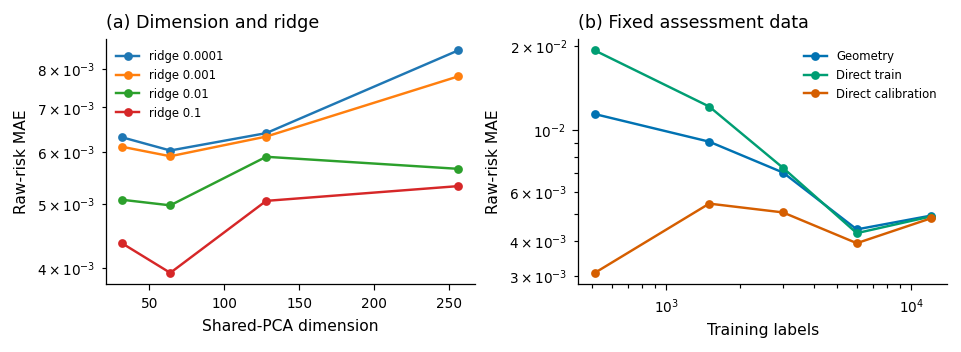

[COMPLETED] gpt2_sst2_sensitivity: 22 sensitivity settings


job,protocol,repeat,n_pairs,mean_raw_difference,median_raw_difference,p90_raw_difference,mean_clipped_difference,mean_component_fraction,aligned_raw_mean,geometry_mae,training_direct_mae,calibration_direct_mae,bernstein_width,betting_width,betting_acceptance,mean_training_clip_fraction,mean_reference_test_mse,study,k,ridge,n_train
bert_sst2,sensitivity_k32_ridge0.0001,0,132,0.381341,0.205226,1.03818,0.128992,0.000261128,0.0164845,0.00888667,0.00885999,0.0189285,0.0864884,0.0517198,0.0681818,0,0.175096,dimension_ridge,32,0.0001,12000
bert_sst2,sensitivity_k32_ridge0.001,0,132,0.338013,0.201274,0.8757,0.125825,0.000251277,0.0167676,0.00818644,0.00792026,0.0166383,0.0857351,0.0509953,0.0681818,0,0.17511,dimension_ridge,32,0.001,12000
bert_sst2,sensitivity_k32_ridge0.01,0,132,0.177454,0.135973,0.350717,0.103359,0.000191126,0.0179214,0.0060741,0.00441318,0.00907496,0.0799191,0.0454073,0.0833333,0,0.176063,dimension_ridge,32,0.01,12000
bert_sst2,sensitivity_k32_ridge0.1,0,132,0.0471564,0.0420473,0.0881893,0.0454263,0.000175001,0.0179714,0.00865967,0.00198344,0.0031266,0.0593981,0.0257204,0.159091,0,0.183602,dimension_ridge,32,0.1,12000
bert_sst2,sensitivity_k64_ridge0.0001,0,132,0.402113,0.139485,1.02388,0.117014,0.000220802,0.0137076,0.0104643,0.0104411,0.015582,0.0811546,0.0465998,0.0681818,0,0.157091,dimension_ridge,64,0.0001,12000
bert_sst2,sensitivity_k64_ridge0.001,0,132,0.335691,0.138065,0.780866,0.114142,0.000213434,0.0139964,0.00916435,0.00886619,0.0138639,0.0804218,0.0458946,0.0681818,0,0.157079,dimension_ridge,64,0.001,12000
bert_sst2,sensitivity_k64_ridge0.01,0,132,0.162808,0.110668,0.376045,0.0956372,0.000192849,0.0152843,0.00711342,0.00509752,0.00906503,0.0753165,0.040985,0.0984848,0,0.157767,dimension_ridge,64,0.01,12000
bert_sst2,sensitivity_k64_ridge0.1,0,132,0.0514909,0.0457693,0.0972787,0.050672,0.000162971,0.0165867,0.00983095,0.00225951,0.00419838,0.0587314,0.0250724,0.19697,0,0.16437,dimension_ridge,64,0.1,12000
bert_sst2,sensitivity_k128_ridge0.0001,0,132,0.419543,0.156938,1.02814,0.125385,0.000160695,0.0108486,0.0103483,0.0103486,0.0145143,0.0825038,0.0478922,0.0454545,0,0.147428,dimension_ridge,128,0.0001,12000
bert_sst2,sensitivity_k128_ridge0.001,0,132,0.356514,0.154117,0.938971,0.123073,0.000166291,0.0111189,0.00901917,0.00899516,0.0119996,0.0819064,0.0473175,0.0454545,0,0.147381,dimension_ridge,128,0.001,12000


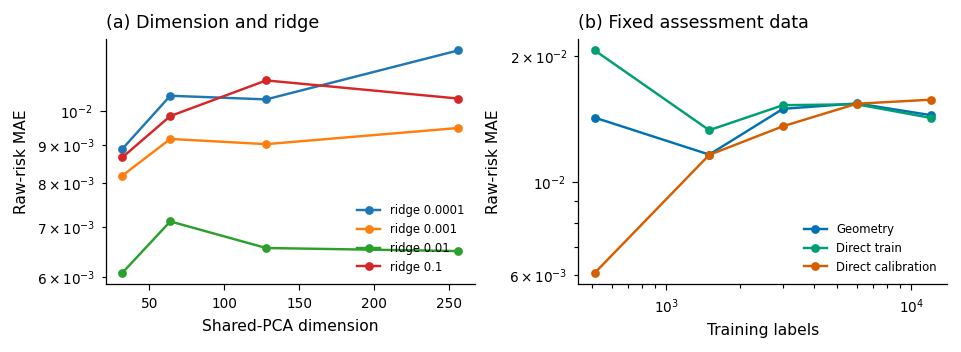

[COMPLETED] bert_sst2_sensitivity: 22 sensitivity settings


In [19]:
SENSITIVITY_ROWS=[]
SENSITIVITY_JOBS=[("gpt2_sst2","gpt2"),("bert_sst2","bert")]
for job,model in SENSITIVITY_JOBS:
    task=job+"_sensitivity"
    if not ENABLE_EXTENSIONS:status(task,"DISABLED","ENABLE_EXTENSIONS=False");continue
    if JOB_FILTER is not None and job not in JOB_FILTER:status(task,"NOT_SELECTED","Base job not selected");continue
    if RUN_REAL=="no" or (missing and job not in FEATURE_BUNDLES):status(task,"BLOCKED","Real feature access unavailable");continue
    try:
        bundle=acquire_job(job,model,"sst2");sizes=real_sizes("sst2");X,y,ids=bundle["X"],bundle["y"],bundle["ids"]
        dims=[v for v in ([32,64,128,256] if RUN_MODE=="paper" else [8,16,32]) if v<=min(sizes[0]-1,X.shape[2])]
        for k,ridge in itertools.product(dims,[1e-4,1e-3,1e-2,.1]):
            spec=dict(name=f"sensitivity_k{k}_ridge{ridge}",mode="shared_pca",normalization="rms",cap=None,k=k,ridge=ridge)
            r=cached_experiment(bundle,sizes,MASTER_SEED,spec,1)
            row=summarize_result(r,job,spec["name"],0);row.update(study="dimension_ridge",k=k,ridge=ridge,n_train=sizes[0])
            SENSITIVITY_ROWS.append(row);TABLES[job+"__"+spec["name"]]=r["frame"]
        split=split_indices(ids,*sizes,MASTER_SEED+99);ci,vi=split["cal"],split["test"]
        for n in [v for v in [512,1500,3000,6000,12000] if v<=sizes[0]]:
            ti=split["train"][:n];spec=dict(name=f"n_sweep_{n}",mode="shared_pca",normalization="rms",cap=None,k=min(CFG.pca_k,n-1),ridge="gcv")
            fit=fit_pipeline(X[ti],y[ti],spec,MASTER_SEED)
            r=analyze_fixed_fit(fit,X[ti],y[ti],X[ci],y[ci],X[vi],y[vi],.5,compute_metrics=False)
            row=summarize_result(r,job,spec["name"],0);row.update(study="training_size",k=spec["k"],ridge="gcv",n_train=n)
            SENSITIVITY_ROWS.append(row);r["split"]={"train":ti,"cal":ci,"test":vi}
            save_experiment(RUN_DIR/f"{job}_n{n}",r,ids,{"job":job,"spec":spec,"fixed_cal_test":True})
        spec=dict(name="exclude_final_block",mode="shared_pca",normalization="rms",cap=None,k=CFG.pca_k,ridge="gcv")
        r=run_experiment(X[:,:-1,:],y,ids,sizes,MASTER_SEED,spec,.5)
        row=summarize_result(r,job,spec["name"],0);row.update(study="final_block",k=CFG.pca_k,ridge="gcv",n_train=sizes[0])
        SENSITIVITY_ROWS.append(row);save_experiment(RUN_DIR/f"{job}_exclude_final",r,ids,{"job":job,"spec":spec})
        sub=pd.DataFrame([z for z in SENSITIVITY_ROWS if z["job"]==job]);show_table(task,sub)
        fig,axs=paper_figure(ncols=2,height=2.4,double=True)
        gr=sub[sub.study=="dimension_ridge"]
        for alpha,g in gr.groupby("ridge"):
            axs[0,0].plot(g.k,g.geometry_mae,"o-",label=f"ridge {alpha:g}")
        ns=sub[sub.study=="training_size"]
        for col,label,c in [("geometry_mae","Geometry",COLORS["geometry"]),("training_direct_mae","Direct train",COLORS["direct_train"]),("calibration_direct_mae","Direct calibration",COLORS["direct_cal"])]:
            axs[0,1].loglog(ns.n_train,np.maximum(ns[col],1e-12),"o-",label=label,color=c)
        axs[0,0].set(yscale="log",xlabel="Shared-PCA dimension",ylabel="Raw-risk MAE");axs[0,1].set(xlabel="Training labels",ylabel="Raw-risk MAE")
        axs[0,0].legend(fontsize=6);axs[0,1].legend(fontsize=6);panel(axs[0,0],"a","Dimension and ridge");panel(axs[0,1],"b","Fixed assessment data")
        export_figure(fig,f"real_{job}_sensitivity",f"{job}, descriptive sensitivity checks. Sample-size sweep uses the same calibration/test IDs. No independent-seed p-values or universal rate are inferred.",sub)
        status(task,"COMPLETED",f"{len(sub)} sensitivity settings")
        del bundle,X
    except Exception as exc:status(task,"FAILED",type(exc).__name__+": "+str(exc))


## 14. Actual domain and language transfer
SST-2-trained heads are applied to IMDB and French Allociné. Source preprocessing and PCA maps are frozen.
Target references use target training labels, and assessment uses additional target calibration labels;
these experiments are not target-label-free adaptation. All $L^2$ directions, including same-layer
transfer, are evaluated. Because source and target texts are unpaired, similarity scores are computed
between layers **within the target domain**, not by arbitrarily matching cross-domain rows.


source,target,cka,cca_shared,procrustes_shared,probe_cosine,metric_rank,metric_examples,full_dim_cca_saturation_possible,train_raw,train_geometry,residual_correction,cal_raw,test_raw,cal_clipped,test_clipped,train_mean_term,train_variance_term,test_mean_term,test_variance_term,test_geometry,mean_fraction,aligned_cal_raw,aligned_test_raw,aligned_test_clipped,alignment_raw_reduction,bernstein_lo,bernstein_hi,bernstein_aligned_lo,bernstein_aligned_hi,betting_lo,betting_hi,betting_aligned_lo,betting_aligned_hi,prediction__training_geometry,prediction__direct_training,prediction__mean_only,prediction__variance_only,prediction__direct_calibration,prediction__cka_common,prediction__cka_held_target,prediction__cca_shared_common,prediction__cca_shared_held_target,prediction__procrustes_shared_common,prediction__procrustes_shared_held_target,prediction__probe_cosine_common,prediction__probe_cosine_held_target
0,0,1,1,1,0.999751,6,1000,False,0.122369,0.122366,2.73932e-06,0.124541,0.122676,0.100976,0.0975352,0.122302,6.37249e-05,0.122181,6.06599e-05,0.122242,0.999504,0.124541,0.12267,0.0976051,5.32445e-06,0.0368233,0.165129,0.0368873,0.16521,0.0859347,0.11479,0.0860025,0.114866,0.122366,0.122369,0.122302,6.37249e-05,0.124541,0.0501707,0.0315782,0.0501707,0.0315782,0.0501707,0.0315782,0.0316019,0.0209381
0,1,0.972176,0.971798,0.985796,0.992782,6,1000,False,0.620007,0.620082,-7.50624e-05,0.628326,0.623529,0.255293,0.245242,0.601737,0.0183448,0.608131,0.0172159,0.625347,0.97247,0.124128,0.121812,0.0981021,0.501717,0.169326,0.341259,0.0367343,0.165994,0.223784,0.288349,0.0860026,0.115331,0.620082,0.620007,0.601737,0.0183448,0.628326,0.175688,0.0636921,0.175688,0.0636921,0.175688,0.0636921,0.198557,0.136692
0,2,0.966355,0.965921,0.982795,0.975602,6,1000,False,1.52621,1.52636,-0.000147174,1.52625,1.51748,0.311698,0.296924,1.45203,0.0743284,1.46349,0.0701466,1.53364,0.954261,0.120959,0.118106,0.0950507,1.39937,0.215734,0.407662,0.0347969,0.164988,0.270454,0.353946,0.084253,0.114016,1.52636,1.52621,1.45203,0.0743284,1.52625,0.808858,0.326331,0.808858,0.326331,0.808858,0.326331,0.595231,0.355799
0,3,0.958888,0.958076,0.978736,0.949319,6,1000,False,2.83046,2.83067,-0.000212107,2.86131,2.81621,0.324903,0.314976,2.65782,0.172853,2.67145,0.161932,2.83338,0.942848,0.122301,0.119203,0.0965326,2.69701,0.226091,0.423715,0.0343792,0.166469,0.28089,0.369767,0.084424,0.115264,2.83067,2.83046,2.65782,0.172853,2.86131,1.1316,0.597787,1.1316,0.597787,1.1316,0.597787,1.48987,0.750832
0,4,0.946488,0.945311,0.972017,0.911221,6,1000,False,4.53754,4.5378,-0.000265398,4.59064,4.54069,0.324955,0.320272,4.21953,0.318276,4.25775,0.293869,4.55162,0.935437,0.12024,0.121305,0.0986867,4.41939,0.22532,0.424589,0.0329193,0.167535,0.280155,0.3706,0.0834312,0.115674,4.5378,4.53754,4.21953,0.318276,4.59064,2.4141,0.848299,2.4141,0.848299,2.4141,0.848299,4.59064,1.54943
1,0,0.972176,0.971798,0.985796,0.996963,6,1000,False,0.0128945,0.0128353,5.91853e-05,0.0133088,0.0128515,0.0153643,0.0153604,0.00291402,0.00992131,0.00337281,0.00925772,0.0126305,0.267036,0.0594923,0.0580441,0.0496176,-0.0451926,-0.0400638,0.0707924,-0.0080984,0.111077,0.00338878,0.0269946,0.0384194,0.0637076,0.0128353,0.0128945,0.00291402,0.00992131,0.0133088,0.175688,0.208164,0.175688,0.208164,0.175688,0.208164,0.0316019,0.0209381
1,1,1,1,1,0.999651,6,1000,False,0.0579898,0.0579872,2.59749e-06,0.0592133,0.0575538,0.0502758,0.04835,0.0579127,7.45271e-05,0.0578982,7.80462e-05,0.0579762,0.998654,0.0592153,0.0575517,0.0483923,2.07493e-06,-0.00951378,0.110065,-0.00947633,0.110116,0.0371021,0.0625099,0.0371435,0.0625552,0.0579872,0.0579898,0.0579127,7.45271e-05,0.0592133,0.0501707,0.0479101,0.0501707,0.0479101,0.0501707,0.0479101,0.0316019,0.0309826
1,2,0.97185,0.971555,0.985673,0.99232,6,1000,False,0.2984,0.298451,-5.05402e-05,0.296132,0.292902,0.169346,0.160571,0.289195,0.00925613,0.291241,0.00876321,0.300004,0.97079,0.0571094,0.0550777,0.0466119,0.237825,0.0953434,0.243349,-0.010812,0.109775,0.148193,0.191046,0.036

[COMPLETED] domain_pipeline_validation: Frozen source maps and separate target references exercised


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


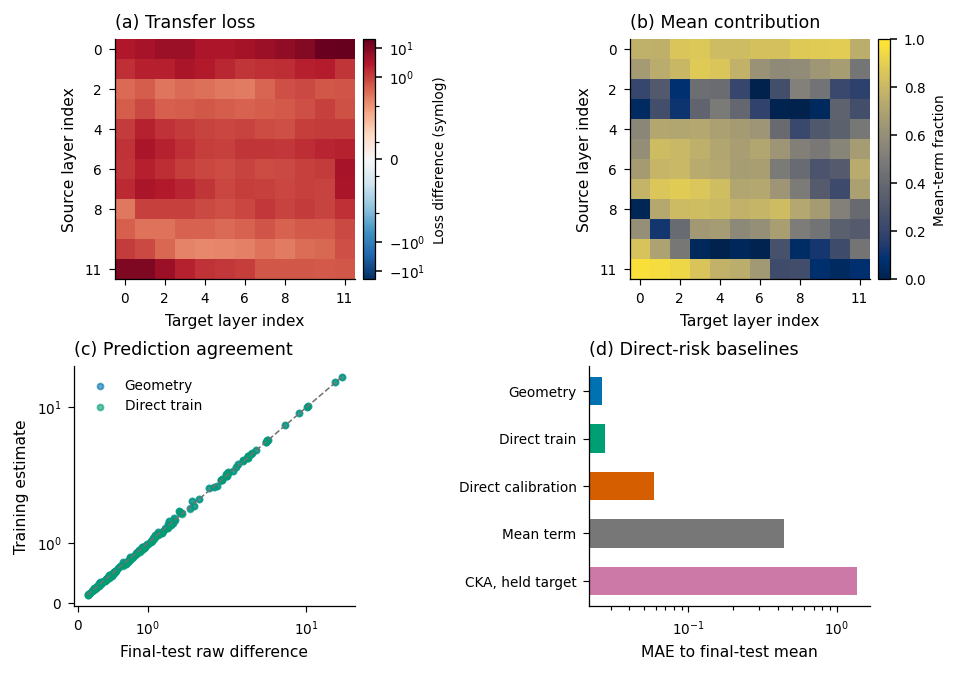

[COMPLETED] sst2_to_imdb: 9 source-to-target runs; target-label use explicit


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


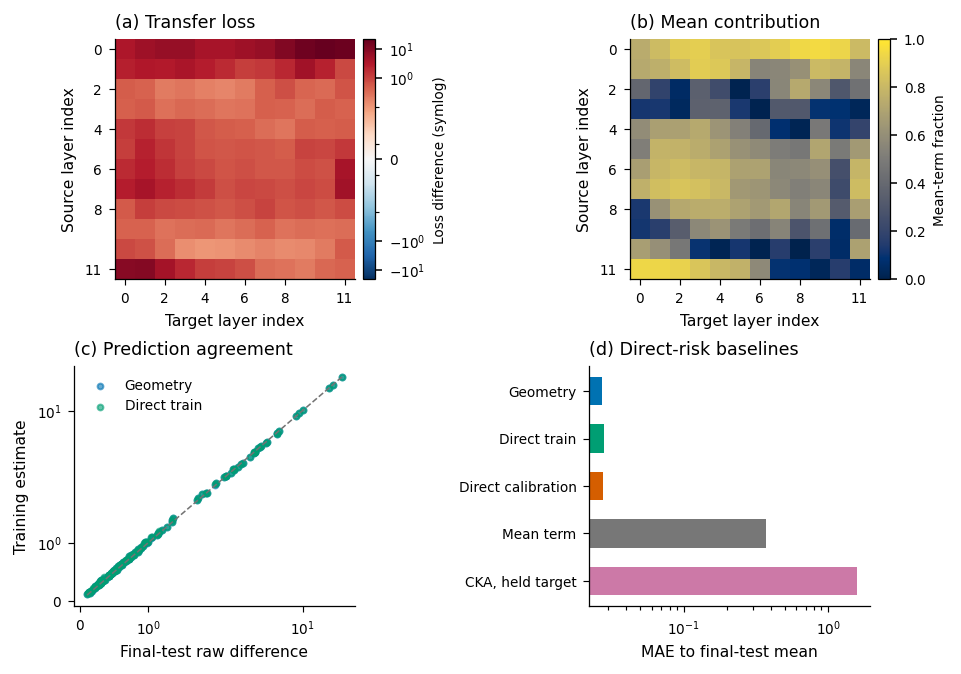

[COMPLETED] sst2_to_allocine: 9 source-to-target runs; target-label use explicit


job,protocol,repeat,n_pairs,mean_raw_difference,median_raw_difference,p90_raw_difference,mean_clipped_difference,mean_component_fraction,aligned_raw_mean,geometry_mae,training_direct_mae,calibration_direct_mae,bernstein_width,betting_width,betting_acceptance,mean_training_clip_fraction,mean_reference_test_mse
sst2_to_imdb,native_raw,0,144,14.9337,1.68411,30.6501,0.204847,0.145758,2.0097,0.319111,0.319928,0.346909,0.117532,0.078288,0,0,0.207969
sst2_to_imdb,shared_raw,0,144,17.8459,1.03766,15.957,0.19911,0.643944,0.819602,0.17965,0.176343,0.270744,0.115362,0.0761402,0,0,0.221899
sst2_to_imdb,shared_rms,0,144,1.68122,0.935482,3.46905,0.183608,0.627564,0.849853,0.0261366,0.0273814,0.058928,0.111651,0.0725798,0,0,0.221413
sst2_to_imdb,native_raw,1,144,11.0109,1.84265,25.2643,0.199393,0.132657,2.1134,0.259823,0.260729,0.493259,0.11653,0.0773214,0,0,0.211602
sst2_to_imdb,shared_raw,1,144,16.2376,0.795106,14.1116,0.191591,0.504312,0.730408,0.34474,0.346778,0.393785,0.114162,0.0749931,0,0,0.226504
sst2_to_imdb,shared_rms,1,144,1.38177,0.782819,2.59879,0.169063,0.466635,0.633488,0.0235307,0.0243335,0.0406276,0.109688,0.0706833,0,0,0.22581
sst2_to_imdb,native_raw,2,144,20.3132,1.76257,43.8085,0.206044,0.0888082,2.95025,0.375272,0.377701,0.264717,0.116593,0.0773927,0,0,0.206505
sst2_to_imdb,shared_raw,2,144,12.232,0.943042,15.4923,0.189982,0.628605,0.81491,0.16354,0.166681,0.16218,0.11551,0.0762834,0,0,0.220671
sst2_to_imdb,shared_rms,2,144,1.62529,1.00077,4.23371,0.179784,0.594007,0.764607,0.0248452,0.0285437,0.0268621,0.112483,0.0733747,0,0,0.221138
sst2_to_allocine,native_raw,0,144,12.6965,1.48452,22.923,0.19789,0.217141,2.23967,0.200797,0.202058,0.326101,0.118979,0.0796528,0,0,0.241024


In [20]:
def domain_experiment(src,dst,sizes,seed,spec,family_multiplier):
    if src["X"].shape[1:]!=dst["X"].shape[1:]:raise ValueError("Different layer/width shapes")
    if len(np.intersect1d(src["ids"],dst["ids"])):raise ValueError("Source/target duplicate texts")
    si=split_indices(src["ids"],*sizes,seed)["train"];sp=split_indices(dst["ids"],*sizes,seed+1)
    ti,ci,vi=[sp[k] for k in ["train","cal","test"]]
    fit=fit_pipeline(src["X"][si],src["y"][si],spec,seed)
    targetF=pipeline_features(fit,dst["X"][ti])
    fit["reference_probes"]=[fit_probe_gcv(F,dst["y"][ti]) for F in targetF]
    fit["include_diagonal"]=True
    r=analyze_fixed_fit(fit,dst["X"][ti],dst["y"][ti],dst["X"][ci],dst["y"][ci],dst["X"][vi],dst["y"][vi],.5,family_multiplier)
    r["split"]=sp;r["source_training_ids"]=src["ids"][si];return r

# Exercise the domain branch offline with source/target-specific means and separate fitted references.
Xd,yd,idd=shifted_multilayer(seed=93)
spec=protocol_registry(6)[1]
domain_demo=domain_experiment({"X":DEMO_X,"y":DEMO_Y,"ids":DEMO_IDS},{"X":Xd+.3,"y":yd,"ids":idd},(1000,800,600),12,spec,1)
checked("domain path includes diagonal pairs",len(domain_demo["frame"])==DEMO_X.shape[1]**2)
checked("domain source and target references differ",not np.allclose(domain_demo["fit"]["probes"][0].augmented(),domain_demo["fit"]["reference_probes"][0].augmented()))
show_table("synthetic_domain_pairs",domain_demo["frame"])
status("domain_pipeline_validation","COMPLETED","Frozen source maps and separate target references exercised")

DOMAIN_SUMMARY=[]
for dataset in ["imdb","allocine"]:
    job="sst2_to_"+dataset;dstname="gpt2_"+dataset
    if JOB_FILTER is not None and job not in JOB_FILTER:status(job,"NOT_SELECTED","Excluded by JOB_FILTER");continue
    if RUN_REAL=="no" or (missing and not all(k in FEATURE_BUNDLES for k in ["gpt2_sst2",dstname])):
        status(job,"BLOCKED","Need both native feature bundles or real-model dependencies");continue
    try:
        src=acquire_job("gpt2_sst2","gpt2","sst2")
        dst=acquire_job(dstname,"gpt2",dataset,exclude_ids=tuple(src["ids"]))
        for field in ["model_id","model_revision","layer_ids","hidden_state_convention"]:
            if src["meta"].get(field)!=dst["meta"].get(field):raise ValueError("Mismatched domain "+field)
        specs=[protocol_registry(CFG.pca_k)[i] for i in [0,1,3]]
        for rep in range(CFG.repeats):
            for spec in specs:
                r=domain_experiment(src,dst,real_sizes(dataset),MASTER_SEED+rep,spec,len(specs))
                save_experiment(RUN_DIR/f"{job}_{spec['name']}_{rep}",r,dst["ids"],{"source_training_ids":r["source_training_ids"],
                    "source_meta":src["meta"],"target_meta":dst["meta"],"spec":spec,"repeat":rep,
                    "metric_scope":"within-target-domain layer similarity"})
                row=summarize_result(r,job,spec["name"],rep);DOMAIN_SUMMARY.append(row)
                TABLES[f"{job}_{spec['name']}_{rep}_pairs"]=r["frame"]
                TABLES[f"{job}_{spec['name']}_{rep}_baselines"]=r["performance"]
                TABLES[f"{job}_{spec['name']}_{rep}_decisions"]=r["decisions"]
                if rep==0 and spec["name"]=="shared_rms":plot_pair_diagnostics(r,f"real_{job}_diagnostics",job+" with source-frozen RMS/PCA")
        status(job,"COMPLETED",f"{len(specs)*CFG.repeats} source-to-target runs; target-label use explicit")
        del src,dst
    except Exception as exc:status(job,"FAILED",type(exc).__name__+": "+str(exc))
if DOMAIN_SUMMARY:show_table("real_domain_summary",DOMAIN_SUMMARY)


## 15. Paired uncertainty and scope audits
The paired-example bootstrap resamples each final-test row jointly across all ordered pairs. It measures
uncertainty conditional on the fitted predictors and the already fitted calibration mappings. It does
not turn layer pairs into independent observations, refit training models, or prove finite-sample coverage.
Percentile intervals for MAE differences are exploratory, particularly near absolute-value kinks; they
are not used to certify transfer. Between-split variation is reported separately in the protocol figures.

The symmetric prediction floor is $\sum_{s<t}|r_{st}-r_{ts}|/[L(L-1)]$ when both directions are present.
It applies only to a single symmetric prediction for each pair. Target-specific calibration and
source/target domain references can change the symmetry assumptions. The checks below enforce that scope.


In [21]:
def paired_bootstrap(result,label,reps=CFG.bootstrap_reps):
    f=result["frame"];G=result["arrays"]["test_raw"];truth=G.mean(0)
    methods=["training_geometry","direct_training","direct_calibration","cka_held_target"]
    methods=[m for m in methods if "prediction__"+m in f]
    preds=np.stack([f["prediction__"+m].to_numpy() for m in methods])
    if not np.isfinite(preds).all():raise ValueError("Incomplete baseline predictions")
    rng=rng_for("paired_bootstrap",label);values=np.empty((reps,len(methods)))
    for b in range(reps):
        weights=rng.multinomial(len(G),np.full(len(G),1/len(G)))/len(G)
        values[b]=np.mean(abs(preds-weights@G),axis=1)
    base=methods.index("direct_training");point=np.mean(abs(preds-truth),axis=1)
    rows=[]
    for j,m in enumerate(methods):
        lo,hi=np.quantile(values[:,j],[.025,.975]);dlo,dhi=np.quantile(values[:,j]-values[:,base],[.025,.975])
        rows.append(dict(experiment=label,method=m,mae=point[j],bootstrap_lo=lo,bootstrap_hi=hi,
            difference_to_direct_train=point[j]-point[base],difference_lo=dlo,difference_hi=dhi,
            resampling_unit="paired final-test example; all layer pairs kept together",repetitions=reps,
            scope="approximate conditional diagnostic; no training/calibration refitting"))
    return pd.DataFrame(rows)

def symmetry_and_correlation(frame,label):
    rows=[];lookup={(int(r.source),int(r.target)):r.test_raw for r in frame.itertuples()}
    matched=[(s,t) for s,t in lookup if s<t and (t,s) in lookup]
    floor=sum(abs(lookup[s,t]-lookup[t,s]) for s,t in matched)/(2*len(matched)) if matched else np.nan
    for metric in ["cka","cca_shared","procrustes_shared","probe_cosine"]:
        if metric not in frame:continue
        raw=frame[metric].to_numpy();y=frame.test_raw.to_numpy()
        cor=stats.spearmanr(1-raw,y).statistic if np.std(raw)>1e-14 else np.nan
        rows.append(dict(experiment=label,metric=metric,raw_dissimilarity_spearman=cor,
            common_symmetric_MAE_floor=floor if metric!="probe_cosine" else np.nan,
            scope="floor excludes directional learned calibrators; diagonal domain pairs excluded"))
    return pd.DataFrame(rows)

BOOTSTRAP_TABLES=[paired_bootstrap(DEMO_RESULTS["shared_raw"],"synthetic_shared_raw")]
SCOPE_TABLES=[symmetry_and_correlation(DEMO_RESULTS["shared_raw"]["frame"],"synthetic_shared_raw")]
for entry in EXECUTION_LEDGER:
    if entry["repeat"]!=0 or entry["protocol"] not in {"shared_raw","shared_rms"}:continue
    folder=Path(entry["checkpoint"]);f=pd.read_csv(folder/"frame.csv")
    with np.load(folder/"paired_losses.npz",allow_pickle=False) as z:G=z["test_raw"]
    label=entry["job"]+"__"+entry["protocol"]
    BOOTSTRAP_TABLES.append(paired_bootstrap({"frame":f,"arrays":{"test_raw":G}},label))
    SCOPE_TABLES.append(symmetry_and_correlation(f,label))
bootstrap_table=show_table("paired_bootstrap_diagnostics",pd.concat(BOOTSTRAP_TABLES,ignore_index=True))
show_table("raw_metric_correlations_and_symmetry_scope",pd.concat(SCOPE_TABLES,ignore_index=True))

# A finite-dimensional GL orbit and orthogonal orbit: exact population calculations.
rng=rng_for("orbit_audit");d=5;a=np.array([.8,-.3,.2,.1,-.1]);b=np.array([.2,.1,.2,-.2,.1])
Q,_=np.linalg.qr(rng.normal(size=(d,d)))
q=np.sum((Q@a-b)**2);lower=(np.linalg.norm(a)-np.linalg.norm(b))**2;upper=(np.linalg.norm(a)+np.linalg.norm(b))**2
checked("isotropic orthogonal orbit lies in exact norm interval",lower-1e-12<=q<=upper+1e-12)
Xs=rng.normal(size=(800,d));Xt=.4*Xs+rng.normal(size=(800,d));A=Q@np.diag([.3,.6,1.,2.,4.])
cc0,_,_=cca_singular_values(Xs,Xt);cc1,_,_=cca_singular_values(Xs@A,Xt)
checked("full-rank CCA invariant under an invertible source map",np.allclose(cc0,cc1,rtol=1e-6,atol=1e-7))
f=DEMO_RESULTS["shared_raw"]["frame"].set_index(["source","target"])
floor=sum(abs(f.loc[(s,t),"test_raw"]-f.loc[(t,s),"test_raw"]) for s,t in f.index if s<t)/len(f)
common_mae=float(np.mean(abs(f.prediction__cka_common-f.test_raw)))
checked("single symmetric CKA mapping respects empirical MAE floor",common_mae+1e-12>=floor)
F=DEMO_X[:100,0,:];G=DEMO_X[:100,1,:];Fc=F-F.mean(0);Gc=G-G.mean(0)
checked("cached Gram CKA equals feature-space CKA",np.allclose(linear_cka(F,G),np.sum((Fc@Fc.T)*(Gc@Gc.T))/(np.linalg.norm(Fc@Fc.T)*np.linalg.norm(Gc@Gc.T))))

# Feature-schema and complete checkpoint round trips use explicitly synthetic provenance.
schema={"X":DEMO_X.astype(np.float32),"y":DEMO_Y,"ids":DEMO_IDS,"meta":{
    "native_features":True,"model_id":"SYNTHETIC_ONLY","model_revision":"synthetic-v3","dataset":"synthetic",
    "dataset_revision":"synthetic-v3","layer_ids":list(range(DEMO_X.shape[1])),"hidden_state_convention":"synthetic"}}
path=RUN_DIR/"synthetic_schema_example.npz";save_bundle(path,schema);loaded=load_bundle(path)
checked("native feature bundle round trip",np.array_equal(loaded["X"],schema["X"]) and np.array_equal(loaded["ids"],schema["ids"]))
checkpoint_result=DEMO_RESULTS["shared_raw"]
folder=RUN_DIR/"synthetic_checkpoint";save_experiment(folder,checkpoint_result,DEMO_IDS,{"provenance":"synthetic","spec":demo_specs[1]})
with np.load(folder/"model_and_splits.npz",allow_pickle=False) as z:
    ti,ci,vi=[set(z[k+"_ids"]) for k in ["train","cal","test"]]
    checked("saved train/calibration/test IDs are disjoint",not(ti&ci or ti&vi or ci&vi))
with np.load(folder/"paired_losses.npz",allow_pickle=False) as z:
    checked("saved example losses recover final pair means",np.allclose(z["test_raw"].mean(0),checkpoint_result["frame"].test_raw))
status("uncertainty_and_scope_audits","COMPLETED","Paired-example diagnostics, orbit scope, schema and checkpoint checks")


experiment,method,mae,bootstrap_lo,bootstrap_hi,difference_to_direct_train,difference_lo,difference_hi,resampling_unit,repetitions,scope
synthetic_shared_raw,training_geometry,0.00611063,0.00263623,0.0288387,3.57097e-05,-9.4873e-05,9.4873e-05,paired final-test example; all layer pairs kept together,1000,approximate conditional diagnostic; no training/calibration refitting
synthetic_shared_raw,direct_training,0.00607492,0.00260317,0.0288159,0,0,0,paired final-test example; all layer pairs kept together,1000,approximate conditional diagnostic; no training/calibration refitting
synthetic_shared_raw,direct_calibration,0.0113301,0.00264252,0.0337236,0.00525516,-0.00533882,0.00534851,paired final-test example; all layer pairs kept together,1000,approximate conditional diagnostic; no training/calibration refitting
synthetic_shared_raw,cka_held_target,0.532028,0.516618,0.546962,0.525953,0.488136,0.536027,paired final-test example; all layer pairs kept together,1000,approximate conditional diagnostic; no training/calibration refitting
gpt2_sst2__shared_raw,training_geometry,0.186818,0.109173,0.358669,-0.000200433,-0.000769699,0.000788097,paired final-test example; all layer pairs kept together,1000,approximate conditional diagnostic; no training/calibration refitting
gpt2_sst2__shared_raw,direct_training,0.187018,0.108352,0.358851,0,0,0,paired final-test example; all layer pairs kept together,1000,approximate conditional diagnostic; no training/calibration refitting
gpt2_sst2__shared_raw,direct_calibration,0.253106,0.125429,0.451669,0.0660877,-0.028012,0.109976,paired final-test example; all layer pairs kept together,1000,approximate conditional diagnostic; no training/calibration refitting
gpt2_sst2__shared_raw,cka_held_target,19.4423,19.3298,19.5461,19.2553,18.9802,19.4338,paired final-test example; all layer pairs kept together,1000,approximate conditional diagnostic; no training/calibration refitting
gpt2_sst2__shared_rms,training_geometry,0.00587005,0.00591771,0.0109431,0.00028836,-9.92734e-05,0.000389343,paired final-test example; all layer pairs kept together,1000,approximate conditional diagnostic; no training/calibration refitting
gpt2_sst2__shared_rms,direct_training,0.00558169,0.00583369,0.0106691,0,0,0,paired final-test example; all layer pairs kept together,1000,approximate conditional diagnostic; no training/calibration refitting


experiment,metric,raw_dissimilarity_spearman,common_symmetric_MAE_floor,scope
synthetic_shared_raw,cka,0.827176,0.315441,floor excludes directional learned calibrators; diagonal domain pairs excluded
synthetic_shared_raw,cca_shared,0.839251,0.315441,floor excludes directional learned calibrators; diagonal domain pairs excluded
synthetic_shared_raw,procrustes_shared,0.839251,0.315441,floor excludes directional learned calibrators; diagonal domain pairs excluded
synthetic_shared_raw,probe_cosine,0.772836,NaN,floor excludes directional learned calibrators; diagonal domain pairs excluded
gpt2_sst2__shared_raw,cka,0.40797,10.9636,floor excludes directional learned calibrators; diagonal domain pairs excluded
gpt2_sst2__shared_raw,cca_shared,0.405173,10.9636,floor excludes directional learned calibrators; diagonal domain pairs excluded
gpt2_sst2__shared_raw,procrustes_shared,0.408701,10.9636,floor excludes directional learned calibrators; diagonal domain pairs excluded
gpt2_sst2__shared_raw,probe_cosine,0.3996,NaN,floor excludes directional learned calibrators; diagonal domain pairs excluded
gpt2_sst2__shared_rms,cka,0.540054,0.0828026,floor excludes directional learned calibrators; diagonal domain pairs excluded
gpt2_sst2__shared_rms,cca_shared,0.585661,0.0828026,floor excludes directional learned calibrators; diagonal domain pairs excluded


[COMPLETED] uncertainty_and_scope_audits: Paired-example diagnostics, orbit scope, schema and checkpoint checks


## 16. Archived v2 pilot — previous execution, not a v3 rerun
The following tables are copied exactly from the visible HTML outputs of the uploaded v2 notebook.
Its summary and baseline displays each retained only 24 rows; unseen rows are not reconstructed.
These runs used 512/256/256 examples, rank 32, one split, API hidden states, and feature-norm clipping
at 100. Thus even its “native” setting was clipped. It cannot validate the new raw-feature, block-hook,
normalization-control, or paper-scale experiments. The archive remains useful for comparison and diagnosis.


In [26]:
LEGACY_V2=json.loads('{"summary": [{"job": "gpt2_sst2", "repeat": 0, "mode": "native", "n_pairs": 132, "raw_test_mean": 237.657934, "clipped_test_mean": 0.194413, "bounded_interval_width": 0.659408, "native_feature_clip_fraction": 0.442871, "raw_symmetry_MAE_floor": 225.479089, "profile": "validation"}, {"job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca", "n_pairs": 132, "raw_test_mean": 124.777809, "clipped_test_mean": 0.215288, "bounded_interval_width": 0.589062, "native_feature_clip_fraction": 0.442871, "raw_symmetry_MAE_floor": 119.421332, "profile": "validation"}, {"job": "gpt2_sst2", "repeat": 0, "mode": "separate_pca_naive", "n_pairs": 132, "raw_test_mean": 0.249133, "clipped_test_mean": 0.124223, "bounded_interval_width": 0.507911, "native_feature_clip_fraction": 0.442871, "raw_symmetry_MAE_floor": 0.176101, "profile": "validation"}, {"job": "gpt2_sst2", "repeat": 0, "mode": "separate_pca_lift", "n_pairs": 132, "raw_test_mean": 0.486018, "clipped_test_mean": 0.126648, "bounded_interval_width": 0.513461, "native_feature_clip_fraction": 0.442871, "raw_symmetry_MAE_floor": 0.319038, "profile": "validation"}, {"job": "gpt2_agnews", "repeat": 0, "mode": "native", "n_pairs": 132, "raw_test_mean": 6.696613, "clipped_test_mean": 0.157676, "bounded_interval_width": 0.534531, "native_feature_clip_fraction": 0.351074, "raw_symmetry_MAE_floor": 6.222926, "profile": "validation"}, {"job": "gpt2_agnews", "repeat": 0, "mode": "shared_pca", "n_pairs": 132, "raw_test_mean": 2.695996, "clipped_test_mean": 0.086143, "bounded_interval_width": 0.43748, "native_feature_clip_fraction": 0.351074, "raw_symmetry_MAE_floor": 2.419392, "profile": "validation"}, {"job": "gpt2_agnews", "repeat": 0, "mode": "separate_pca_naive", "n_pairs": 132, "raw_test_mean": 0.3459, "clipped_test_mean": 0.188575, "bounded_interval_width": 0.480077, "native_feature_clip_fraction": 0.351074, "raw_symmetry_MAE_floor": 0.201236, "profile": "validation"}, {"job": "gpt2_agnews", "repeat": 0, "mode": "separate_pca_lift", "n_pairs": 132, "raw_test_mean": 0.194985, "clipped_test_mean": 0.059971, "bounded_interval_width": 0.406315, "native_feature_clip_fraction": 0.351074, "raw_symmetry_MAE_floor": 0.138076, "profile": "validation"}, {"job": "gpt2_cola", "repeat": 0, "mode": "native", "n_pairs": 132, "raw_test_mean": 117.229272, "clipped_test_mean": 0.071552, "bounded_interval_width": 0.647309, "native_feature_clip_fraction": 0.362712, "raw_symmetry_MAE_floor": 95.991548, "profile": "validation"}, {"job": "gpt2_cola", "repeat": 0, "mode": "shared_pca", "n_pairs": 132, "raw_test_mean": 53.594049, "clipped_test_mean": 0.140633, "bounded_interval_width": 0.511668, "native_feature_clip_fraction": 0.362712, "raw_symmetry_MAE_floor": 49.184332, "profile": "validation"}, {"job": "gpt2_cola", "repeat": 0, "mode": "separate_pca_naive", "n_pairs": 132, "raw_test_mean": 0.085144, "clipped_test_mean": 0.02964, "bounded_interval_width": 0.43205, "native_feature_clip_fraction": 0.362712, "raw_symmetry_MAE_floor": 0.082256, "profile": "validation"}, {"job": "gpt2_cola", "repeat": 0, "mode": "separate_pca_lift", "n_pairs": 132, "raw_test_mean": 0.526342, "clipped_test_mean": 0.063268, "bounded_interval_width": 0.446023, "native_feature_clip_fraction": 0.362712, "raw_symmetry_MAE_floor": 0.434909, "profile": "validation"}, {"job": "pythia_sst2", "repeat": 0, "mode": "native", "n_pairs": 132, "raw_test_mean": 98.992408, "clipped_test_mean": 0.141365, "bounded_interval_width": 0.66104, "native_feature_clip_fraction": 0.083333, "raw_symmetry_MAE_floor": 95.42527, "profile": "validation"}, {"job": "pythia_sst2", "repeat": 0, "mode": "shared_pca", "n_pairs": 132, "raw_test_mean": 30.894707, "clipped_test_mean": 0.198996, "bounded_interval_width": 0.593877, "native_feature_clip_fraction": 0.083333, "raw_symmetry_MAE_floor": 29.662373, "profile": "validation"}, {"job": "pythia_sst2", "repeat": 0, "mode": "separate_pca_naive", "n_pairs": 132, "raw_test_mean": 0.107728, "clipped_test_mean": 0.075903, "bounded_interval_width": 0.485058, "native_feature_clip_fraction": 0.083333, "raw_symmetry_MAE_floor": 0.061148, "profile": "validation"}, {"job": "pythia_sst2", "repeat": 0, "mode": "separate_pca_lift", "n_pairs": 132, "raw_test_mean": 0.405611, "clipped_test_mean": 0.112969, "bounded_interval_width": 0.508566, "native_feature_clip_fraction": 0.083333, "raw_symmetry_MAE_floor": 0.247666, "profile": "validation"}, {"job": "bert_sst2", "repeat": 0, "mode": "native", "n_pairs": 132, "raw_test_mean": 89.410649, "clipped_test_mean": 0.169543, "bounded_interval_width": 0.64125, "native_feature_clip_fraction": 0.0, "raw_symmetry_MAE_floor": 86.336799, "profile": "validation"}, {"job": "bert_sst2", "repeat": 0, "mode": "shared_pca", "n_pairs": 132, "raw_test_mean": 26.370913, "clipped_test_mean": 0.208421, "bounded_interval_width": 0.571536, "native_feature_clip_fraction": 0.0, "raw_symmetry_MAE_floor": 25.717208, "profile": "validation"}, {"job": "bert_sst2", "repeat": 0, "mode": "separate_pca_naive", "n_pairs": 132, "raw_test_mean": 0.407336, "clipped_test_mean": 0.157993, "bounded_interval_width": 0.513803, "native_feature_clip_fraction": 0.0, "raw_symmetry_MAE_floor": 0.320502, "profile": "validation"}, {"job": "bert_sst2", "repeat": 0, "mode": "separate_pca_lift", "n_pairs": 132, "raw_test_mean": 0.162139, "clipped_test_mean": 0.095841, "bounded_interval_width": 0.47234, "native_feature_clip_fraction": 0.0, "raw_symmetry_MAE_floor": 0.120109, "profile": "validation"}, {"job": "gpt2_medium_sst2", "repeat": 0, "mode": "native", "n_pairs": 132, "raw_test_mean": 49.326778, "clipped_test_mean": 0.240665, "bounded_interval_width": 0.640881, "native_feature_clip_fraction": 0.999105, "raw_symmetry_MAE_floor": 34.259883, "profile": "validation"}, {"job": "gpt2_medium_sst2", "repeat": 0, "mode": "shared_pca", "n_pairs": 132, "raw_test_mean": 28.902338, "clipped_test_mean": 0.253375, "bounded_interval_width": 0.609021, "native_feature_clip_fraction": 0.999105, "raw_symmetry_MAE_floor": 19.722704, "profile": "validation"}, {"job": "gpt2_medium_sst2", "repeat": 0, "mode": "separate_pca_naive", "n_pairs": 132, "raw_test_mean": 0.212833, "clipped_test_mean": 0.123576, "bounded_interval_width": 0.508498, "native_feature_clip_fraction": 0.999105, "raw_symmetry_MAE_floor": 0.127535, "profile": "validation"}, {"job": "gpt2_medium_sst2", "repeat": 0, "mode": "separate_pca_lift", "n_pairs": 132, "raw_test_mean": 0.548248, "clipped_test_mean": 0.13064, "bounded_interval_width": 0.504939, "native_feature_clip_fraction": 0.999105, "raw_symmetry_MAE_floor": 0.418872, "profile": "validation"}], "baselines": [{"method": "training_geometry", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 2.483128, "spearman_to_test_mean": 0.998106, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "training_direct_risk", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 2.488395, "spearman_to_test_mean": 0.998017, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "training_geometry_corrected", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 2.488395, "spearman_to_test_mean": 0.998017, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "diagonal_geometry", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 455.913987, "spearman_to_test_mean": 0.567327, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "coefficient_distance", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 323.198216, "spearman_to_test_mean": 0.43905, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "scaled_coefficient_distance", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 3254.560192, "spearman_to_test_mean": 0.495703, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "direct_calibration_risk", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 4.234166, "spearman_to_test_mean": 0.998602, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "cka_held_target", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 322.445186, "spearman_to_test_mean": 0.299879, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "cca_squared_held_target", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 344.355449, "spearman_to_test_mean": 0.109854, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "whitened_procrustes_held_target", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 341.202362, "spearman_to_test_mean": 0.114278, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "probe_cosine_held_target", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 363.859139, "spearman_to_test_mean": 0.171684, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "directional_supervised_held_target", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 357.921251, "spearman_to_test_mean": 0.484031, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "native"}, {"method": "training_geometry", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 2.097115, "spearman_to_test_mean": 0.998899, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}, {"method": "training_direct_risk", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 2.097579, "spearman_to_test_mean": 0.998894, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}, {"method": "training_geometry_corrected", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 2.097579, "spearman_to_test_mean": 0.998894, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}, {"method": "diagonal_geometry", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 247.171037, "spearman_to_test_mean": 0.599954, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}, {"method": "coefficient_distance", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 170.21874, "spearman_to_test_mean": 0.499853, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}, {"method": "scaled_coefficient_distance", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 25513.11232, "spearman_to_test_mean": 0.537957, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}, {"method": "direct_calibration_risk", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 1.345856, "spearman_to_test_mean": 0.998148, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}, {"method": "cka_held_target", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 206.8881, "spearman_to_test_mean": 0.311886, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}, {"method": "cca_squared_held_target", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 212.63543, "spearman_to_test_mean": 0.103879, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}, {"method": "whitened_procrustes_held_target", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 212.427719, "spearman_to_test_mean": 0.126782, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}, {"method": "probe_cosine_held_target", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 214.305384, "spearman_to_test_mean": 0.097909, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}, {"method": "directional_supervised_held_target", "estimand": "raw fitted-reference loss difference", "mae_to_test_mean": 444.275215, "spearman_to_test_mean": 0.601702, "pairs": 132, "job": "gpt2_sst2", "repeat": 0, "mode": "shared_pca"}]}')
LEGACY_SOURCE_SHA256='694fdda8828d3c57d03b3d3dfcbe6134d33a936eeb4ef9108e953413a23ca460'


job,repeat,mode,n_pairs,raw_test_mean,clipped_test_mean,bounded_interval_width,native_feature_clip_fraction,raw_symmetry_MAE_floor,profile
gpt2_sst2,0,native,132,237.658,0.194413,0.659408,0.442871,225.479,validation
gpt2_sst2,0,shared_pca,132,124.778,0.215288,0.589062,0.442871,119.421,validation
gpt2_sst2,0,separate_pca_naive,132,0.249133,0.124223,0.507911,0.442871,0.176101,validation
gpt2_sst2,0,separate_pca_lift,132,0.486018,0.126648,0.513461,0.442871,0.319038,validation
gpt2_agnews,0,native,132,6.69661,0.157676,0.534531,0.351074,6.22293,validation
gpt2_agnews,0,shared_pca,132,2.696,0.086143,0.43748,0.351074,2.41939,validation
gpt2_agnews,0,separate_pca_naive,132,0.3459,0.188575,0.480077,0.351074,0.201236,validation
gpt2_agnews,0,separate_pca_lift,132,0.194985,0.059971,0.406315,0.351074,0.138076,validation
gpt2_cola,0,native,132,117.229,0.071552,0.647309,0.362712,95.9915,validation
gpt2_cola,0,shared_pca,132,53.594,0.140633,0.511668,0.362712,49.1843,validation


method,estimand,mae_to_test_mean,spearman_to_test_mean,pairs,job,repeat,mode
training_geometry,raw fitted-reference loss difference,2.48313,0.998106,132,gpt2_sst2,0,native
training_direct_risk,raw fitted-reference loss difference,2.4884,0.998017,132,gpt2_sst2,0,native
training_geometry_corrected,raw fitted-reference loss difference,2.4884,0.998017,132,gpt2_sst2,0,native
diagonal_geometry,raw fitted-reference loss difference,455.914,0.567327,132,gpt2_sst2,0,native
coefficient_distance,raw fitted-reference loss difference,323.198,0.43905,132,gpt2_sst2,0,native
scaled_coefficient_distance,raw fitted-reference loss difference,3254.56,0.495703,132,gpt2_sst2,0,native
direct_calibration_risk,raw fitted-reference loss difference,4.23417,0.998602,132,gpt2_sst2,0,native
cka_held_target,raw fitted-reference loss difference,322.445,0.299879,132,gpt2_sst2,0,native
cca_squared_held_target,raw fitted-reference loss difference,344.355,0.109854,132,gpt2_sst2,0,native
whitened_procrustes_held_target,raw fitted-reference loss difference,341.202,0.114278,132,gpt2_sst2,0,native


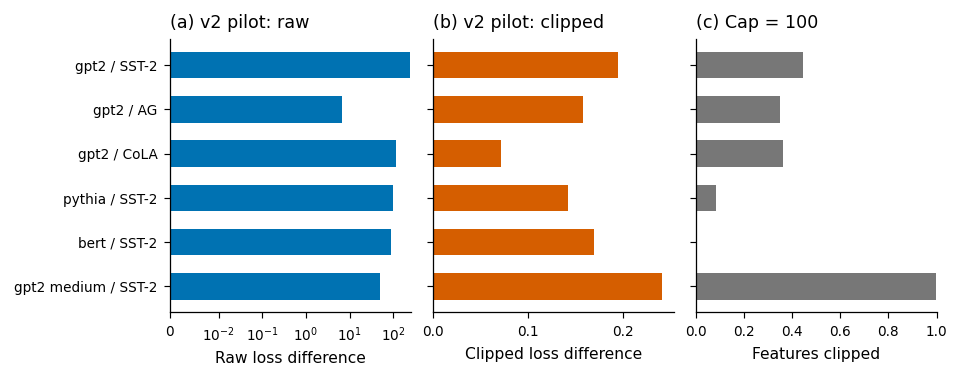

Archived input SHA-256: 694fdda8828d3c57d03b3d3dfcbe6134d33a936eeb4ef9108e953413a23ca460


In [23]:
legacy_summary=show_table("legacy_v2_visible_summary",LEGACY_V2["summary"])
show_table("legacy_v2_visible_baselines",LEGACY_V2["baselines"])
native=legacy_summary[legacy_summary["mode"]=="native"].copy()
if len(native):
    fig,axs=paper_figure(ncols=3,height=2.6,double=True);ix=np.arange(len(native))
    labels=[s.replace("_sst2", " / SST-2").replace("_agnews"," / AG").replace("_cola"," / CoLA").replace("_"," ") for s in native.job]
    for ax,col,color,title in zip(axs.flat,["raw_test_mean","clipped_test_mean","native_feature_clip_fraction"],
        [COLORS["geometry"],COLORS["direct_cal"],COLORS["other"]],["Raw loss difference","Clipped loss difference","Features clipped"]):
        ax.barh(ix,native[col],color=color,height=.6);ax.set(yticks=ix,yticklabels=labels if ax==axs[0,0] else [],xlabel=title);ax.invert_yaxis()
    axs[0,0].set_xscale("symlog",linthresh=.01);axs[0,2].set_xlim(0,1)
    for ax,l,t in zip(axs.flat,"abc",["v2 pilot: raw","v2 pilot: clipped","Cap = 100"]):panel(ax,l,t)
    export_figure(fig,"fig07_archived_v2_pilot","Archived v2 pilot only, copied from uploaded cell outputs; no fresh v3 model execution. Raw/clipped losses concern different estimands. Native features were norm-clipped at 100. Displayed rows are the retained subset of the original table.",native)
print("Archived input SHA-256:",LEGACY_SOURCE_SHA256)


## 17. Complete result bundle, figure manifest, and execution report
Every result table is embedded below as a compressed JSON MIME output, including pair-level tables that
would otherwise be truncated in the notebook display. It contains CSV strings, a schema version, and a
SHA-256 checksum. This makes a saved executed notebook independently reviewable without external CSVs.
The ZIP export additionally contains figures, captions, configuration, saved predictors, split IDs, and
per-example loss arrays for completed experiments. Native activation caches remain under `OUTPUT_ROOT`
and are deliberately excluded from the ZIP because they can be several gigabytes; preserve that folder
separately if you want to resume feature extraction without downloading models again.

To recover tables later, read the `application/json` output in this final code cell, base64-decode
`tables_zlib_base64`, decompress with `zlib.decompress`, check `tables_sha256`, then parse JSON and
`pandas.read_csv(io.StringIO(csv_string))`. No pickle, external script, or earlier notebook is required.

**Paper-writing rule:** report only completed experiments, use the stated estimand for every theorem and
figure, and cite the established identities/inference methods. A notebook cannot establish novelty or
guarantee acceptance. Manuscript theorems and proofs still require independent review against the actual
main `.tex` file; that manuscript is not embedded in this notebook.


In [25]:
show_table("final_validation_checks", CHECKS)
status_frame = show_table("execution_status", STATUS)

if EXECUTION_LEDGER:
    show_table("experiment_ledger", EXECUTION_LEDGER)

show_table("figure_manifest", FIGURE_LOG)

MANIFEST.update({
    "status_counts": status_frame.state.value_counts().to_dict(),
    "checks_passed": len(CHECKS),
    "figures_exported": len(FIGURE_LOG),
    "legacy_source_sha256": LEGACY_SOURCE_SHA256,
    "fresh_real_protocol_runs": len(EXECUTION_LEDGER),
    "fresh_real_domain_runs": len(DOMAIN_SUMMARY),
    "coverage_scope": (
        "fixed job/repeat; all declared protocols/actions/methods; "
        "budget curves additionally cover budgets"
    ),
    "activation_cache_in_archive": False,
    "real_model_dependencies_missing": missing,
})

write_json(RUN_DIR / "manifest.json", MANIFEST)
write_json(RUN_DIR / "resolved_revision_lock.json", REVISION_LOCK)
write_json(RUN_DIR / "figure_manifest.json", FIGURE_LOG)

# Preserve every result table without printing the encoded contents.
csv_tables = {
    name: pd.DataFrame(frame).to_csv(index=False)
    for name, frame in TABLES.items()
}
payload = json.dumps(
    csv_tables, sort_keys=True, ensure_ascii=False
).encode("utf-8")

bundle = {
    "format": "aistats_probe_transfer_v3_tables",
    "schema_version": 1,
    "manifest": MANIFEST,
    "tables_sha256": hashlib.sha256(payload).hexdigest(),
    "uncompressed_bytes": len(payload),
    "table_rows": {name: len(frame) for name, frame in TABLES.items()},
    "tables_zlib_base64": base64.b64encode(
        zlib.compress(payload, 9)
    ).decode("ascii"),
}

assert (
    zlib.decompress(base64.b64decode(bundle["tables_zlib_base64"]))
    == payload
), "Embedded result round trip"

write_json(RUN_DIR / "embedded_tables.json", bundle)

# FIX: put the full bundle in output metadata, not rendered application/json.
# Recovery from the saved notebook:
# output["metadata"]["aistats_probe_transfer_v3"]
summary_text = (
    f"Complete results preserved: {len(TABLES)} tables, "
    f"{sum(len(frame) for frame in TABLES.values()):,} rows.\n"
    f"SHA-256: {bundle['tables_sha256']}\n"
    "The encoded payload is hidden from the displayed output."
)

bundle_output = {
    "output_type": "display_data",
    "metadata": {"aistats_probe_transfer_v3": bundle},
    "data": {"text/plain": summary_text},
}

if "_emit_notebook_output" in globals():
    _emit_notebook_output(bundle_output)
else:
    from IPython.display import display
    display(
        bundle_output["data"],
        raw=True,
        metadata=bundle_output["metadata"],
    )

# Include completed checkpoints once each in the review archive.
archive = RUN_DIR.parent / (RUN_DIR.name + "_research_artifacts.zip")

with zipfile.ZipFile(
    archive,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6,
    allowZip64=True,
) as z:
    for path in sorted(RUN_DIR.rglob("*")):
        if path.is_file():
            z.write(path, "run/" + str(path.relative_to(RUN_DIR)))

    checkpoints = {
        p for p in USED_CHECKPOINTS
        if (p / "COMPLETE.json").exists()
    }
    for folder in sorted(checkpoints):
        for path in sorted(folder.rglob("*")):
            if path.is_file():
                z.write(
                    path,
                    "checkpoints/" + folder.name + "/"
                    + str(path.relative_to(folder)),
                )

print(
    f"Saved artifact archive: {archive.resolve()} "
    f"({archive.stat().st_size / 2**20:.2f} MiB)"
)
print(
    f"CHECKS: {len(CHECKS)} passed | "
    f"FIGURES: {len(FIGURE_LOG)} | "
    f"NEW REAL RUNS: {len(EXECUTION_LEDGER)} primary, "
    f"{len(DOMAIN_SUMMARY)} domain"
)
print("JOB STATUS:", status_frame.state.value_counts().to_dict())

if len(EXECUTION_LEDGER) == 0:
    print(
        "REAL v3 EVIDENCE IS NOT AVAILABLE IN THIS EXECUTION. "
        "Rerun the paper profile with model/data access."
    )

if (status_frame.state == "FAILED").any():
    print(
        "Some experiments FAILED; inspect execution_status "
        "before using the results."
    )

try:
    from IPython.display import display, FileLink
    display(FileLink(str(archive)))
except ImportError:
    pass

check,passed
ridge-corrected identity,True
mean plus covariance disagreement decomposition,True
OLS empirical identity,True
PCA sign flip preserves CKA,True
native lift removes sign artifact,True
CKA scale invariance,True
bernstein contains deterministic endpoint -1.0,True
betting contains deterministic endpoint -1.0,True
bernstein contains deterministic endpoint 1.0,True
betting contains deterministic endpoint 1.0,True


task,state,detail
core_checks,COMPLETED,13 assertions
bounded_inference_simulation,COMPLETED,1000 independent repetitions at each of three sample sizes
gaussian_oracle_simulation,COMPLETED,Correctly specified model only; separate estimand
rates_and_invariance,COMPLETED,Fresh simulations; no rate-anomaly claim
full_synthetic_protocols,COMPLETED,9 protocols with paired IDs and fixed calibration/test
gpt2_sst2,COMPLETED,17 protocol/split runs; raw block features; paper profile
gpt2_agnews,COMPLETED,17 protocol/split runs; raw block features; paper profile
gpt2_cola,COMPLETED,17 protocol/split runs; raw block features; paper profile
pythia_sst2,COMPLETED,17 protocol/split runs; raw block features; paper profile
bert_sst2,COMPLETED,17 protocol/split runs; raw block features; paper profile


job,protocol,repeat,n_train,n_cal,n_test,family_multiplier,interval_methods,actions,alpha,checkpoint,cache_hit,status
gpt2_sst2,native_raw,0,12000,3000,3000,9,2,2,0.05,aistats2027_v3_outputs/experiment_checkpoints_v3/c6053e198490b000385180851ce77ad888ed4a00d6ff30168a5d3236162d9a6d,False,COMPLETED
gpt2_sst2,shared_raw,0,12000,3000,3000,9,2,2,0.05,aistats2027_v3_outputs/experiment_checkpoints_v3/174c094535afcf2b8f9ea4a59eb4f42be530daa0a94bdcef4f38470e34c230bc,False,COMPLETED
gpt2_sst2,shared_center,0,12000,3000,3000,9,2,2,0.05,aistats2027_v3_outputs/experiment_checkpoints_v3/b01e0e70256738c4d80dbb70617da938ce6514ef9a3d5449909f8a1b8db3a718,False,COMPLETED
gpt2_sst2,shared_rms,0,12000,3000,3000,9,2,2,0.05,aistats2027_v3_outputs/experiment_checkpoints_v3/10d854cd51c0876e5cf991524fe0803815d3d83ba37f3d069e09f24d55291632,False,COMPLETED
gpt2_sst2,shared_unit,0,12000,3000,3000,9,2,2,0.05,aistats2027_v3_outputs/experiment_checkpoints_v3/f1940d81bd6219a84ba8f5cc18c319efa62205c5d80a24110fe970656be415eb,False,COMPLETED
gpt2_sst2,shared_clip100,0,12000,3000,3000,9,2,2,0.05,aistats2027_v3_outputs/experiment_checkpoints_v3/6879953f896a4a4bcea5c67005e06f4b54f58a5015516568a597193f5838c9dd,False,COMPLETED
gpt2_sst2,shared_clip300,0,12000,3000,3000,9,2,2,0.05,aistats2027_v3_outputs/experiment_checkpoints_v3/42a2701e8f8273b757184e2efac48928d8c775e61dd12e34474d010a9d29d204,False,COMPLETED
gpt2_sst2,separate_naive,0,12000,3000,3000,9,2,2,0.05,aistats2027_v3_outputs/experiment_checkpoints_v3/1a4ecdf1af5468c3616f9d2befe9a32e91680a503d64c5f81a6809844cdf5899,False,COMPLETED
gpt2_sst2,separate_lift,0,12000,3000,3000,9,2,2,0.05,aistats2027_v3_outputs/experiment_checkpoints_v3/94969b202f388b4480e876a65e1f9a7fa5cda37fab7daa65cd6080ff7475208a,False,COMPLETED
gpt2_sst2,native_raw,1,12000,3000,3000,9,2,2,0.05,aistats2027_v3_outputs/experiment_checkpoints_v3/cc4de79b0eb0aacb61f07aa09ab8b095e3bc0694ffcf52f698e53cbff5a0f56c,False,COMPLETED


figure,width_inches,height_inches,caption
fig01_bounded_inference,6.75,2.25,"Exactly enumerable bounded DGP. Both methods receive half of the 5% family budget; intervals cover two directions. Error bars are exact binomial Monte Carlo intervals, with slight horizontal offsets for visibility. Acceptance is based only on calibration data."
fig02_gaussian_oracle,6.75,2.25,Paired latent Gaussian DGP with source fitting independent of calibration. The F ellipsoid covers a conditional design-metric regret under correctly specified Gaussian linear regression; no population-covariance guarantee is claimed.
fig03_rates_and_scope,6.75,2.3,"Known quadratic-Gaussian rates and a positive-scaling orbit. These are background checks, not new theorems. The right panel evaluates the population target metric with identity covariance."
fig04_synthetic_controls,6.75,2.76,"Controlled paired simulation with mean/scale shifts. Points are medians over available repeats; whiskers are minimum-to-maximum ranges, not confidence intervals. The mean fraction is computed from prediction disagreement, not from possibly negative excess loss."
fig05_synthetic_pair_diagnostics,6.75,4.7,Synthetic raw shared-PCA protocol. Ordered layer pairs share examples and are not independent replicates. Raw loss heatmap uses a symmetric-log color scale. MAE targets noisy final-test mean loss differences. Geometry and direct training use identical label budgets.
fig06_synthetic_label_budget,6.75,2.25,"Synthetic centered/RMS protocol. Probe fitting labels and final test set are fixed. Horizontal curves require no additional assessment labels; direct calibration uses the stated budget. Interval multiplicity includes both methods, all budgets, actions, and planned protocols. Raw and clipped estimands appear in separately labeled panels."
fig08_synthetic_alignment,6.75,3,Synthetic raw shared-PCA protocol. Alignment is ridge distillation of source predictions using paired training features; calibration and final-test labels are not used to fit it. The raw scatter and clipped decision curves concern separate estimands. Intervals cover both actions and methods; threshold curves reuse those same intervals.
real_gpt2_sst2_shared_raw_diagnostics,6.75,4.7,"gpt2_sst2, shared_raw, v3 paper profile, split 0. Ordered layer pairs share examples and are not independent replicates. Raw loss heatmap uses a symmetric-log color scale. MAE targets noisy final-test mean loss differences. Geometry and direct training use identical label budgets."
real_gpt2_sst2_shared_raw_alignment,6.75,3,"gpt2_sst2, shared_raw. Alignment is ridge distillation of source predictions using paired training features; calibration and final-test labels are not used to fit it. The raw scatter and clipped decision curves concern separate estimands. Intervals cover both actions and methods; threshold curves reuse those same intervals."
real_gpt2_sst2_shared_raw_budget,6.75,2.25,"gpt2_sst2, shared_raw. Probe fitting labels and final test set are fixed. Horizontal curves require no additional assessment labels; direct calibration uses the stated budget. Interval multiplicity includes both methods, all budgets, actions, and planned protocols. Raw and clipped estimands appear in separately labeled panels."


Complete results preserved: 123 tables, 57,047 rows.
SHA-256: c28f7c4c8c285fc36708b091ed7bd21192e30a225a15aa26f4acaef8948e30c2
The encoded payload is hidden from the displayed output.

Saved artifact archive: /kaggle/working/aistats2027_v3_outputs/paper_20260927T094309405733Z_research_artifacts.zip (4696.56 MiB)
CHECKS: 24 passed | FIGURES: 68 | NEW REAL RUNS: 136 primary, 18 domain
JOB STATUS: {'COMPLETED': 19}


/kaggle/working/aistats2027_v3_outputs/paper_20260927T094309405733Z_research_artifacts.zip

## Primary references and final figure placement
1. Maurer & Pontil (2009), *Empirical Bernstein Bounds and Sample Variance Penalization*.
   https://arxiv.org/abs/0907.3740
2. Waudby-Smith & Ramdas (2024), *Estimating means of bounded random variables by betting*.
   https://doi.org/10.1093/jrsssb/qkad009
3. Kornblith et al. (2019), *Similarity of Neural Network Representations Revisited*.
   https://proceedings.mlr.press/v97/kornblith19a.html
4. Ding et al. (2021), *Grounding Representation Similarity Through Statistical Testing*.
   https://arxiv.org/abs/2108.01661
5. Chen & Fang (2019), *Inference on Functionals under First Order Degeneracy*.
   https://arxiv.org/abs/1901.04861
6. Cai & Guo (2020), *Semisupervised inference for explained variance in high dimensional linear
   regression and its applications*. https://doi.org/10.1111/rssb.12357
7. AISTATS 2027 author template: https://aistats.org/aistats2027/AISTATS2027PaperPack.zip

For LaTeX, use PDF figures at their intended physical width, retain readable fonts after placement,
and include the generated captions' estimand and uncertainty qualifications. The 3.25/6.75-inch presets
are design choices, not a claim that the conference mandates those exact figure widths. Use the official
template to make the final decision. Add relevant subsequent primary work during the manuscript novelty review.


In [29]:
# Download the existing ZIP without rerunning any experiments.
from pathlib import Path
import os
import shutil
from IPython.display import display, FileLink

if "zip_path" not in globals():
    raise RuntimeError("Run the ZIP export cell first.")

source_zip = Path(zip_path).expanduser().resolve()

if not source_zip.is_file():
    raise FileNotFoundError(f"ZIP not found: {source_zip}")

# Put the ZIP in Kaggle's downloadable working directory when available.
download_dir = (
    Path("/kaggle/working")
    if Path("/kaggle/working").is_dir()
    else Path.cwd()
)

download_zip = (
    download_dir / "AISTATS2027_Figures_and_Essential_Tables.zip"
).resolve()

if source_zip != download_zip:
    shutil.copy2(source_zip, download_zip)

print(f"Ready: {download_zip.stat().st_size / 2**20:.2f} MiB")
print("CLICK THE ZIP FILENAME BELOW TO DOWNLOAD:")

previous_directory = Path.cwd()
try:
    os.chdir(download_dir)
    display(FileLink(download_zip.name))
finally:
    os.chdir(previous_directory)

print(f"\nSaved file: {download_zip}")
if download_dir == Path("/kaggle/working"):
    print(
        "If the link does not open, find this ZIP in Kaggle's "
        "Output/files panel and select Download."
    )

Ready: 20.09 MiB
CLICK THE ZIP FILENAME BELOW TO DOWNLOAD:


/kaggle/working/AISTATS2027_Figures_and_Essential_Tables.zip


Saved file: /kaggle/working/AISTATS2027_Figures_and_Essential_Tables.zip
If the link does not open, find this ZIP in Kaggle's Output/files panel and select Download.
